In [154]:
import subprocess
from pathlib import Path

DATA_REPO_URL = "https://github.com/4mnesia/DataMining_Datos.git"
DATA_REPO_DIR = Path(".data") / "DataMining_Datos"

def ensure_data_repo(repo_url=DATA_REPO_URL, repo_dir=DATA_REPO_DIR):
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    if (repo_dir / ".git").exists():
        subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", "--depth", "1", repo_url, str(repo_dir)], check=True)
    return repo_dir

data_dir = ensure_data_repo()
print(f"Repositorio de datos listo: {data_dir.resolve()}")
print(sorted(path.name for path in data_dir.iterdir() if path.is_file()))

Repositorio de datos listo: C:\Users\flavi\Desktop\DataMining\.data\DataMining_Datos
['.gitignore', 'README.md', 'dataset_precipitaciones_diarias_chile_COMPLETO.csv', 'getEstacionesRedEma.json']


In [155]:
import pandas as pd
import json
import subprocess
from pathlib import Path
from IPython.display import display

DATA_REPO_URL = "https://github.com/4mnesia/DataMining_Datos.git"
DATA_REPO_DIR = Path(".data") / "DataMining_Datos"

def ensure_data_repo(repo_url=DATA_REPO_URL, repo_dir=DATA_REPO_DIR):
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    if (repo_dir / ".git").exists():
        subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", "--depth", "1", repo_url, str(repo_dir)], check=True)
    return repo_dir

data_dir = ensure_data_repo()
base_path = data_dir / "dataset_precipitaciones_diarias_chile_COMPLETO.csv"
meta_path = data_dir / "getEstacionesRedEma.json"

try:
    df_csv_drive = pd.read_csv(base_path)
    print(f"Shape base CSV desde GitHub: {df_csv_drive.shape}")

    with meta_path.open("r", encoding="utf-8") as f:
        meta_data = json.load(f)
    print("Metadata JSON cargada correctamente.")

    display(df_csv_drive.head())
except Exception as e:
    print(f"Error al cargar los archivos: {e}")

Shape base CSV desde GitHub: (187876, 10)
Metadata JSON cargada correctamente.


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha
0,170001,15,4084,-17.595,-69.4775,2023,1,1,NaN,2023-01-01
1,170001,15,4084,-17.595,-69.4775,2023,1,2,NaN,2023-01-02
2,170001,15,4084,-17.595,-69.4775,2023,1,3,NaN,2023-01-03
3,170001,15,4084,-17.595,-69.4775,2023,1,4,NaN,2023-01-04
4,170001,15,4084,-17.595,-69.4775,2023,1,5,NaN,2023-01-05


In [156]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

path_to_explore = os.path.join('.data', 'DataMining_Datos')
if os.path.exists(path_to_explore):
    list_files(path_to_explore)
else:
    print(f'Ruta no encontrada: {path_to_explore}')

DataMining_Datos/
    .gitignore
    dataset_precipitaciones_diarias_chile_COMPLETO.csv
    getEstacionesRedEma.json
    README.md
    .git/
        config
        description
        FETCH_HEAD
        HEAD
        index
        ORIG_HEAD
        packed-refs
        shallow
        hooks/
            applypatch-msg.sample
            commit-msg.sample
            fsmonitor-watchman.sample
            post-update.sample
            pre-applypatch.sample
            pre-commit.sample
            pre-merge-commit.sample
            pre-push.sample
            pre-rebase.sample
            pre-receive.sample
            prepare-commit-msg.sample
            push-to-checkout.sample
            sendemail-validate.sample
            update.sample
        info/
            exclude
        logs/
            HEAD
            refs/
                heads/
                    main
                remotes/
                    origin/
                        HEAD
        objects/
            info/
 

# Proyecto Data Mining - CRISP-DM

**Integrantes:** Flavio Henriquez / Bastian Bianchi  
**Docente:** Italo Bonnet

## 1. Fase 1: Entendimiento del Negocio

Esta fase tiene por finalidad definir el problema de estudio, justificar su relevancia y delimitar el alcance del analisis. En coherencia con la metodologia CRISP-DM, el proposito inicial no es construir un modelo de manera inmediata, sino comprender con claridad que valor puede aportar el estudio de las precipitaciones diarias, que informacion se encuentra disponible, cuales son las principales restricciones del conjunto de datos y bajo que criterios se evaluara la pertinencia del trabajo desarrollado.


### 1.1 Contexto

Chile presenta una diversidad climatica y geografica muy marcada. En un mismo territorio coexisten sectores aridos, semiaridos, mediterraneos, templados lluviosos y frios patagonicos, por lo que la precipitacion no puede interpretarse de forma homogenea. Esta variabilidad convierte el estudio de las lluvias en un problema relevante para la gestion hidrica, la planificacion agricola, el monitoreo meteorologico, la prevencion de eventos extremos y la toma de decisiones territoriales.

El dataset utilizado contiene precipitaciones diarias registradas por estaciones meteorologicas chilenas. La granularidad diaria es pertinente porque permite observar no solo la magnitud de la lluvia, sino tambien su frecuencia, su estacionalidad y la persistencia de periodos secos. Ademas, la lectura del problema no se limita a la region administrativa: para esta entrega tambien resulta clave interpretar el fenomeno por estacion, zona geografica, macrozona y zona climatica.

Desde una perspectiva aplicada, el valor del analisis radica en transformar registros meteorologicos en informacion util para comprender donde, cuando y bajo que contexto territorial ocurre la precipitacion. Por ello, el entendimiento del negocio no se restringe a describir un archivo, sino a justificar por que la lluvia diaria debe leerse como un fenomeno simultaneamente temporal y territorial.


### 1.2 Datos relevantes

El analisis se sustenta en los archivos del repositorio `https://github.com/4mnesia/DataMining_Datos`: `dataset_precipitaciones_diarias_chile_COMPLETO.csv`, que contiene la serie diaria principal, y `getEstacionesRedEma.json`, el cual permite asociar a los codigos tecnicos nombres descriptivos de estaciones, regiones y zonas geograficas. A partir de esa metadata, el estudio incorpora dos clasificaciones territoriales de apoyo: `macrozona` y `zona_climatica`. La `macrozona` se define como una agregacion territorial amplia, mientras que la `zona_climatica` se aproxima a partir de la ubicacion de cada estacion usando region, latitud, altitud y zona geografica, con el fin de representar de forma mas precisa regimenes de precipitacion comparables dentro de Chile.

**Resumen del conjunto**

| Aspecto | Valor observado | Relevancia para el proyecto |
| --- | --- | --- |
| Fuente principal | `DataMining_Datos/dataset_precipitaciones_diarias_chile_COMPLETO.csv` | Archivo CSV remoto descargado desde el repositorio de datos |
| Metadata complementaria | `DataMining_Datos/getEstacionesRedEma.json` | Archivo JSON remoto que enriquece los codigos con nombres de estacion, region y zona geografica |
| Granularidad base | 1 registro por estacion y por dia | Permite analizar frecuencia e intensidad diaria de precipitaciones |
| Periodo cubierto | 2021-01-01 a 2025-12-31 | Entrega continuidad temporal reciente de 5 anos |
| Cantidad de registros | 187,876 filas | Da volumen suficiente para detectar patrones temporales y territoriales |
| Estaciones meteorologicas | 109 | Aporta diversidad espacial y comparacion entre puntos de medicion |
| Regiones representadas | 16 | Entrega cobertura territorial amplia dentro de Chile |
| Zonas geograficas | 6 categorias | Resume relieve y emplazamiento de las estaciones |
| Macrozonas analiticas | 4 categorias | Permite una lectura sintetica Norte-Centro-Sur-Austral |
| Zonas climaticas analiticas | 13 categorias | Facilita una lectura territorial mas fina del regimen de precipitacion |
| Variable objetivo | `agua_caida` | Es la magnitud que se desea comprender y eventualmente predecir |
| Valores faltantes en `agua_caida` | 17,063 registros (9.08%) | Obliga a definir un tratamiento antes del modelamiento |

**Analisis.** La utilidad del conjunto no depende solo de su volumen, sino tambien de su capacidad para leerse en distintos niveles de agregacion. La estacion mantiene el detalle local, la zona geografica aporta contexto de relieve, la region permite una lectura administrativa, la macrozona resume grandes franjas territoriales y la zona climatica aproxima regimenes de precipitacion comparables. Esta granularidad multiescala resulta especialmente valiosa porque la lluvia diaria chilena no responde a un unico patron nacional, sino a combinaciones de territorio, estacionalidad y disponibilidad de datos.


### 1.3 Hipotesis y tesis consideradas

A partir del contexto del problema y de la estructura del dataset, se plantean las siguientes hipotesis de trabajo:

- La precipitacion diaria presenta un comportamiento estacional identificable, por lo que `mes`, `fecha` y posibles variables derivadas del calendario deberian explicar una parte relevante de la variacion observada en `agua_caida`.
- La ubicacion geografica de cada estacion, representada por `latitud`, `longitud`, `altura`, `region`, `zona_geografica` y `macrozona`, influye en la intensidad y en la frecuencia de las precipitaciones.
- La clasificacion por `zona_climatica` deberia distinguir mejor los regimenes de lluvia que la lectura exclusivamente administrativa por region, ya que agrupa territorios con comportamientos meteorologicos mas comparables.
- Existen diferencias estructurales entre estaciones meteorologicas; por lo tanto, `codigo_estacion` no solo actua como identificador, sino que tambien sintetiza condiciones locales de relieve, exposicion y microclima.
- La base diaria presenta una alta concentracion de dias sin precipitacion, por lo que la distribucion de la variable objetivo sera asimetrica y exigira especial cuidado interpretativo.
- Los valores faltantes de `agua_caida` deben revisarse antes de cualquier etapa posterior, ya que una concentracion no aleatoria por zona climatica, macrozona o periodo podria sesgar las conclusiones del analisis.
- Como proyeccion del proyecto, el caso puede formularse posteriormente como una tarea predictiva de regresion orientada a estimar la precipitacion diaria en milimetros.

**Analisis.** Estas hipotesis son consistentes con un enfoque CRISP-DM porque no parten desde un modelo, sino desde una comprension razonada del caso. La inclusion explicita de macrozonas y zonas climaticas ayuda a formular un problema mas realista: no se espera la misma dinamica de lluvia en un contexto arido del norte que en uno templado lluvioso o frio patagonico del sur austral.


### 1.4 KPI relevantes

En una entrega centrada en las primeras fases de CRISP-DM, los KPI mas pertinentes no corresponden todavia al rendimiento de un modelo final, sino a indicadores que permitan evaluar si el problema ha sido correctamente delimitado y si la base presenta condiciones adecuadas para continuar con el proceso analitico.

| KPI | Valor o criterio actual | Por que es relevante |
| --- | --- | --- |
| Cobertura temporal del dataset | 2021-01-01 a 2025-12-31 | Confirma que el analisis abarca 5 anos recientes y no solo una temporada aislada |
| Cobertura territorial fina | 109 estaciones en 16 regiones | Mide si el problema tiene representatividad geografica suficiente |
| Cobertura macrozonal | 4 macrozonas analiticas | Permite evaluar patrones amplios del territorio chileno |
| Cobertura climatica | 13 zonas climaticas analiticas | Permite contrastar regimenes de lluvia con mayor detalle |
| Completitud de `agua_caida` | 90.92% con dato disponible | Permite saber cuanta informacion util hay para analizar o modelar |
| Registros con `agua_caida = 0` | 67.68% del total | Advierte que la variable objetivo esta altamente concentrada en ausencia de lluvia |
| Registros con precipitacion positiva | 23.24% del total | Ayuda a dimensionar la frecuencia real de eventos de lluvia |
| Duplicados por estacion-fecha | 0 | Indica consistencia basica de la unidad de analisis diaria |

**Analisis.** Estos KPI muestran que la base es amplia y valiosa, pero no perfecta. La cobertura espacial es alta y permite una lectura multinivel, aunque la existencia de 9.08% de faltantes en la variable objetivo obliga a tratar la completitud como un KPI operativo central. En otras palabras, no basta con tener muchas estaciones; tambien es necesario asegurar que la informacion de precipitacion este disponible o tratada de manera defendible.


### 1.5 Problema de negocio (Analisis y proyeccion predictiva)

El problema de negocio consiste en comprender y dejar preparada una base analitica que permita explicar el comportamiento de la precipitacion diaria en estaciones meteorologicas chilenas. El valor esperado del proyecto radica en aportar informacion util para la gestion hidrica, el monitoreo de condiciones climaticas, la planificacion territorial y el analisis de riesgo asociado a periodos secos o a eventos de lluvia intensa.

La unidad de analisis del proyecto corresponde a cada combinacion `estacion-dia`. En dicho nivel, la variable objetivo es `agua_caida`, medida en milimetros, mientras que las variables disponibles describen ubicacion, contexto territorial y momento temporal del registro. Para interpretar mejor el problema, el analisis se organiza simultaneamente por estacion, zona geografica, region, macrozona y zona climatica. Esta lectura multiescala resulta especialmente importante porque el dataset contiene datos faltantes en `agua_caida`, de modo que comprender su distribucion territorial es parte del problema y no un detalle secundario.

**Analisis.** Dado que esta entrega prioriza el entendimiento del negocio y de los datos, el objetivo no consiste en prometer un modelo final, sino en formular correctamente el caso y preparar la base con criterio. En este sentido, una buena definicion del problema debe reconocer tanto la heterogeneidad territorial de la lluvia como la existencia de valores faltantes que podrian distorsionar el analisis si no se tratan con una estrategia coherente.


## 2. Fase 2: Entendimiento de los Datos

En esta fase se realiza una exploracion estructurada del dataset con el fin de identificar tipos de variables, valores faltantes, posibles outliers, distribuciones basicas, correlaciones y patrones relevantes. En coherencia con el material de apoyo, el objetivo no es solo describir los datos, sino tambien interpretar su calidad y anticipar decisiones de preparacion que permitan continuar el proceso de mineria de datos con mayor solidez.


### 2.1 Identificar Tipos de variables/atributos


En esta subseccion se distingue entre el tipo tecnico detectado por `pandas` y el tipo analitico que realmente cumple cada atributo dentro del problema. Esta distincion es importante porque varias columnas aparecen como numericas, pero conceptualmente funcionan como identificadores o categorias nominales y, por lo tanto, no deben interpretarse como magnitudes continuas.


In [ ]:
# Si necesitas instalar dependencias en este notebook:
# !pip install "pandas" "numpy" "matplotlib" "scikit-learn"

import csv
import json
import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVC, SVR
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    r2_score, mean_absolute_error, mean_squared_error,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)

DATA_REPO_URL = "https://github.com/4mnesia/DataMining_Datos.git"
DATA_REPO_DIR = Path(".data") / "DataMining_Datos"
DATASET_PRECIPITACIONES = "dataset_precipitaciones_diarias_chile_COMPLETO.csv"
DATASET_PRECIPITACIONES_TEMPERATURAS = "dataset_precipitaciones_temperaturas_chile.csv"
TEMPERATURE_COLUMNS = ["temp_max", "temp_min", "temp_media"]

def ensure_data_repo(repo_url=DATA_REPO_URL, repo_dir=DATA_REPO_DIR):
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    if (repo_dir / ".git").exists():
        subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", "--depth", "1", repo_url, str(repo_dir)], check=True)
    return repo_dir


def cargar_metadata_estaciones(meta_path):
    with meta_path.open("r", encoding="utf-8") as f:
        meta_json = json.load(f)
    return (
        pd.DataFrame(meta_json["datosEstacion"])
        [["codigoNacional", "region", "nombreEstacion", "NombreRegion", "zonaGeografica"]]
        .rename(
            columns={
                "codigoNacional": "codigo_estacion",
                "nombreEstacion": "nombre_estacion",
                "NombreRegion": "nombre_region",
                "zonaGeografica": "zona_geografica",
            }
        )
        .drop_duplicates(subset=["codigo_estacion", "region"])
    )


def leer_csv_formato_mixto(csv_path):
    """Lee CSV normal o filas completas entre comillas, como ocurre en el dataset con temperaturas."""
    filas = []
    with csv_path.open("r", encoding="utf-8") as f:
        encabezado = next(csv.reader([f.readline().rstrip("\n")]))
        for raw_line in f:
            linea = raw_line.rstrip("\n")
            if linea.startswith('"') and linea.endswith('"'):
                linea = linea[1:-1].replace('""', '"')
            filas.append(next(csv.reader([linea])))

    data = pd.DataFrame(filas, columns=encabezado)
    columnas_numericas = [
        "codigo_estacion", "region", "altura", "latitud", "longitud",
        "anio", "mes", "dia", "agua_caida", "temp_max", "temp_min", "temp_media",
    ]
    for columna in columnas_numericas:
        if columna in data.columns:
            data[columna] = pd.to_numeric(data[columna], errors="coerce")
    if "fecha" in data.columns:
        data["fecha"] = pd.to_datetime(data["fecha"], errors="coerce")
    return data


data_dir = ensure_data_repo()
base_precipitaciones_path = data_dir / DATASET_PRECIPITACIONES
base_temperaturas_path = data_dir / DATASET_PRECIPITACIONES_TEMPERATURAS
base_path = base_temperaturas_path if base_temperaturas_path.exists() else base_precipitaciones_path
meta_path = data_dir / "getEstacionesRedEma.json"

try:
    df_csv = leer_csv_formato_mixto(base_path)
    meta_df = cargar_metadata_estaciones(meta_path)
    resumen_dataset_usado = pd.DataFrame(
        {
            "archivo": [base_path.name],
            "filas": [df_csv.shape[0]],
            "columnas": [df_csv.shape[1]],
            "usa_temperaturas": [all(col in df_csv.columns for col in ["temp_max", "temp_min", "temp_media"])],
            "nulos_temp_media": [int(df_csv["temp_media"].isna().sum()) if "temp_media" in df_csv.columns else None],
        }
    )
    print(f"Archivo base usado: {base_path.name}")
    print(f"Shape base CSV: {df_csv.shape}")
    print(f"Shape metadata estaciones: {meta_df.shape}")
    display(resumen_dataset_usado)
except Exception as e:
    print(f"Error al cargar los archivos: {e}")


En esta primera celda solo se preparan las dependencias, la configuracion visual y las rutas de trabajo. Si el entorno no dispone de alguna libreria necesaria, la instalacion puede realizarse aparte, pero no se deja embebida dentro del codigo para mantener el flujo del notebook mas limpio.


In [158]:
def heatmap_df(data, title, cmap="Blues", figsize=(8, 5), decimals=2, xlabel="Eje X", ylabel="Eje Y", cbar_label="Valor", na_text=""):
    fig, ax = plt.subplots(figsize=figsize)
    matrix = data.astype(float).values
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#f8fafc")
    masked = np.ma.masked_invalid(matrix)
    im = ax.imshow(masked, cmap=cmap_obj, aspect="auto")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    for row in range(data.shape[0]):
        for col in range(data.shape[1]):
            value = matrix[row, col]
            if np.isnan(value):
                if na_text:
                    ax.text(col, row, na_text, ha="center", va="center", fontsize=7, color="#64748b")
            else:
                ax.text(col, row, f"{value:.{decimals}f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()


def plot_group_heatmaps(corr_dict, title_prefix, cmap="coolwarm", decimals=2, ncols=2, base_figsize=(5.5, 4.2), xlabel="Variables", ylabel="Variables", cbar_label="Correlacion"):
    items = [(grupo, matriz) for grupo, matriz in corr_dict.items() if matriz is not None and not matriz.empty]
    if not items:
        print("No hay matrices para graficar.")
        return

    ncols = min(ncols, len(items))
    nrows = int(np.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(base_figsize[0] * ncols, base_figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()
    image = None
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#f8fafc")

    for ax, (grupo, matriz) in zip(axes, items):
        matrix = matriz.astype(float).values
        masked = np.ma.masked_invalid(matrix)
        image = ax.imshow(masked, cmap=cmap_obj, aspect="auto", vmin=-1, vmax=1)
        ax.set_xticks(range(len(matriz.columns)))
        ax.set_xticklabels(matriz.columns, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(matriz.index)))
        ax.set_yticklabels(matriz.index, fontsize=8)
        for row in range(matriz.shape[0]):
            for col in range(matriz.shape[1]):
                value = matrix[row, col]
                if not np.isnan(value):
                    ax.text(col, row, f"{value:.{decimals}f}", ha="center", va="center", fontsize=7)
        ax.set_title(f"{title_prefix}: {grupo}", fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    for ax in axes[len(items):]:
        ax.axis("off")

    fig.subplots_adjust(right=0.88, wspace=0.45, hspace=0.6)
    if image is not None:
        cax = fig.add_axes([0.9, 0.2, 0.015, 0.6])
        cbar = fig.colorbar(image, cax=cax)
        cbar.set_label(cbar_label)

    plt.show()


def build_group_corr_dict(data, group_col, numeric_cols, group_order=None, min_rows=30, drop_constant=False):
    groups = group_order if group_order is not None else list(pd.Series(data[group_col]).dropna().unique())
    corr_dict = {}

    for group in groups:
        subset = data.loc[data[group_col] == group, numeric_cols].dropna()
        if drop_constant:
            subset = subset.loc[:, subset.nunique(dropna=True) > 1]
        if len(subset) >= min_rows and subset.shape[1] >= 2:
            corr_dict[group] = subset.corr(numeric_only=True).round(3)

    return corr_dict


Las funciones de visualizacion quedan separadas porque se reutilizan varias veces en el notebook. `heatmap_df` se usa para una sola matriz, mientras que `plot_group_heatmaps` permite repetir la misma lectura por segmentos territoriales, en este caso por `zona_geografica`, sin convertir cada subseccion en un bloque manual demasiado extenso.


In [159]:
MACROZONE_ORDER = ["Norte", "Centro", "Sur", "Austral", "Otra"]
MACROZONE_MARKERS = {
    "Norte": "o",
    "Centro": "s",
    "Sur": "^",
    "Austral": "D",
    "Otra": "X",
}
MACROZONE_OFFSETS = {
    "Norte": -0.24,
    "Centro": -0.08,
    "Sur": 0.08,
    "Austral": 0.24,
    "Otra": 0.0,
}

MACROZONE_COLORS = {
    "Norte": "#0f766e",
    "Centro": "#2563eb",
    "Sur": "#7c3aed",
    "Austral": "#ea580c",
    "Otra": "#64748b",
}

def region_to_macrozone(region_code):
    if region_code in [15, 1, 2, 3, 4]:
        return "Norte"
    if region_code in [5, 13, 6, 7]:
        return "Centro"
    if region_code in [16, 8, 9, 14, 10]:
        return "Sur"
    if region_code in [11, 12]:
        return "Austral"
    return "Otra"


def infer_climate_zone(region_code, latitud, altura, zona_geografica):
    if pd.isna(region_code) or pd.isna(latitud):
        return "Otra"

    region_code = int(region_code)
    lat_sur = abs(float(latitud))
    altura = 0 if pd.isna(altura) else float(altura)
    zona = "" if pd.isna(zona_geografica) else str(zona_geografica)

    if region_code in [15, 1, 2]:
        if lat_sur <= 19.5 and altura >= 3200:
            return "Tropical lluvioso"
        if altura >= 2500 or zona in ["Cordillera", "PreCordillera"]:
            return "Desertico y Esteparico de altura"
        if zona == "Litoral":
            return "Desertico costero"
        return "Desertico normal"

    if region_code in [3, 4]:
        if altura >= 2200 or zona in ["Cordillera", "PreCordillera"]:
            return "Desertico y Esteparico de altura"
        if zona in ["Litoral", "Secano Costero"]:
            return "Esteparico costero"
        return "Esteparico interior"

    if region_code in [5, 13, 6, 7]:
        return "Mediterraneo seco"

    if region_code in [16, 8]:
        return "Mediterraneo seco y humedo"

    if region_code in [9, 14, 10]:
        if zona == "Litoral":
            return "Maritimo lluvioso"
        return "Templado y lluvioso"

    if region_code == 11:
        if zona == "Litoral":
            return "Maritimo lluvioso"
        return "Estepario frio"

    if region_code == 12:
        if lat_sur >= 53:
            return "Tundra"
        if altura >= 1200 or zona in ["Cordillera", "PreCordillera"]:
            return "Hielo de alturas y clima polar"
        if zona == "Litoral":
            return "Maritimo lluvioso"
        return "Estepario frio"

    return "Otra"


CLIMATE_ORDER = [
    "Tropical lluvioso",
    "Desertico costero",
    "Desertico normal",
    "Desertico y Esteparico de altura",
    "Esteparico costero",
    "Esteparico interior",
    "Mediterraneo seco",
    "Mediterraneo seco y humedo",
    "Templado y lluvioso",
    "Maritimo lluvioso",
    "Estepario frio",
    "Tundra",
    "Hielo de alturas y clima polar",
]
CLIMATE_COLORS = {
    "Tropical lluvioso": "#16a34a",
    "Desertico costero": "#f59e0b",
    "Desertico normal": "#d97706",
    "Desertico y Esteparico de altura": "#c2410c",
    "Esteparico costero": "#fb923c",
    "Esteparico interior": "#f97316",
    "Mediterraneo seco": "#84cc16",
    "Mediterraneo seco y humedo": "#65a30d",
    "Templado y lluvioso": "#2563eb",
    "Maritimo lluvioso": "#0ea5e9",
    "Estepario frio": "#8b5cf6",
    "Tundra": "#64748b",
    "Hielo de alturas y clima polar": "#e2e8f0",
}


def add_class_legends(ax, climate_values=None, macro_values=None):
    climate_values = ACTIVE_CLIMATE_ORDER if climate_values is None else list(climate_values)
    macro_values = MACROZONE_ORDER if macro_values is None else list(macro_values)

    climate_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=CLIMATE_COLORS.get(zona, "#94a3b8"),
            markeredgecolor="#0f172a",
            markersize=8,
            label=zona,
        )
        for zona in climate_values
    ]
    macro_handles = [
        Line2D(
            [0],
            [0],
            marker=MACROZONE_MARKERS.get(macrozona, "o"),
            linestyle="",
            color="#0f172a",
            markersize=8,
            label=macrozona,
        )
        for macrozona in macro_values
    ]

    legend_clima = ax.legend(
        handles=climate_handles,
        title="Zona climatica",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    ax.add_artist(legend_clima)
    ax.legend(
        handles=macro_handles,
        title="Macrozona",
        bbox_to_anchor=(1.02, 0.35),
        loc="upper left",
    )

Primero se dejan preparadas las librerias, funciones auxiliares y rutas de trabajo. Esta separacion ayuda a que la carga y el enriquecimiento del dataset se entiendan como pasos distintos y no como una sola celda extensa.


In [160]:
# Usamos la metadata descargada desde el repositorio de datos.
# Esta celda tambien sirve para reconstruir meta_df si el kernel se reinicio.
if "cargar_metadata_estaciones" not in globals():
    def cargar_metadata_estaciones(meta_path):
        with meta_path.open("r", encoding="utf-8") as f:
            meta_json = json.load(f)
        return (
            pd.DataFrame(meta_json["datosEstacion"])
            [["codigoNacional", "region", "nombreEstacion", "NombreRegion", "zonaGeografica"]]
            .rename(
                columns={
                    "codigoNacional": "codigo_estacion",
                    "nombreEstacion": "nombre_estacion",
                    "NombreRegion": "nombre_region",
                    "zonaGeografica": "zona_geografica",
                }
            )
            .drop_duplicates(subset=["codigo_estacion", "region"])
        )

meta_df = cargar_metadata_estaciones(meta_path)

print(f"Shape metadata estaciones: {meta_df.shape}")
display(meta_df.head())

Shape metadata estaciones: (148, 5)


,codigo_estacion,region,nombre_estacion,nombre_region,zona_geografica
0,170001,15,Visviri Tenencia,Arica y Parinacota,Cordillera
1,180005,15,"Chacalluta, Arica Ap.",Arica y Parinacota,Litoral
2,180017,15,Putre,Arica y Parinacota,PreCordillera
3,180018,15,"Defensa Civil, Arica",Arica y Parinacota,Litoral
4,180042,15,"Cerro Sombrero, Arica",Arica y Parinacota,Litoral


En este punto todavia existen dos fuentes separadas: la serie diaria y la metadata descriptiva. La segunda es clave porque transforma codigos tecnicos en nombres de estacion, region y zona geografica, lo que vuelve mucho mas interpretable el analisis posterior.


In [ ]:
# Construccion del DataFrame principal enriquecido.
# Si meta_df o df_csv no existen por orden de ejecucion, se reconstruyen aqui.
if "df_csv" not in globals():
    if "df_csv_drive" in globals():
        df_csv = df_csv_drive.copy()
    else:
        df_csv = pd.read_csv(base_path)

if "meta_df" not in globals():
    if "cargar_metadata_estaciones" not in globals():
        def cargar_metadata_estaciones(meta_path):
            with meta_path.open("r", encoding="utf-8") as f:
                meta_json = json.load(f)
            return (
                pd.DataFrame(meta_json["datosEstacion"])
                [["codigoNacional", "region", "nombreEstacion", "NombreRegion", "zonaGeografica"]]
                .rename(
                    columns={
                        "codigoNacional": "codigo_estacion",
                        "nombreEstacion": "nombre_estacion",
                        "NombreRegion": "nombre_region",
                        "zonaGeografica": "zona_geografica",
                    }
                )
                .drop_duplicates(subset=["codigo_estacion", "region"])
            )
    meta_df = cargar_metadata_estaciones(meta_path)

columnas_metadata_integradas = ["nombre_estacion", "nombre_region", "zona_geografica"]

if all(columna in df_csv.columns for columna in columnas_metadata_integradas):
    df = df_csv.copy()
else:
    df = df_csv.merge(meta_df, on=["codigo_estacion", "region"], how="left")

columnas_numericas_base = [
    "codigo_estacion", "region", "altura", "latitud", "longitud",
    "anio", "mes", "dia", "agua_caida", "temp_max", "temp_min", "temp_media",
]
for columna in columnas_numericas_base:
    if columna in df.columns:
        df[columna] = pd.to_numeric(df[columna], errors="coerce")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values(["codigo_estacion", "fecha"]).reset_index(drop=True)
df["macrozona"] = df["region"].apply(region_to_macrozone)
df["zona_climatica"] = df.apply(
    lambda row: infer_climate_zone(
        row["region"],
        row["latitud"],
        row["altura"],
        row["zona_geografica"],
    ),
    axis=1,
)
ACTIVE_CLIMATE_ORDER = [zona for zona in CLIMATE_ORDER if zona in df["zona_climatica"].dropna().unique()]
ACTIVE_GEO_ORDER = sorted(df["zona_geografica"].dropna().unique())
columnas_temperatura = [col for col in TEMPERATURE_COLUMNS if col in df.columns]
print("Zonas climaticas activas:", ", ".join(ACTIVE_CLIMATE_ORDER))
print("Zonas geograficas activas:", ", ".join(ACTIVE_GEO_ORDER))

print(f"Dimension del dataset enriquecido: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Periodo disponible: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Estaciones con metadata: {df['nombre_estacion'].nunique()}")
print(f"Regiones representadas: {df['nombre_region'].nunique()}")
print(f"Macrozonas analiticas: {df['macrozona'].nunique()}")
print(f"Zonas climaticas analiticas activas: {df['zona_climatica'].nunique()}")
print(f"Zonas geograficas analiticas activas: {df['zona_geografica'].nunique()}")
display(df.head())

### Análisis del Enriquecimiento de Datos

El proceso de unión entre la serie de tiempo de precipitaciones y la metadata de las estaciones es un paso crítico para transformar datos crudos en información con valor de negocio. Al integrar variables como `zona_geografica`, `macrozona` y `zona_climatica`, permitimos que el análisis posterior no solo identifique **cuánto** llovió, sino que pueda contextualizar el fenómeno según el relieve (ej. Cordillera vs. Litoral) y el régimen climático (ej. Tropical vs. Mediterráneo).

**Observaciones clave:**
1. **Continuidad Temporal:** El dataset cubre desde 2021 hasta finales de 2025, lo que permite observar ciclos estacionales completos.
2. **Representatividad:** Contamos con 109 estaciones distribuidas en las 16 regiones de Chile.
3. **Granularidad:** La unidad de análisis es el registro diario por estación, lo que ofrece la precisión necesaria para detectar eventos extremos.

Una vez realizado el merge, la base ya puede analizarse como un conjunto enriquecido. Desde aqui en adelante no solo tenemos precipitacion y coordenadas, sino tambien contexto territorial legible para interpretar patrones por estacion y por region.


In [162]:
resumen_base = pd.DataFrame(
    {
        "dtype_pandas": df.dtypes.astype(str),
        "valores_unicos": df.nunique(dropna=False),
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "valores_unicos"], ascending=[False, False])

display(resumen_base)


,dtype_pandas,valores_unicos,nulos,porcentaje_nulos
agua_caida,float64,739,17063,9.08
fecha,datetime64[ns],1826,0,0.00
codigo_estacion,int64,109,0,0.00
latitud,float64,109,0,0.00
longitud,float64,109,0,0.00
nombre_estacion,object,109,0,0.00
altura,int64,99,0,0.00
dia,int64,31,0,0.00
region,int64,16,0,0.00
nombre_region,object,16,0,0.00


Este resumen tecnico permite mirar rapidamente la estructura real de cada columna: tipo detectado, cardinalidad y presencia de nulos. Es un paso util antes de decidir que variables deben tratarse como identificadores, cuales como predictores y cuales requieren limpieza.


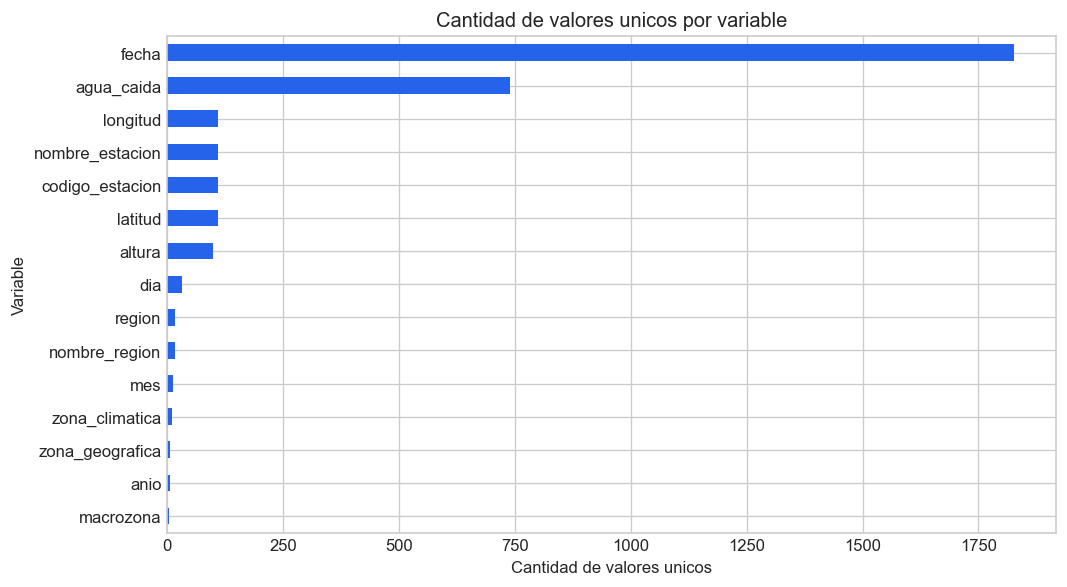

In [163]:
fig, ax = plt.subplots(figsize=(9, 5))
resumen_base["valores_unicos"].sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Cantidad de valores unicos por variable")
ax.set_xlabel("Cantidad de valores unicos")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


In [ ]:
variables_catalogo = [
    ("codigo_estacion", "Categorica nominal codificada", "Identificador tecnico de estacion"),
    ("nombre_estacion", "Categorica nominal", "Identificador descriptivo de estacion"),
    ("region", "Categorica nominal codificada", "Codigo territorial"),
    ("nombre_region", "Categorica nominal", "Referencia territorial descriptiva"),
    ("zona_geografica", "Categorica nominal", "Contexto geografico agregado"),
    ("macrozona", "Categorica nominal derivada", "Agrupacion territorial para analisis"),
    ("zona_climatica", "Categorica nominal derivada", "Agrupacion climatica inferida"),
    ("altura", "Numerica discreta", "Predictor geografico"),
    ("latitud", "Numerica continua", "Predictor geografico"),
    ("longitud", "Numerica continua", "Predictor geografico"),
    ("anio", "Numerica discreta temporal", "Predictor temporal"),
    ("mes", "Numerica discreta temporal", "Predictor temporal"),
    ("dia", "Numerica discreta temporal", "Predictor temporal"),
    ("fecha", "Temporal", "Secuencia cronologica"),
    ("agua_caida", "Numerica continua", "Variable objetivo de regresion"),
]

if "temp_max" in df.columns:
    variables_catalogo.append(("temp_max", "Numerica continua", "Predictor meteorologico: temperatura maxima diaria"))
if "temp_min" in df.columns:
    variables_catalogo.append(("temp_min", "Numerica continua", "Predictor meteorologico: temperatura minima diaria"))
if "temp_media" in df.columns:
    variables_catalogo.append(("temp_media", "Numerica continua", "Predictor meteorologico: temperatura media diaria"))

clasificacion_variables = pd.DataFrame(
    variables_catalogo,
    columns=["variable", "tipo_analitico", "rol_en_el_proyecto"],
)

display(clasificacion_variables)


**Analisis.** El dataset enriquecido queda compuesto por variables de precipitacion, ubicacion, tiempo, metadata territorial y, con el archivo nuevo, tres variables meteorologicas adicionales: `temp_max`, `temp_min` y `temp_media`. Estas temperaturas cambian el entendimiento del problema porque ya no se modela la lluvia solo desde coordenadas, calendario y zona, sino tambien desde condiciones atmosfericas observadas. Un punto metodologico importante es que `codigo_estacion` y `region` no deben interpretarse como magnitudes continuas, ya que expresan etiquetas; en cambio, las temperaturas si son predictores numericos reales y requieren diagnostico de nulos, consistencia y outliers antes de entrar al modelamiento.


### 2.2 Identificar Nulos


Tal como se enfatiza en el material de apoyo, la revision de valores faltantes debe realizarse antes de cualquier transformacion relevante. En esta etapa no solo interesa cuantificar si existen nulos, sino tambien identificar en que variable se concentran y si su distribucion cambia segun zona climatica, macrozona, zona geografica o anio.


In [165]:
tabla_nulos = pd.DataFrame(
    {
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "porcentaje_nulos"], ascending=False)

display(tabla_nulos)


,nulos,porcentaje_nulos
agua_caida,17063,9.08
codigo_estacion,0,0.00
region,0,0.00
altura,0,0.00
latitud,0,0.00
longitud,0,0.00
anio,0,0.00
mes,0,0.00
dia,0,0.00
fecha,0,0.00


Una vez identificado el panorama general de nulos, conviene bajar el analisis a segmentos concretos. En este caso interesa revisar si la ausencia de `agua_caida` cambia segun zona climatica, macrozona, zona geografica y anio, ya que esa distribucion puede afectar la lectura territorial posterior.


In [166]:
nulos_zona_climatica = (
    df.groupby("zona_climatica")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .reindex(ACTIVE_CLIMATE_ORDER)
)

nulos_macrozona = (
    df.groupby("macrozona")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .reindex(MACROZONE_ORDER)
)

nulos_zona_geografica = (
    df.groupby("zona_geografica")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .sort_values("porcentaje_nulos", ascending=False)
)

nulos_anio = (
    df.groupby("anio")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .reset_index()
      .sort_values("anio")
)

display(nulos_zona_climatica)
display(nulos_macrozona)
display(nulos_zona_geografica)
display(nulos_anio.head())


,total,nulos,porcentaje_nulos
zona_climatica,,,
Tropical lluvioso,4018,586,14.58
Desertico costero,14604,1095,7.50
Desertico y Esteparico de altura,6795,1205,17.73
Esteparico costero,5451,161,2.95
Esteparico interior,12673,1146,9.04
Mediterraneo seco,67445,4428,6.57
Mediterraneo seco y humedo,13147,1040,7.91
Templado y lluvioso,21177,2778,13.12
Maritimo lluvioso,17741,3023,17.04


,total,nulos,porcentaje_nulos
macrozona,,,
Norte,43541.0,4193.0,9.63
Centro,67445.0,4428.0,6.57
Sur,47106.0,6047.0,12.84
Austral,29784.0,2395.0,8.04
Otra,NaN,NaN,NaN


,total,nulos,porcentaje_nulos
zona_geografica,,,
PreCordillera,19060,3162,16.59
Cordillera,7527,1203,15.98
Secano Interior,2557,272,10.64
Litoral,64838,5451,8.41
Valle,86617,6757,7.80
Secano Costero,7277,218,3.00


,anio,total,nulos,porcentaje_nulos
0,2021,35606,4215,11.84
1,2022,35735,3412,9.55
2,2023,38325,4799,12.52
3,2024,39162,2954,7.54
4,2025,39048,1683,4.31


Las tablas anteriores dejan cuantificado el problema de completitud por segmento. El grafico siguiente resume esa misma idea a nivel de variable y permite ver de inmediato que el foco real de los faltantes esta concentrado en `agua_caida`, no repartido por toda la base.


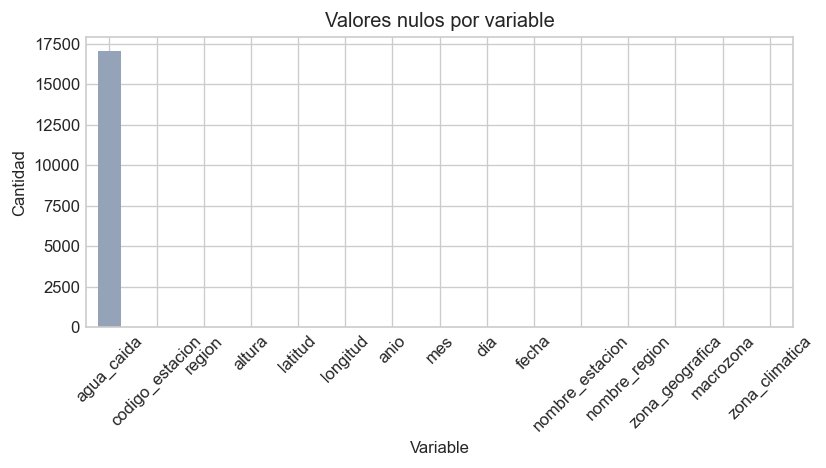

In [167]:
fig, ax = plt.subplots(figsize=(7, 4))
tabla_nulos["nulos"].plot(kind="bar", ax=ax, color="#94a3b8")
ax.set_title("Valores nulos por variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [168]:
nulos_macrozona = nulos_macrozona.query("macrozona != 'Otra'")

Despues del panorama general, conviene visualizar la concentracion de nulos en agregaciones territoriales mas interpretables. La zona climatica permite comparar regimenes de lluvia similares y la macrozona resume grandes franjas del pais. En el caso del anio, el resumen se deja con `anio` como columna explicita para que el `head()` sea mas legible, y la figura se presenta como grafico de torta usando la participacion de los nulos totales por anio, ya que ese formato representa mejor partes de un mismo total.


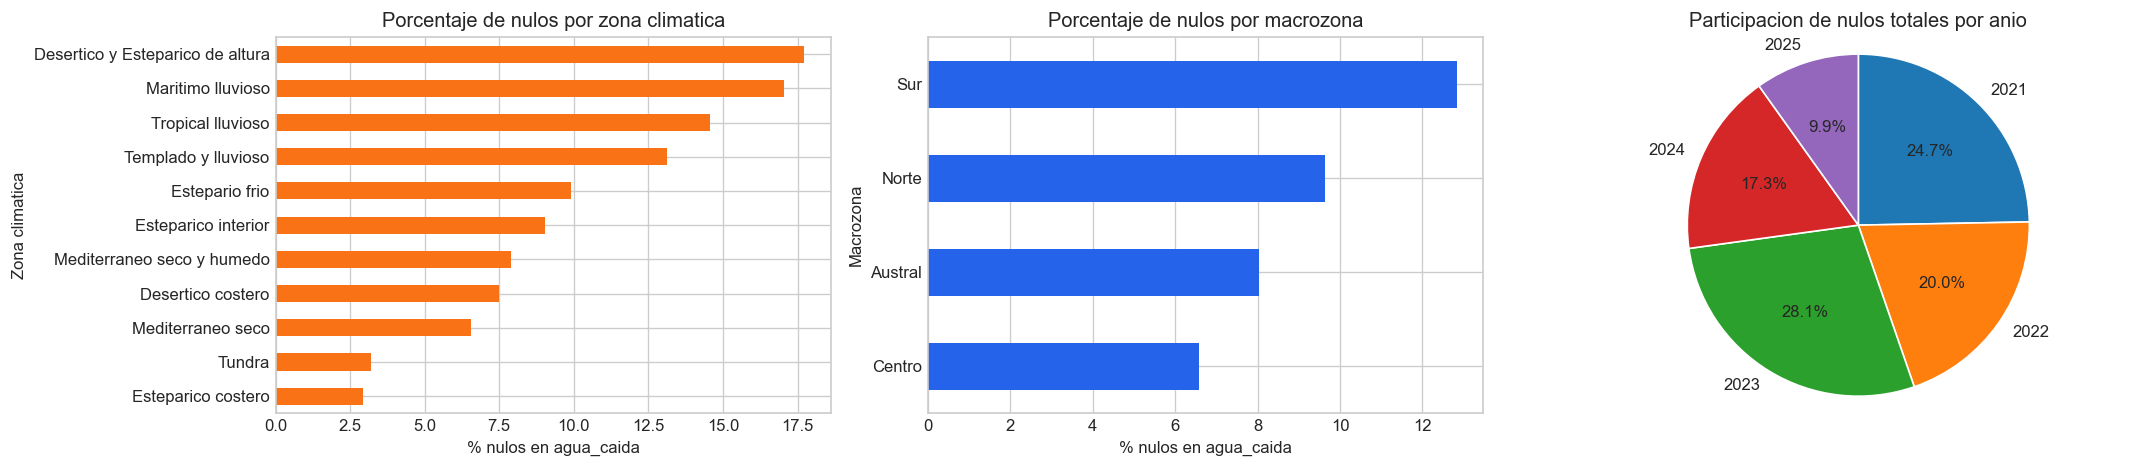

In [169]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

nulos_zona_climatica["porcentaje_nulos"].sort_values().plot(kind="barh", ax=axes[0], color="#f97316")
axes[0].set_title("Porcentaje de nulos por zona climatica")
axes[0].set_xlabel("% nulos en agua_caida")
axes[0].set_ylabel("Zona climatica")

nulos_macrozona["porcentaje_nulos"].sort_values().plot(kind="barh", ax=axes[1], color="#2563eb")
axes[1].set_title("Porcentaje de nulos por macrozona")
axes[1].set_xlabel("% nulos en agua_caida")
axes[1].set_ylabel("Macrozona")

participacion_nulos_anio = nulos_anio.loc[nulos_anio["nulos"] > 0, ["anio", "nulos"]]
axes[2].pie(
    participacion_nulos_anio["nulos"],
    labels=participacion_nulos_anio["anio"].astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
axes[2].set_title("Participacion de nulos totales por anio")
axes[2].axis("equal")

plt.tight_layout()
plt.show()


### Análisis de Calidad de Datos (Nulos)

El diagnóstico de valores faltantes revela que el problema de completitud se concentra exclusivamente en la variable objetivo `agua_caida` (9.08%). Sin embargo, el análisis segmentado por zona climática muestra que la ausencia de datos no es aleatoria: zonas como 'Marítimo Lluvioso' presentan mayores tasas de nulos, posiblemente por dificultades técnicas en estaciones remotas.

Este hallazgo justifica el uso de técnicas de imputación avanzada (como KNN) en lugar de una eliminación simple de registros, ya que descartar casi el 10% de la base podría sesgar los resultados hacia zonas con mejor infraestructura de medición, perdiendo la variabilidad de las zonas más extremas del país.

**Analisis.** El diagnostico muestra que los valores faltantes ya no se concentran solo en `agua_caida`. La precipitacion mantiene 17,063 nulos, equivalentes al 9.08% del total, pero el dataset nuevo tambien incorpora faltantes en `temp_max`, `temp_min` y `temp_media`. Por eso, la decision de preparacion debe ampliarse: `agua_caida` se imputara respetando estacion, mes y zona climatica, mientras que las temperaturas se revisaran con mayor detalle en la subseccion 2.11 y luego se trataran en Fase 3 con imputacion contextual, correcciones de consistencia y banderas de trazabilidad.


### 2.3 Identificar Outliers


La deteccion de outliers debe realizarse con criterio estadistico y tambien con criterio de dominio. En precipitaciones diarias es esperable encontrar una distribucion muy asimetrica, con gran cantidad de ceros y pocos eventos intensos. Por ello se utiliza el rango intercuartil (IQR) como primera referencia robusta: al basarse en Q1 y Q3, resiste mejor los extremos que la media y la desviacion estandar y no exige asumir una distribucion normal. Aun asi, en una variable zero-inflated como `agua_caida`, el IQR no debe interpretarse como una regla automatica de eliminacion, sino como un umbral inicial para diagnosticar que tan alejados estan los eventos intensos del comportamiento habitual.


In [170]:
distribucion_lluvia = pd.DataFrame(
    {
        "indicador": ["Dias sin precipitacion", "Dias con precipitacion", "Registros nulos"],
        "porcentaje": [
            round((df["agua_caida"] == 0).mean() * 100, 2),
            round((df["agua_caida"] > 0).mean() * 100, 2),
            round(df["agua_caida"].isna().mean() * 100, 2),
        ],
    }
)

display(distribucion_lluvia)


,indicador,porcentaje
0,Dias sin precipitacion,67.68
1,Dias con precipitacion,23.24
2,Registros nulos,9.08


El primer paso muestra la composicion general de la variable objetivo. Si predominan los ceros, cualquier regla automatica basada solo en dispersion tendera a sobredetectar supuestos outliers, por lo que conviene interpretar con especial cautela los resultados siguientes.


In [171]:
q1 = df["agua_caida"].quantile(0.25)
q3 = df["agua_caida"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
p95 = df["agua_caida"].quantile(0.95)
p99 = df["agua_caida"].quantile(0.99)


Con el criterio IQR y los percentiles altos ya calculados, se resume la magnitud real del problema. Separar el calculo del reporte final ayuda a distinguir entre el umbral estadistico y su interpretacion analitica posterior.


In [172]:
resumen_outliers = pd.DataFrame(
    {
        "Q1": [round(q1, 2)],
        "Q3": [round(q3, 2)],
        "IQR": [round(iqr, 2)],
        "Limite_superior_IQR": [round(upper, 2)],
        "Percentil_95": [round(p95, 2)],
        "Percentil_99": [round(p99, 2)],
        "Registros_sobre_IQR": [int((df["agua_caida"] > upper).sum())],
        "Registros_sobre_P99": [int((df["agua_caida"] >= p99).sum())],
        "Registros_mayores_100mm": [int((df["agua_caida"] > 100).sum())],
        "Registros_mayores_500mm": [int((df["agua_caida"] > 500).sum())],
    }
)

display(resumen_outliers)


,Q1,Q3,IQR,Limite_superior_IQR,Percentil_95,Percentil_99,Registros_sobre_IQR,Registros_sobre_P99,Registros_mayores_100mm,Registros_mayores_500mm
0,0.0,0.1,0.1,0.25,8.6,27.8,32994,1726,21,5


Aqui ya se observa si el limite IQR resulta demasiado sensible para una variable con muchos ceros. Compararlo con percentiles altos permite separar mejor lo que es simplemente lluvia positiva de lo que realmente parece un valor extremo dentro del conjunto.


In [173]:
extremos_lluvia = (
    df.loc[
        df["agua_caida"].notna(),
        ["fecha", "nombre_estacion", "nombre_region", "zona_geografica", "zona_climatica", "agua_caida"],
    ]
    .sort_values("agua_caida", ascending=False)
    .head(15)
)

display(extremos_lluvia)


,fecha,nombre_estacion,nombre_region,zona_geografica,zona_climatica,agua_caida
75680,2025-12-08,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterraneo seco,3574.300049
133239,2025-12-07,Isla Mocha Ad.,Del BiobÃ­o,Litoral,Mediterraneo seco y humedo,3541.500000
75679,2025-12-07,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterraneo seco,2917.399902
133240,2025-12-09,Isla Mocha Ad.,Del BiobÃ­o,Litoral,Mediterraneo seco y humedo,1459.900024
75681,2025-12-09,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterraneo seco,880.099976
97400,2023-08-21,"General Freire, CuricÃ³ Ad.",Del Maule,Valle,Mediterraneo seco,150.199997
74780,2023-06-22,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterraneo seco,145.199997
123155,2022-04-28,Lonquimay,De La AraucanÃ­a,PreCordillera,Templado y lluvioso,136.399994
138886,2021-05-31,Corral ESSAL,De Los RÃ­os,Litoral,Maritimo lluvioso,126.800003
102878,2023-08-21,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,Secano Interior,Mediterraneo seco,121.300003


La revision manual de los valores mas altos es importante porque entrega contexto concreto: no es lo mismo un valor intenso en una zona arida que un evento fuerte dentro de una zona templada lluviosa o fria patagonica. Por eso se incorporan los nombres de estacion, region, zona geografica y zona climatica en la tabla de extremos.


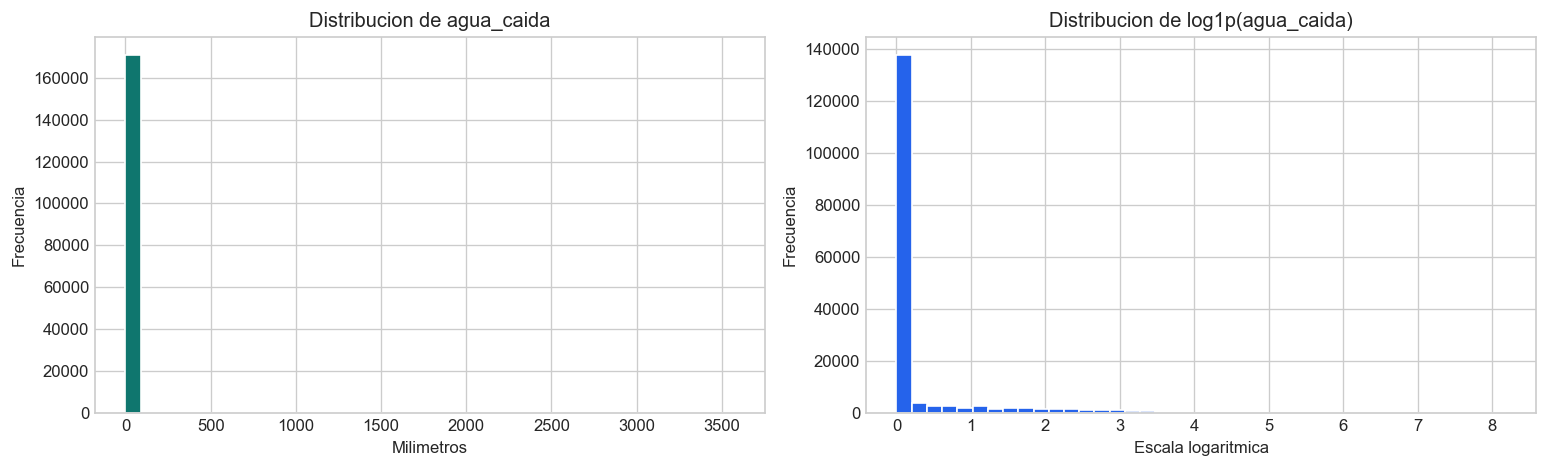

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["agua_caida"].dropna(), bins=40, color="#0f766e", edgecolor="white")
axes[0].set_title("Distribucion de agua_caida")
axes[0].set_xlabel("Milimetros")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["agua_caida"].dropna()), bins=40, color="#2563eb", edgecolor="white")
axes[1].set_title("Distribucion de log1p(agua_caida)")
axes[1].set_xlabel("Escala logaritmica")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Los histogramas muestran la forma global de la variable y dejan ver por que conviene trabajar tambien con una transformacion logaritmica. Para no mezclar todas las `zonas_climaticas` en una sola caja, el siguiente bloque separa los boxplots en subgraficos individuales; asi se aprecia mejor la dispersion propia de cada regimen territorial.


,zona_climatica,registros,mediana,p95
0,Tropical lluvioso,3432,0.0,3.2
1,Desertico costero,13509,0.0,0.0
2,Desertico y Esteparico de altura,5590,0.0,0.0
3,Esteparico costero,5290,0.0,0.1
4,Esteparico interior,11527,0.0,0.1
5,Mediterraneo seco,63017,0.0,3.4
6,Mediterraneo seco y humedo,12107,0.0,15.4
7,Templado y lluvioso,18399,0.0,17.6
8,Maritimo lluvioso,14718,0.2,20.6
9,Estepario frio,10858,0.0,12.4


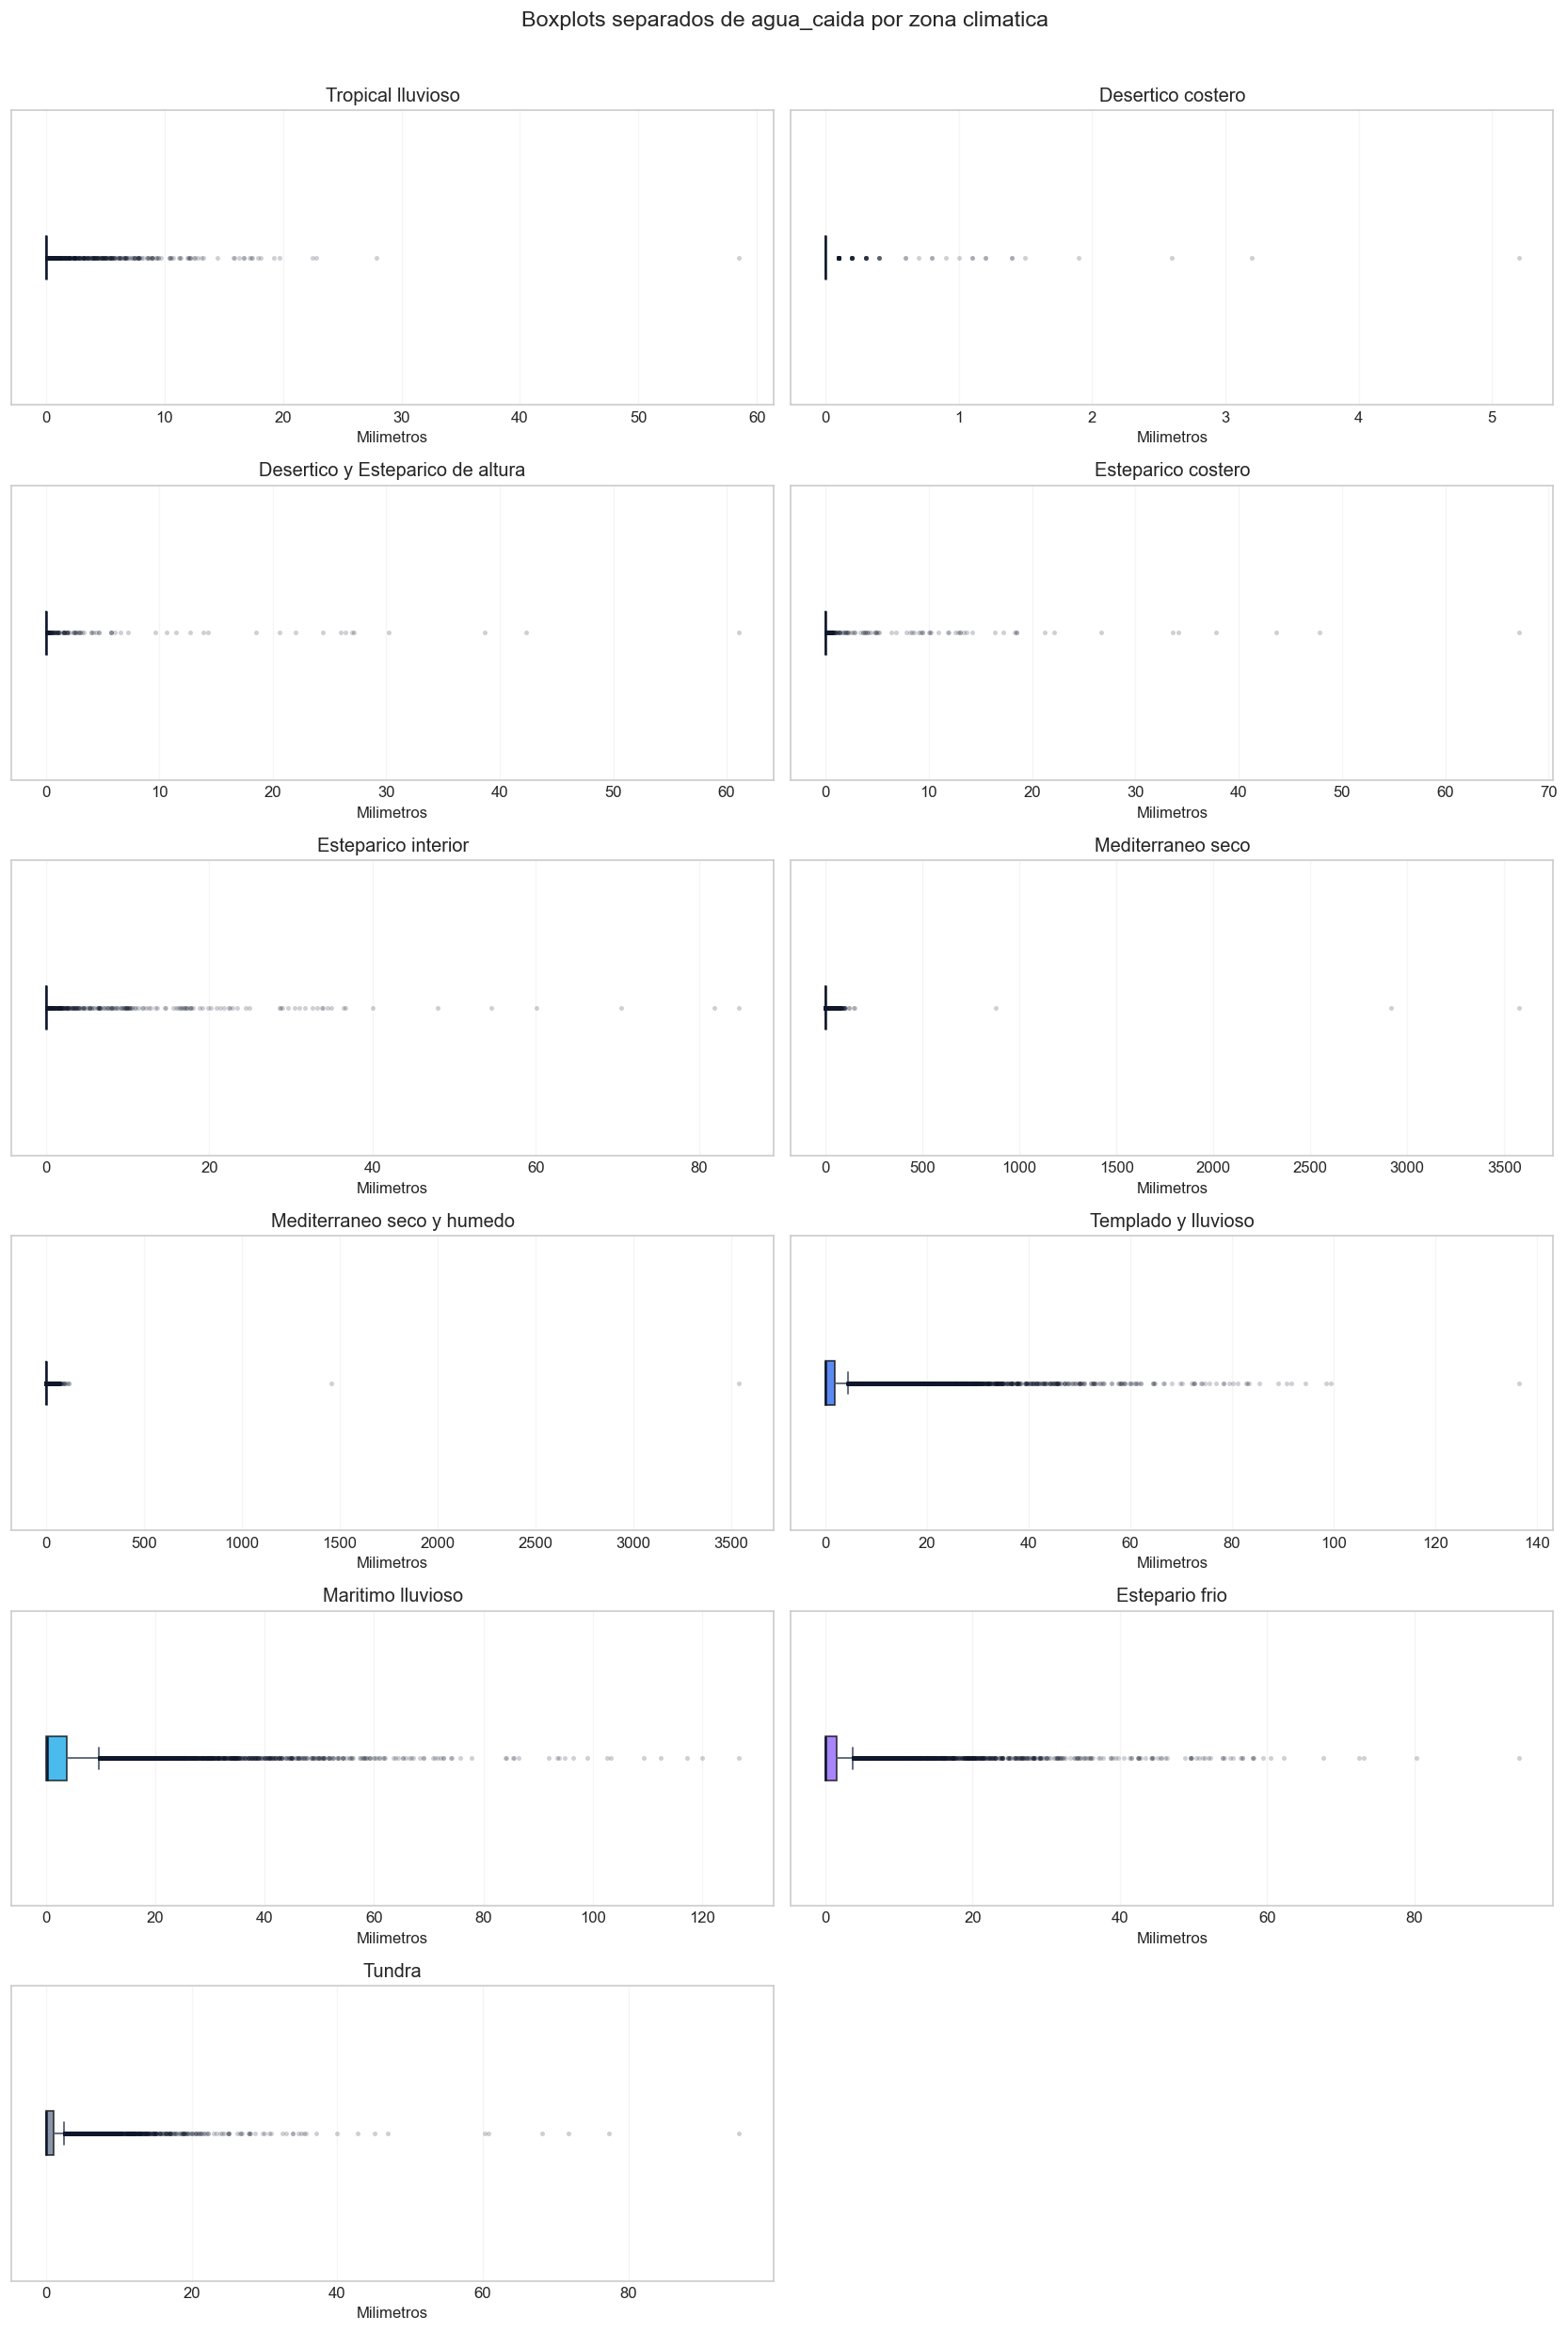

In [175]:
zonas_box = [zona for zona in ACTIVE_CLIMATE_ORDER if df.loc[df["zona_climatica"] == zona, "agua_caida"].notna().any()]
resumen_boxplots = pd.DataFrame(
    {
        "zona_climatica": zonas_box,
        "registros": [int(df.loc[df["zona_climatica"] == zona, "agua_caida"].notna().sum()) for zona in zonas_box],
        "mediana": [round(df.loc[df["zona_climatica"] == zona, "agua_caida"].median(), 2) for zona in zonas_box],
        "p95": [round(df.loc[df["zona_climatica"] == zona, "agua_caida"].quantile(0.95), 2) for zona in zonas_box],
    }
)

display(resumen_boxplots)

ncols = 2
nrows = int(np.ceil(len(zonas_box) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, zona in zip(axes, zonas_box):
    datos_zona = df.loc[df["zona_climatica"] == zona, "agua_caida"].dropna()
    ax.boxplot(
        datos_zona,
        vert=False,
        patch_artist=True,
        boxprops={"facecolor": CLIMATE_COLORS.get(zona, "#cbd5e1"), "alpha": 0.75},
        medianprops={"color": "#0f172a", "linewidth": 1.5},
        whiskerprops={"color": "#475569"},
        capprops={"color": "#475569"},
        flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#0f172a", "alpha": 0.2, "markeredgecolor": "none"},
    )
    ax.set_title(zona)
    ax.set_xlabel("Milimetros")
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.2)

for ax in axes[len(zonas_box):]:
    ax.axis("off")

fig.suptitle("Boxplots separados de agua_caida por zona climatica", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Para complementar la lectura de outliers, conviene mantener una visualizacion temporal, pero en un formato mas interpretable. En vez de mezclar todos los puntos en escala lineal, el siguiente bloque separa la lectura en dos paneles: a la izquierda se muestra la nube en escala logaritmica para recuperar visibilidad en los valores bajos y medios; a la derecha se muestran solo los eventos realmente extremos, es decir, aquellos ubicados sobre el percentil 99.


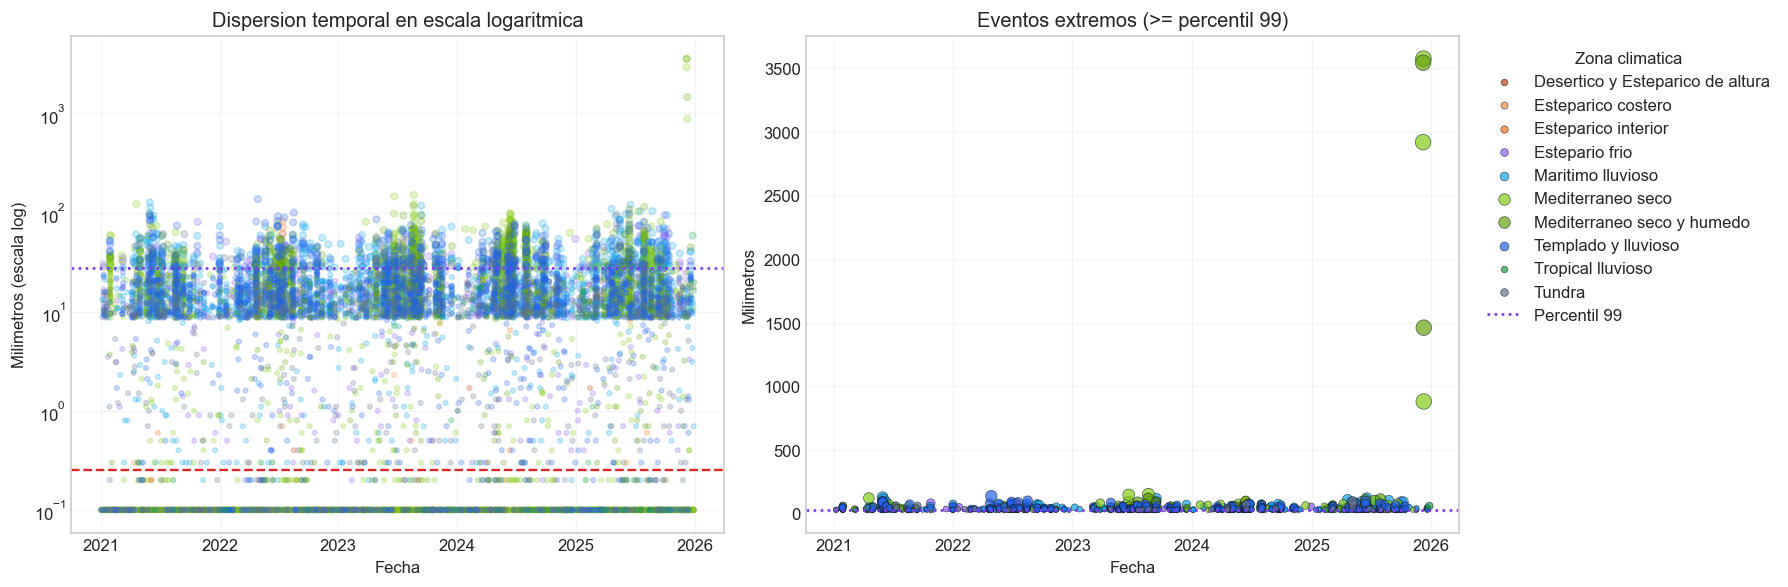

In [176]:
muestra_dispersion = df.loc[df["agua_caida"].notna(), ["fecha", "agua_caida", "zona_climatica"]].copy()

muestra_regular = muestra_dispersion.loc[muestra_dispersion["agua_caida"] < p95].sample(
    n=min(4000, int((muestra_dispersion["agua_caida"] < p95).sum())),
    random_state=42,
)
muestra_intermedia = muestra_dispersion.loc[
    (muestra_dispersion["agua_caida"] >= p95) & (muestra_dispersion["agua_caida"] < p99)
]
muestra_extrema = muestra_dispersion.loc[muestra_dispersion["agua_caida"] >= p99].sort_values("fecha")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

muestra_log = pd.concat([muestra_regular, muestra_intermedia, muestra_extrema], axis=0).sort_values("fecha")
for zona, subset in muestra_log.groupby("zona_climatica"):
    axes[0].scatter(
        subset["fecha"],
        subset["agua_caida"] + 0.1,
        s=np.where(subset["agua_caida"] >= p99, 16, 8),
        alpha=0.22,
        color=CLIMATE_COLORS.get(zona, "#94a3b8"),
        label=zona,
    )

axes[0].axhline(max(upper, 0.1), color="#dc2626", linestyle="--", linewidth=1.4, label="Limite IQR")
axes[0].axhline(max(p99, 0.1), color="#7c3aed", linestyle=":", linewidth=1.6, label="Percentil 99")
axes[0].set_yscale("log")
axes[0].set_title("Dispersion temporal en escala logaritmica")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Milimetros (escala log)")
axes[0].grid(alpha=0.2)

for zona, subset in muestra_extrema.groupby("zona_climatica"):
    axes[1].scatter(
        subset["fecha"],
        subset["agua_caida"],
        s=subset["agua_caida"].clip(upper=250) * 0.35,
        alpha=0.7,
        color=CLIMATE_COLORS.get(zona, "#94a3b8"),
        edgecolors="#0f172a",
        linewidth=0.4,
        label=zona,
    )

axes[1].axhline(p99, color="#7c3aed", linestyle=":", linewidth=1.6, label="Percentil 99")
axes[1].set_title("Eventos extremos (>= percentil 99)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Milimetros")
axes[1].grid(alpha=0.2)

handles, labels = axes[1].get_legend_handles_labels()
legend_items = dict(zip(labels, handles))
axes[1].legend(legend_items.values(), legend_items.keys(), title="Zona climatica", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Análisis de Outliers y Distribución

La precipitación es, por naturaleza, una variable con una distribución altamente asimétrica ('Zero-Inflated'). El análisis muestra que más del 67% de los días no registran lluvia.

**Puntos críticos del diagnóstico:**
* **Sensibilidad del IQR:** El límite estadístico convencional (0.25 mm) es extremadamente bajo para capturar la realidad climática chilena.
* **Eventos Extremos:** Hemos identificado registros que superan los 100 mm diarios. Estos no deben tratarse como errores de medición, sino como eventos meteorológicos de alto impacto (ej. núcleos fríos o frentes intensos).
* **Transformación Logarítmica:** Para el modelamiento predictivo, se ha preparado la variable `log1p(agua_caida)`, que permite 'comprimir' la escala de los extremos y facilitar que los algoritmos identifiquen patrones en los rangos de lluvia débil y moderada sin ser dominados por los valores atípicos.

**Analisis.** La escala lineal original hacia muy dificil interpretar la nube completa, porque unos pocos eventos extremos comprimian visualmente al resto de los datos. Por eso no conviene reemplazar esos valores por la media: hacerlo borraria episodios reales de precipitacion intensa y distorsionaria la serie. La solucion mas coherente es conservar los extremos y cambiar la forma de mirarlos. El panel izquierdo, en escala logaritmica, deja ver mejor la masa principal de observaciones y confirma que el umbral IQR es demasiado bajo para una variable tan sesgada. El panel derecho se concentra solo en el percentil 99 y permite estudiar los episodios realmente excepcionales sin ocultar su magnitud. De este modo, los outliers se interpretan como eventos a revisar y modelar con cautela, no como errores que deban sustituirse por un promedio global.


### 2.4 Transformaciones


Sobre la base del diagnostico anterior, se define un conjunto de trabajo orientado al analisis. Esta etapa no busca todavia optimizar un modelo, sino dejar la informacion en una forma mas interpretable y util para las fases posteriores, manteniendo tanto la trazabilidad territorial como la secuencia temporal de los registros.


In [177]:
columnas_trabajo = [
    "codigo_estacion", "nombre_estacion", "region", "nombre_region", "zona_geografica",
    "macrozona", "zona_climatica", "altura", "latitud", "longitud", "anio", "mes", "dia", "fecha", "agua_caida"
]

df_trabajo = df[columnas_trabajo].copy()

print("Columnas seleccionadas para el trabajo analitico:")
display(pd.DataFrame({"columnas": df_trabajo.columns}))
display(df_trabajo.head())


Columnas seleccionadas para el trabajo analitico:


,columnas
0,codigo_estacion
1,nombre_estacion
2,region
3,nombre_region
4,zona_geografica
5,macrozona
6,zona_climatica
7,altura
8,latitud
9,longitud


,codigo_estacion,nombre_estacion,region,nombre_region,zona_geografica,macrozona,zona_climatica,altura,latitud,longitud,anio,mes,dia,fecha,agua_caida
0,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,1,2023-01-01,NaN
1,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,2,2023-01-02,NaN
2,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,3,2023-01-03,NaN
3,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,4,2023-01-04,NaN
4,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,5,2023-01-05,NaN


**Analisis.** El conjunto de trabajo conserva tanto identificadores tecnicos como descriptores territoriales. A los pares `codigo_estacion`/`nombre_estacion` y `region`/`nombre_region` se suman `zona_geografica`, `macrozona` y `zona_climatica`, porque en esta entrega interesa comparar el comportamiento de la precipitacion en distintas escalas espaciales y no solo dejar una base minima para modelamiento.


#### 2.4.1 A numericos (Encoder)


Las variables categoricas nominales deben transformarse a una representacion numerica cuando se desea utilizarlas en procedimientos cuantitativos. Siguiendo el material de apoyo, la estrategia mas consistente en este caso es `one-hot encoding`, ya que no existe un orden natural entre regiones, zonas geograficas ni zonas climaticas. Sin embargo, conviene aplicar esta transformacion con criterio, porque atributos de muy alta cardinalidad, como la estacion, pueden multiplicar innecesariamente el numero de columnas.


In [178]:
df_encoder = pd.get_dummies(
    df_trabajo[["nombre_region", "zona_geografica", "zona_climatica"]],
    columns=["nombre_region", "zona_geografica", "zona_climatica"],
    drop_first=False,
    dtype=int,
)

print(f"Shape original de columnas categoricas seleccionadas: {df_trabajo[['nombre_region', 'zona_geografica', 'zona_climatica']].shape}")
print(f"Shape despues del encoding: {df_encoder.shape}")
display(df_encoder.head())


Shape original de columnas categoricas seleccionadas: (187876, 3)
Shape despues del encoding: (187876, 33)


,nombre_region_Antofagasta,nombre_region_Arica y Parinacota,nombre_region_Atacama,nombre_region_AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,nombre_region_Coquimbo,nombre_region_De La AraucanÃ­a,nombre_region_De Los Lagos,nombre_region_De Los RÃ­os,nombre_region_De Ãuble,nombre_region_Del BiobÃ­o,nombre_region_Del Libertador Gral. Bernardo O'Higgins,nombre_region_Del Maule,nombre_region_Magallanes y de la AntÃ¡rtica Chilena,nombre_region_Metropolitana de Santiago,nombre_region_TarapacÃ¡,nombre_region_ValparaÃ­so,zona_geografica_Cordillera,zona_geografica_Litoral,zona_geografica_PreCordillera,zona_geografica_Secano Costero,zona_geografica_Secano Interior,zona_geografica_Valle,zona_climatica_Desertico costero,zona_climatica_Desertico y Esteparico de altura,zona_climatica_Esteparico costero,zona_climatica_Esteparico interior,zona_climatica_Estepario frio,zona_climatica_Maritimo lluvioso,zona_climatica_Mediterraneo seco,zona_climatica_Mediterraneo seco y humedo,zona_climatica_Templado y lluvioso,zona_climatica_Tropical lluvioso,zona_climatica_Tundra
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


**Analisis.** Se utiliza `one-hot encoding` porque `nombre_region`, `zona_geografica` y `zona_climatica` son categorias nominales sin jerarquia intrinseca. Esta decision evita imponer relaciones artificiales entre territorios. En esta fase no se codifica la estacion de manera exhaustiva, ya que su alta cardinalidad incrementaria considerablemente el numero de columnas y dificultaria la interpretacion inicial. Por lo tanto, se privilegia una codificacion territorial compacta y alineada con el objetivo de entendimiento de datos.


#### 2.4.2 Tratamiento de Nulos

Dado que los nulos se concentran en `agua_caida`, el tratamiento debe conservar la lectura territorial y temporal sin volver el notebook innecesariamente lento. Para la fase exploratoria se usa una imputacion jerarquica por contexto: primero la mediana de la misma estacion y mes, luego la mediana de zona climatica y mes, y finalmente la mediana global. Esta estrategia es robusta frente a extremos, respeta estacionalidad y permite que el resto del EDA corra rapido.

`KNNImputer` se reserva para la Fase 3 como alternativa tecnica visible, porque en este volumen puede tardar varios minutos. Esta separacion evita duplicar imputaciones caras y mantiene el flujo reproducible.

In [179]:
nulos_originales = int(df_trabajo["agua_caida"].isna().sum())

df_modelo = df_trabajo.copy()
df_modelo["agua_caida_imputada"] = df_modelo["agua_caida"].isna().astype(int)

mediana_estacion_mes = df_modelo.groupby(["codigo_estacion", "mes"], observed=True)["agua_caida"].transform("median")
mediana_clima_mes = df_modelo.groupby(["zona_climatica", "mes"], observed=True)["agua_caida"].transform("median")
mediana_global = df_modelo["agua_caida"].median()

df_modelo["agua_caida"] = (
    df_modelo["agua_caida"]
    .fillna(mediana_estacion_mes)
    .fillna(mediana_clima_mes)
    .fillna(mediana_global)
    .clip(lower=0)
)

resumen_limpieza_nulos = pd.DataFrame(
    {
        "filas_totales": [len(df_modelo)],
        "nulos_originales_agua_caida": [nulos_originales],
        "nulos_restantes_agua_caida": [int(df_modelo["agua_caida"].isna().sum())],
        "porcentaje_imputado": [round(df_modelo["agua_caida_imputada"].mean() * 100, 2)],
        "metodo": ["mediana jerarquica estacion-mes / clima-mes / global"],
    }
)

display(resumen_limpieza_nulos)

,filas_totales,nulos_originales_agua_caida,nulos_restantes_agua_caida,porcentaje_imputado,metodo
0,187876,17063,0,9.08,mediana jerarquica estacion-mes / clima-mes / ...


La comparacion entre observados e imputados permite revisar si la imputacion genero valores razonables. En una variable con muchos ceros es normal que la mediana sea baja; por eso se comparan media, mediana y percentil 95, no solo el promedio.

In [180]:
comparacion_imputacion = pd.DataFrame(
    {
        "grupo": ["Valores observados", "Valores imputados"],
        "media": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].mean(), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].mean(), 2),
        ],
        "mediana": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].median(), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].median(), 2),
        ],
        "p95": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].quantile(0.95), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].quantile(0.95), 2),
        ],
    }
)

display(comparacion_imputacion)

,grupo,media,mediana,p95
0,Valores observados,1.49,0.0,8.60
1,Valores imputados,0.21,0.0,1.25


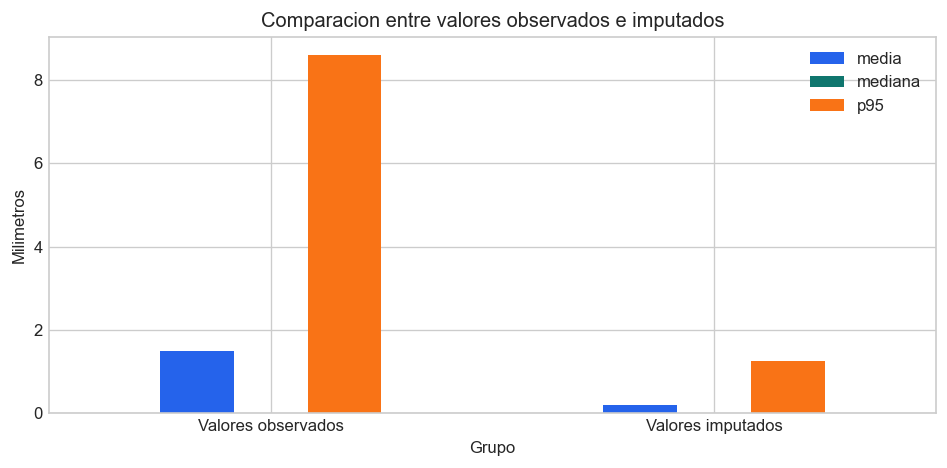

In [181]:
fig, ax = plt.subplots(figsize=(8, 4))
comparacion_imputacion.set_index("grupo")[["media", "mediana", "p95"]].plot(
    kind="bar", ax=ax, color=["#2563eb", "#0f766e", "#f97316"]
)
ax.set_title("Comparacion entre valores observados e imputados")
ax.set_xlabel("Grupo")
ax.set_ylabel("Milimetros")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Analisis.** La imputacion jerarquica conserva todas las filas y respeta la logica climatica de la base sin pagar dos veces el costo de un KNN completo. La marca `agua_caida_imputada` queda disponible para distinguir mediciones observadas de estimaciones, algo clave si luego se decide excluir targets imputados para una evaluacion estrictamente supervisada.

#### 2.4.3 Tratamiento de Outliers


En un problema climaticamente variable, eliminar outliers de manera automatica puede implicar la perdida de eventos relevantes. En consecuencia, se adopta una estrategia conservadora: mantener los registros, crear una transformacion logaritmica que reduzca la asimetria y agregar marcas que permitan identificar eventos extremos para revisiones posteriores.


In [182]:
Q1 = df_modelo["agua_caida"].quantile(0.25)
Q3 = df_modelo["agua_caida"].quantile(0.75)
IQR = Q3 - Q1
umbral_iqr_superior = Q3 + 1.5 * IQR
umbral_extremo_p99 = df_modelo["agua_caida"].quantile(0.99)

# En Fase 2 se diagnostican extremos sin reemplazarlos: la precipitacion intensa puede ser senal real.
df_modelo["agua_caida_log"] = np.log1p(df_modelo["agua_caida"])
df_modelo["evento_extremo_p99"] = (df_modelo["agua_caida"] >= umbral_extremo_p99).astype(int)
df_modelo["revision_manual_mayor_100"] = (df_modelo["agua_caida"] > 100).astype(int)

resumen_iqr_diagnostico = pd.DataFrame(
    {
        "Q1": [round(Q1, 2)],
        "Q3": [round(Q3, 2)],
        "IQR": [round(IQR, 2)],
        "umbral_iqr_superior": [round(umbral_iqr_superior, 2)],
        "umbral_p99": [round(umbral_extremo_p99, 2)],
        "registros_sobre_iqr": [int((df_modelo["agua_caida"] > umbral_iqr_superior).sum())],
        "eventos_extremos_p99": [int(df_modelo["evento_extremo_p99"].sum())],
    }
)

display(resumen_iqr_diagnostico)
display(
    df_modelo[["agua_caida", "agua_caida_log", "evento_extremo_p99", "revision_manual_mayor_100"]].head()
)

,Q1,Q3,IQR,umbral_iqr_superior,umbral_p99,registros_sobre_iqr,eventos_extremos_p99
0,0.0,0.1,0.1,0.25,26.6,35522,1898


,agua_caida,agua_caida_log,evento_extremo_p99,revision_manual_mayor_100
0,0.8,0.587787,0,0
1,0.8,0.587787,0,0
2,0.8,0.587787,0,0
3,0.8,0.587787,0,0
4,0.8,0.587787,0,0


Primero se crean variables auxiliares que no eliminan informacion, sino que la vuelven mas manejable. La transformacion logaritmica reduce la asimetria, mientras que los indicadores binarios separan registros usuales de episodios intensos.


In [183]:
comparacion_escala = df_modelo[["agua_caida", "agua_caida_log"]].describe().T.round(2)
resumen_extremos = pd.DataFrame(
    {
        "umbral_p99": [round(umbral_extremo_p99, 2)],
        "eventos_extremos_p99": [int(df_modelo["evento_extremo_p99"].sum())],
        "registros_mayores_100mm": [int(df_modelo["revision_manual_mayor_100"].sum())],
        "registros_mayores_500mm": [int((df_modelo["agua_caida"] > 500).sum())],
    }
)

display(comparacion_escala)
display(resumen_extremos)


,count,mean,std,min,25%,50%,75%,max
agua_caida,187876.0,1.38,14.95,0.0,0.0,0.0,0.1,3574.30
agua_caida_log,187876.0,0.30,0.73,0.0,0.0,0.0,0.1,8.18


,umbral_p99,eventos_extremos_p99,registros_mayores_100mm,registros_mayores_500mm
0,26.6,1898,21,5


**Analisis.** La estrategia seleccionada no elimina precipitaciones extremas, sino que conserva los registros y los hace mas manejables desde el punto de vista analitico. La transformacion `log1p` reduce la dispersion de la variable y facilita posteriores comparaciones, mientras que `evento_extremo_p99` permite identificar observaciones inusuales sin expulsarlas del conjunto. Este enfoque es mas consistente con la naturaleza del problema, ya que los eventos poco frecuentes forman parte del fenomeno estudiado.


### 2.5 Analisis estadisticos basicos


Una vez revisada la calidad general del dataset, corresponde resumir sus principales estadisticas descriptivas. En esta subseccion se examinan tanto las variables numericas base como la forma en que la precipitacion cambia entre zonas climaticas, estaciones, zonas geograficas y regiones, con el fin de caracterizar el comportamiento general del conjunto antes de avanzar a correlaciones y construccion de nuevas variables.


In [184]:
estadisticas_numericas = (
    df_modelo[["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida", "agua_caida_log"]]
    .describe()
    .T
    .round(2)
)

display(estadisticas_numericas)


,count,mean,std,min,25%,50%,75%,max
altura,187876.0,441.95,741.22,5.00,53.00,156.00,474.00,4084.00
latitud,187876.0,-35.85,8.86,-62.19,-40.08,-33.73,-32.22,-17.60
longitud,187876.0,-71.69,4.18,-109.43,-72.34,-71.19,-70.68,-58.98
anio,187876.0,2023.05,1.41,2021.00,2022.00,2023.00,2024.00,2025.00
mes,187876.0,6.51,3.44,1.00,4.00,7.00,9.00,12.00
dia,187876.0,15.72,8.80,1.00,8.00,16.00,23.00,31.00
agua_caida,187876.0,1.38,14.95,0.00,0.00,0.00,0.10,3574.30
agua_caida_log,187876.0,0.30,0.73,0.00,0.00,0.00,0.10,8.18


Este bloque resume el comportamiento global de las variables numericas. En especial, interesa comparar media, mediana y maximos de `agua_caida` para verificar cuan asimetrica sigue siendo la distribucion incluso despues del tratamiento de nulos y de la creacion de `agua_caida_log`.


In [185]:
resumen_climatico = (
    df_modelo.groupby("zona_climatica")
    .agg(
        estaciones=("nombre_estacion", "nunique"),
        regiones=("nombre_region", "nunique"),
        zonas_geograficas=("zona_geografica", "nunique"),
        media_lluvia=("agua_caida", "mean"),
        mediana_lluvia=("agua_caida", "median"),
        maximo_lluvia=("agua_caida", "max"),
        frecuencia_lluvia=("agua_caida", lambda s: (s > 0).mean() * 100),
    )
    .reindex(ACTIVE_CLIMATE_ORDER)
    .round(2)
)

display(resumen_climatico)


,estaciones,regiones,zonas_geograficas,media_lluvia,mediana_lluvia,maximo_lluvia,frecuencia_lluvia
zona_climatica,,,,,,,
Tropical lluvioso,3,2,2,0.43,0.0,58.5,15.83
Desertico costero,8,3,1,0.00,0.0,5.2,0.53
Desertico y Esteparico de altura,4,2,2,0.09,0.0,61.1,1.94
Esteparico costero,3,2,1,0.15,0.0,67.1,6.05
Esteparico interior,8,2,1,0.19,0.0,84.9,4.96
Mediterraneo seco,39,4,6,0.92,0.0,3574.3,15.90
Mediterraneo seco y humedo,8,2,3,2.58,0.0,3541.5,33.09
Templado y lluvioso,12,3,2,2.63,0.0,136.4,45.97
Maritimo lluvioso,10,4,1,3.47,0.2,126.8,57.54


Luego se cambia la lectura puramente agregada por una vista con recuentos observados. En vez de quedarse solo con promedios, esta figura muestra cuantas filas reales aporta cada combinacion de `zona_climatica` y `macrozona`, cuantos dias con lluvia concentra y cuantas estaciones participan en esa clase territorial.


,zona_climatica,macrozona,registros,dias_con_lluvia,porcentaje_lluvia,estaciones
0,Desertico costero,Norte,14604,78,0.5,8
1,Desertico y Esteparico de altura,Norte,6795,132,1.9,4
2,Esteparico costero,Norte,5451,330,6.1,3
3,Esteparico interior,Norte,12673,628,5.0,8
10,Tropical lluvioso,Norte,4018,636,15.8,3
5,Maritimo lluvioso,Austral,4959,3074,62.0,3
8,Mediterraneo seco y humedo,Sur,13147,4350,33.1,8
4,Estepario frio,Austral,12052,5853,48.6,7
11,Tundra,Austral,12773,6023,47.2,7
6,Maritimo lluvioso,Sur,12782,7135,55.8,7


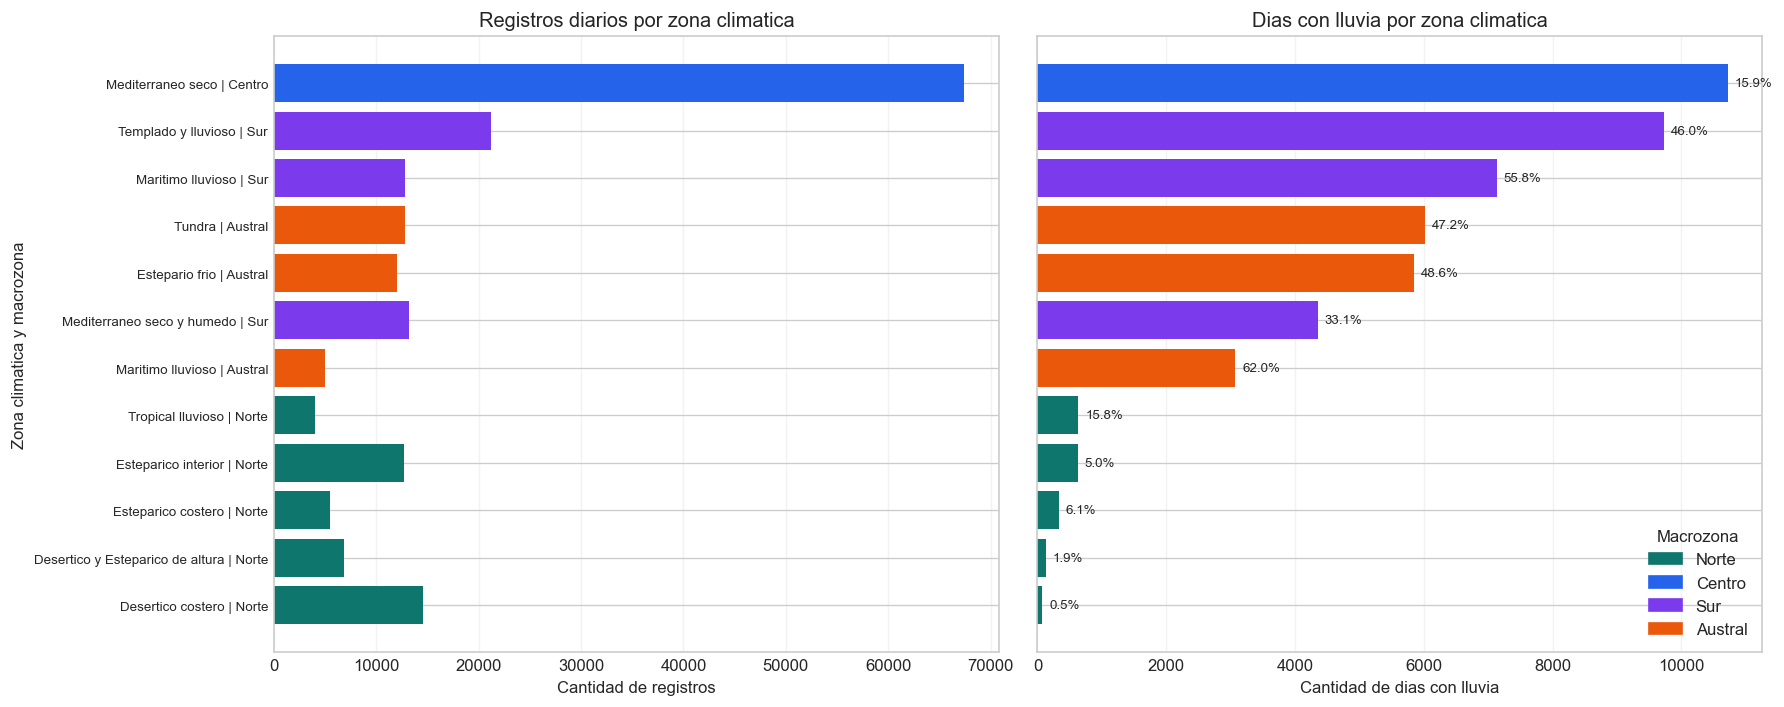

In [186]:
resumen_climatico_dispersion = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby(["zona_climatica", "macrozona"])
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        estaciones=("nombre_estacion", "nunique"),
    )
    .reset_index()
)

resumen_climatico_dispersion["porcentaje_lluvia"] = (
    resumen_climatico_dispersion["dias_con_lluvia"]
    .div(resumen_climatico_dispersion["registros"])
    .mul(100)
    .round(1)
)
resumen_climatico_dispersion["etiqueta"] = (
    resumen_climatico_dispersion["zona_climatica"]
    + " | "
    + resumen_climatico_dispersion["macrozona"]
)
resumen_climatico_dispersion = resumen_climatico_dispersion.sort_values(
    ["dias_con_lluvia", "registros"],
    ascending=True,
)

display(
    resumen_climatico_dispersion[[
        "zona_climatica", "macrozona", "registros", "dias_con_lluvia", "porcentaje_lluvia", "estaciones"
    ]]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
bar_colors = resumen_climatico_dispersion["macrozona"].map(MACROZONE_COLORS)

y_pos = np.arange(len(resumen_climatico_dispersion))
axes[0].barh(y_pos, resumen_climatico_dispersion["registros"], color=bar_colors)
axes[0].set_title("Registros diarios por zona climatica")
axes[0].set_xlabel("Cantidad de registros")
axes[0].set_ylabel("Zona climatica y macrozona")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(resumen_climatico_dispersion["etiqueta"], fontsize=8)
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(y_pos, resumen_climatico_dispersion["dias_con_lluvia"], color=bar_colors)
axes[1].set_title("Dias con lluvia por zona climatica")
axes[1].set_xlabel("Cantidad de dias con lluvia")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(resumen_climatico_dispersion["etiqueta"], fontsize=8)
axes[1].grid(axis="x", alpha=0.25)

for idx, (_, row) in enumerate(resumen_climatico_dispersion.iterrows()):
    axes[1].text(
        row["dias_con_lluvia"] + max(resumen_climatico_dispersion["dias_con_lluvia"]) * 0.01,
        idx,
        f'{row["porcentaje_lluvia"]:.1f}%',
        va="center",
        fontsize=8,
    )

macro_handles = [
    Patch(color=MACROZONE_COLORS[mz], label=mz)
    for mz in MACROZONE_ORDER
    if mz in resumen_climatico_dispersion["macrozona"].unique()
]
axes[1].legend(handles=macro_handles, title="Macrozona", loc="lower right")

plt.tight_layout()
plt.show()


**Analisis.** Esta version compara mejor cada clase territorial porque separa dos preguntas distintas: cuanta informacion aporta cada zona y cuantos dias con lluvia concentra realmente. Al usar barras horizontales, los nombres largos siguen siendo legibles y la macrozona queda clara mediante el color. Ademas, el porcentaje anotado al costado permite distinguir zonas con muchos registros pero baja frecuencia de lluvia respecto de otras con menos observaciones, pero una ocurrencia relativamente mayor del fenomeno.

### 2.6 Matriz de Correlacion


La correlacion inicial se calcula primero sobre variables numericas en bruto y utilizando el coeficiente de Pearson, tal como se revisa en el material de apoyo. Sin embargo, en esta entrega no conviene quedarse solo con una matriz global, porque las relaciones pueden cambiar bastante entre `Litoral`, `Valle`, `Cordillera`, `PreCordillera` y las demas `zonas_geograficas`. Por eso se presenta una matriz general y luego una version separada por cada zona geografica.


In [187]:
columnas_corr_inicial = ["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida"]

corr_inicial = df_modelo[columnas_corr_inicial].corr(numeric_only=True).round(3)

corr_inicial_por_zona = {
    zona: (
        df_modelo.loc[df_modelo["zona_geografica"] == zona, columnas_corr_inicial]
        .corr(numeric_only=True)
        .round(3)
    )
    for zona in ACTIVE_GEO_ORDER
}

resumen_corr_inicial_zona = pd.DataFrame(
    {
        zona: matriz["agua_caida"].drop("agua_caida")
        for zona, matriz in corr_inicial_por_zona.items()
    }
).T.round(3)

resumen_corr_inicial_zona.index.name = "zona_geografica"

display(corr_inicial)
display(corr_inicial["agua_caida"].sort_values(ascending=False))
display(resumen_corr_inicial_zona)


,altura,latitud,longitud,anio,mes,dia,agua_caida
altura,1.000,0.393,0.182,0.043,-0.002,-0.000,-0.027
latitud,0.393,1.000,-0.062,0.013,-0.002,-0.000,-0.044
longitud,0.182,-0.062,1.000,0.006,-0.001,-0.000,-0.026
anio,0.043,0.013,0.006,1.000,0.005,0.001,0.014
mes,-0.002,-0.002,-0.001,0.005,1.000,0.010,0.010
dia,-0.000,-0.000,-0.000,0.001,0.010,1.000,-0.004
agua_caida,-0.027,-0.044,-0.026,0.014,0.010,-0.004,1.000


agua_caida    1.000
anio          0.014
mes           0.010
dia          -0.004
longitud     -0.026
altura       -0.027
latitud      -0.044
Name: agua_caida, dtype: float64

,altura,latitud,longitud,anio,mes,dia
zona_geografica,,,,,,
Cordillera,0.123,0.062,-0.042,0.065,-0.044,0.014
Litoral,-0.021,-0.038,-0.025,0.018,0.010,-0.006
PreCordillera,-0.014,-0.015,-0.009,0.018,0.019,-0.008
Secano Costero,-0.045,-0.077,-0.069,0.014,0.010,0.006
Secano Interior,0.031,-0.031,-0.031,-0.007,0.023,0.005
Valle,-0.107,-0.131,-0.170,0.022,0.013,-0.000


La celda anterior produce tanto la matriz global como un resumen de la correlacion de `agua_caida` por `zona_geografica`. Los heatmaps siguientes traducen ese resultado a una lectura visual mas directa, separando la estructura nacional de las diferencias territoriales mas finas.


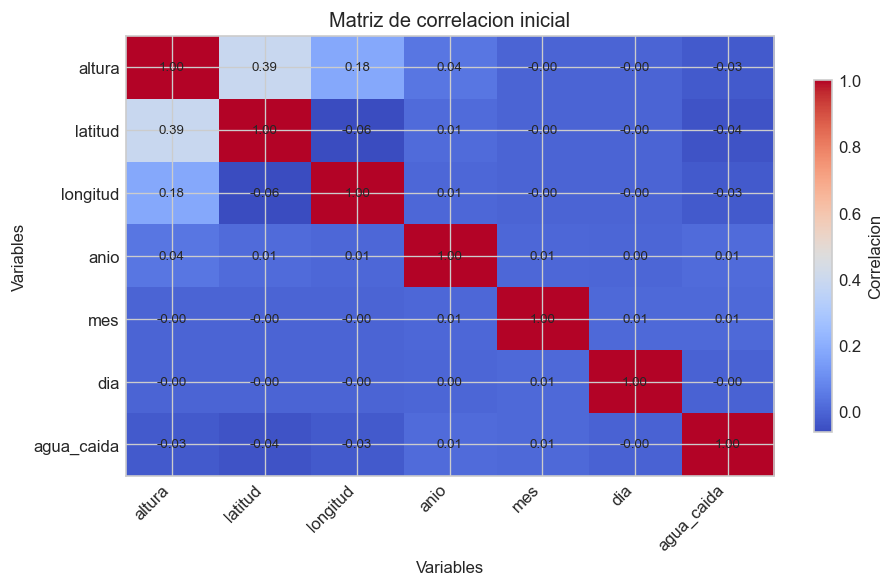

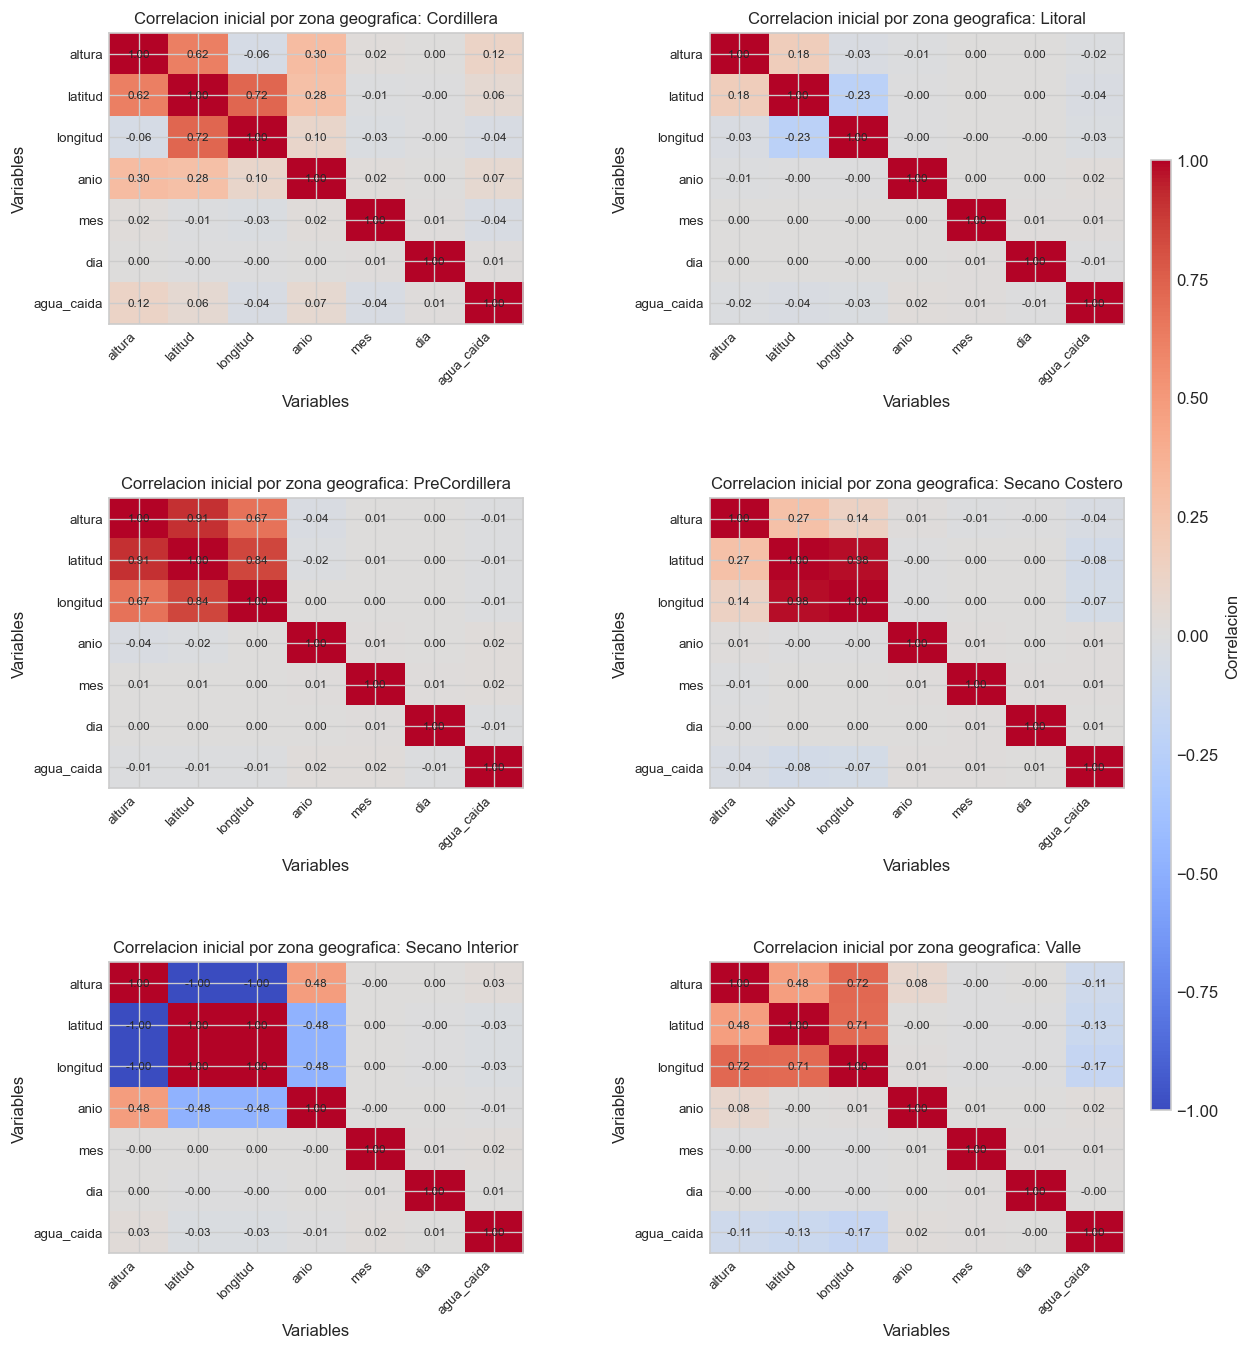

In [188]:
heatmap_df(
    corr_inicial,
    "Matriz de correlacion inicial",
    cmap="coolwarm",
    figsize=(8, 5),
    decimals=2,
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)

plot_group_heatmaps(
    corr_inicial_por_zona,
    "Correlacion inicial por zona geografica",
    cmap="coolwarm",
    decimals=2,
    ncols=2,
    base_figsize=(5.6, 4.4),
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)


**Analisis.** La matriz global sigue mostrando relaciones lineales debiles entre `agua_caida` y las variables numericas brutas, pero la lectura por `zona_geografica` agrega un matiz importante: la direccion y magnitud de algunas asociaciones cambia cuando se separa el territorio. Esto es esperable en Chile, porque `Litoral`, `Valle`, `PreCordillera` o `Cordillera` no responden al mismo regimen atmosferico ni a la misma topografia. Metodologicamente, esta desagregacion fortalece el analisis porque evita concluir que "no hay relacion" solo por haber mezclado espacios muy distintos dentro de una sola correlacion nacional.


La correlacion global sirve como punto de partida, pero puede ocultar diferencias territoriales importantes. Por eso se recalcula la matriz numerica separando el dataset por `macrozona`, `zona_geografica` y `zona_climatica`, manteniendo exactamente las mismas variables base. Asi se puede verificar si la asociacion entre altura, posicion y precipitaci?n cambia cuando se respeta la estructura espacial del pais.


In [189]:
columnas_corr_segmentada = ["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida"]

corr_por_macrozona = build_group_corr_dict(
    df_modelo, "macrozona", columnas_corr_segmentada, group_order=MACROZONE_ORDER, min_rows=100
)
corr_por_zona_geografica = build_group_corr_dict(
    df_modelo, "zona_geografica", columnas_corr_segmentada, group_order=ACTIVE_GEO_ORDER, min_rows=100
)
corr_por_zona_climatica = build_group_corr_dict(
    df_modelo, "zona_climatica", columnas_corr_segmentada, group_order=ACTIVE_CLIMATE_ORDER, min_rows=100
)


Antes de dibujar las matrices segmentadas conviene dejar una tabla que haga visible cuantas filas aporta cada subconjunto. Ese control de tamano es importante porque evita interpretar igual una macrozona muy representada y una categoria con menos soporte empirico.


In [190]:
resumen_segmentos_corr = pd.DataFrame(
    {
        "grupo": (
            [f"Macrozona: {grupo}" for grupo in corr_por_macrozona]
            + [f"Zona geografica: {grupo}" for grupo in corr_por_zona_geografica]
            + [f"Zona climatica: {grupo}" for grupo in corr_por_zona_climatica]
        ),
        "filas_utilizadas": (
            [int(df_modelo["macrozona"].eq(grupo).sum()) for grupo in corr_por_macrozona]
            + [int(df_modelo["zona_geografica"].eq(grupo).sum()) for grupo in corr_por_zona_geografica]
            + [int(df_modelo["zona_climatica"].eq(grupo).sum()) for grupo in corr_por_zona_climatica]
        ),
    }
)

display(resumen_segmentos_corr)


,grupo,filas_utilizadas
0,Macrozona: Norte,43541
1,Macrozona: Centro,67445
2,Macrozona: Sur,47106
3,Macrozona: Austral,29784
4,Zona geografica: Cordillera,7527
5,Zona geografica: Litoral,64838
6,Zona geografica: PreCordillera,19060
7,Zona geografica: Secano Costero,7277
8,Zona geografica: Secano Interior,2557
9,Zona geografica: Valle,86617


El resumen anterior deja trazabilidad sobre el tamano de cada grupo. De ese modo, las matrices no se interpretan como casos aislados, sino como patrones obtenidos sobre subconjuntos con respaldo suficiente de observaciones diarias.


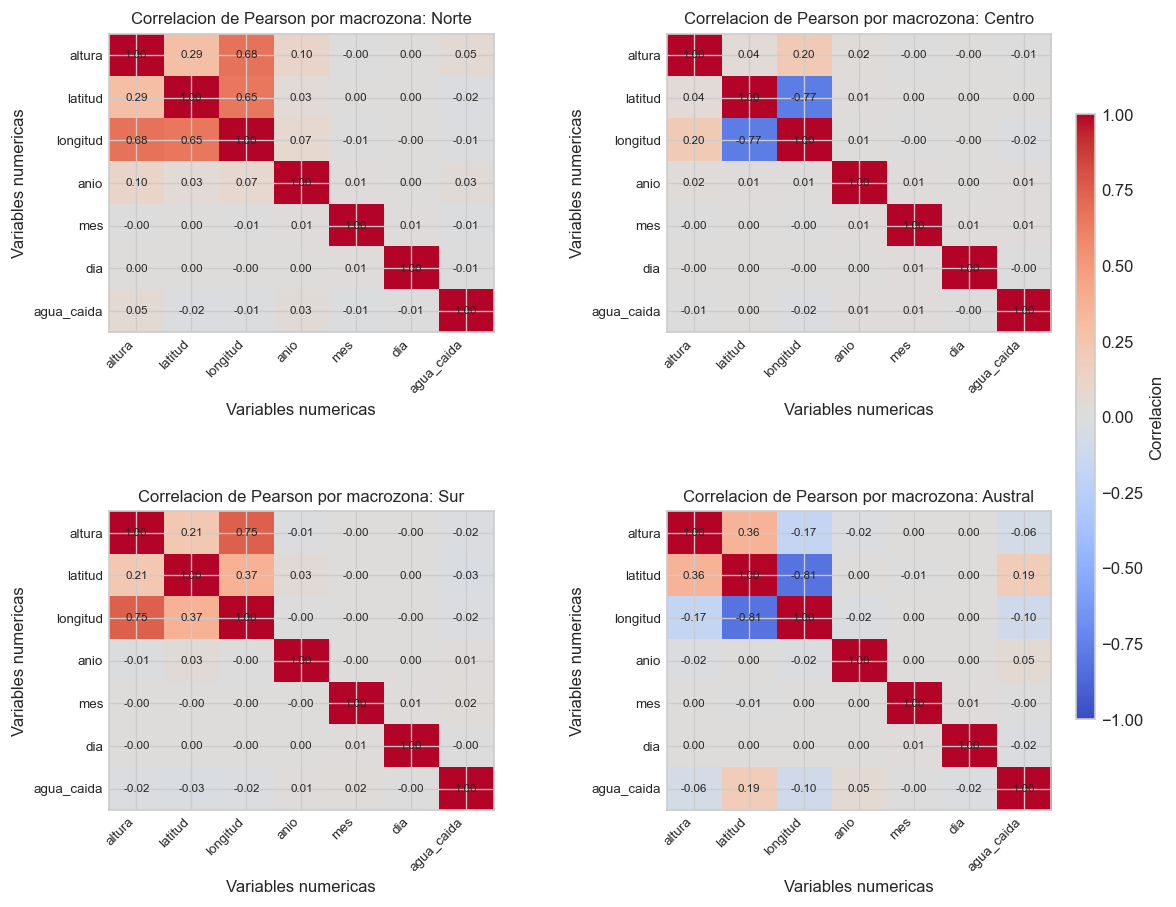

In [191]:
plot_group_heatmaps(
    corr_por_macrozona,
    "Correlacion de Pearson por macrozona",
    ncols=2,
    base_figsize=(5.2, 4.2),
    xlabel="Variables numericas",
    ylabel="Variables numericas",
    cbar_label="Correlacion"
)


La primera desagregacion se hace por `macrozona`, porque permite comparar grandes franjas del pais sin perder demasiada estabilidad estadistica. Es una buena escala intermedia entre la lectura totalmente nacional y el detalle territorial mas fino.


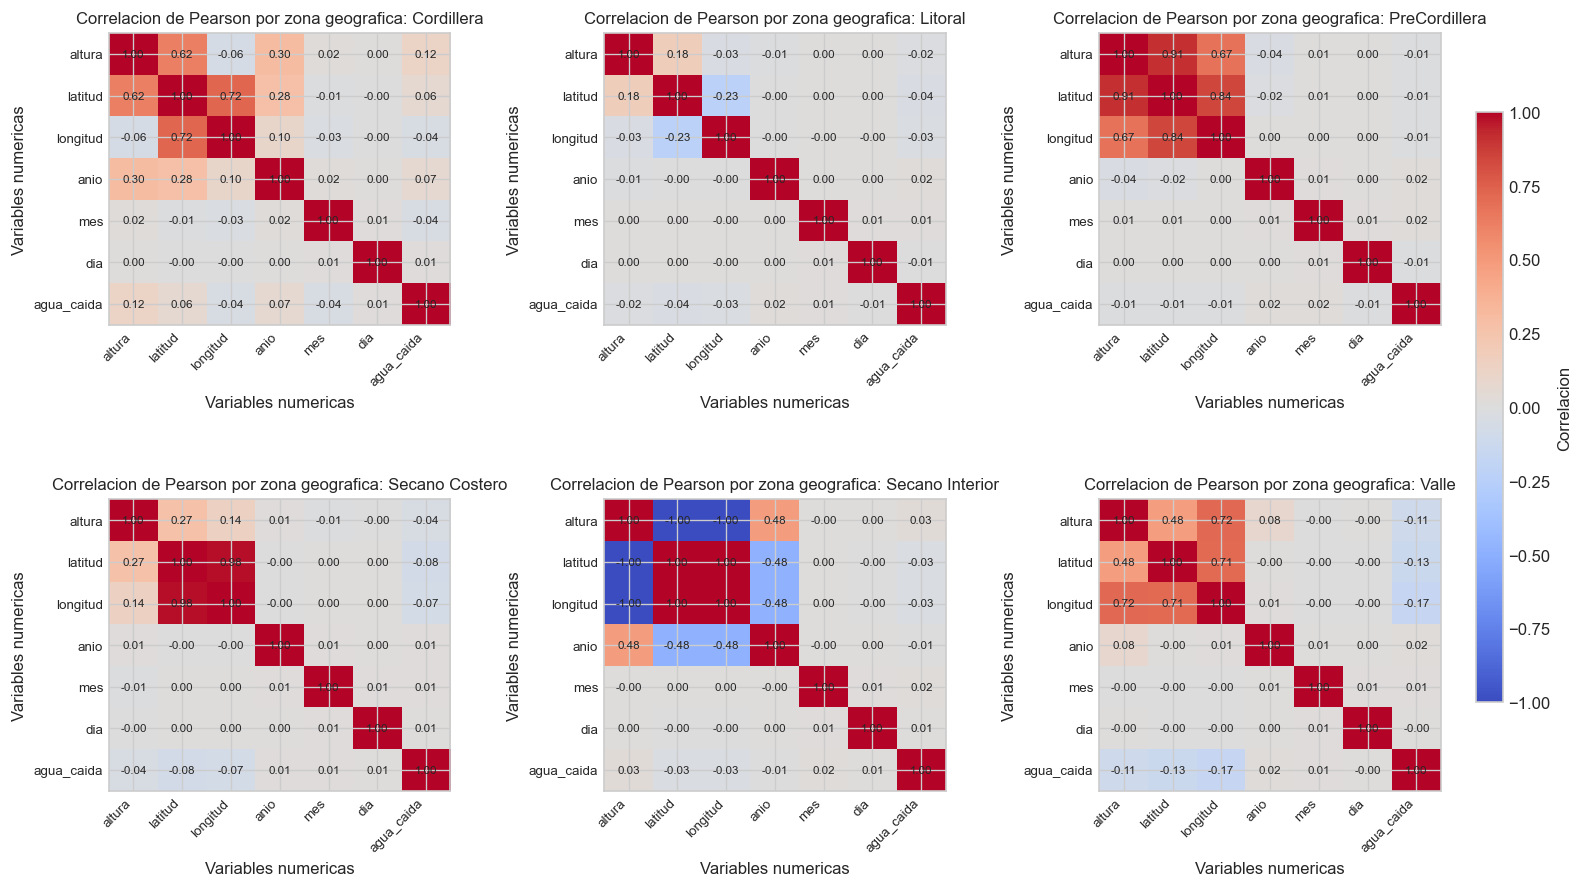

In [192]:
plot_group_heatmaps(
    corr_por_zona_geografica,
    "Correlacion de Pearson por zona geografica",
    ncols=3,
    base_figsize=(4.9, 4.1),
    xlabel="Variables numericas",
    ylabel="Variables numericas",
    cbar_label="Correlacion"
)


Luego la correlacion se revisa por `zona_geografica`. Aqui la idea es observar si el relieve y la posicion topografica modifican la relacion entre precipitaci?n y variables espaciales, algo esperable en un pais con costa, valle, cordillera y sectores de secano bien diferenciados.


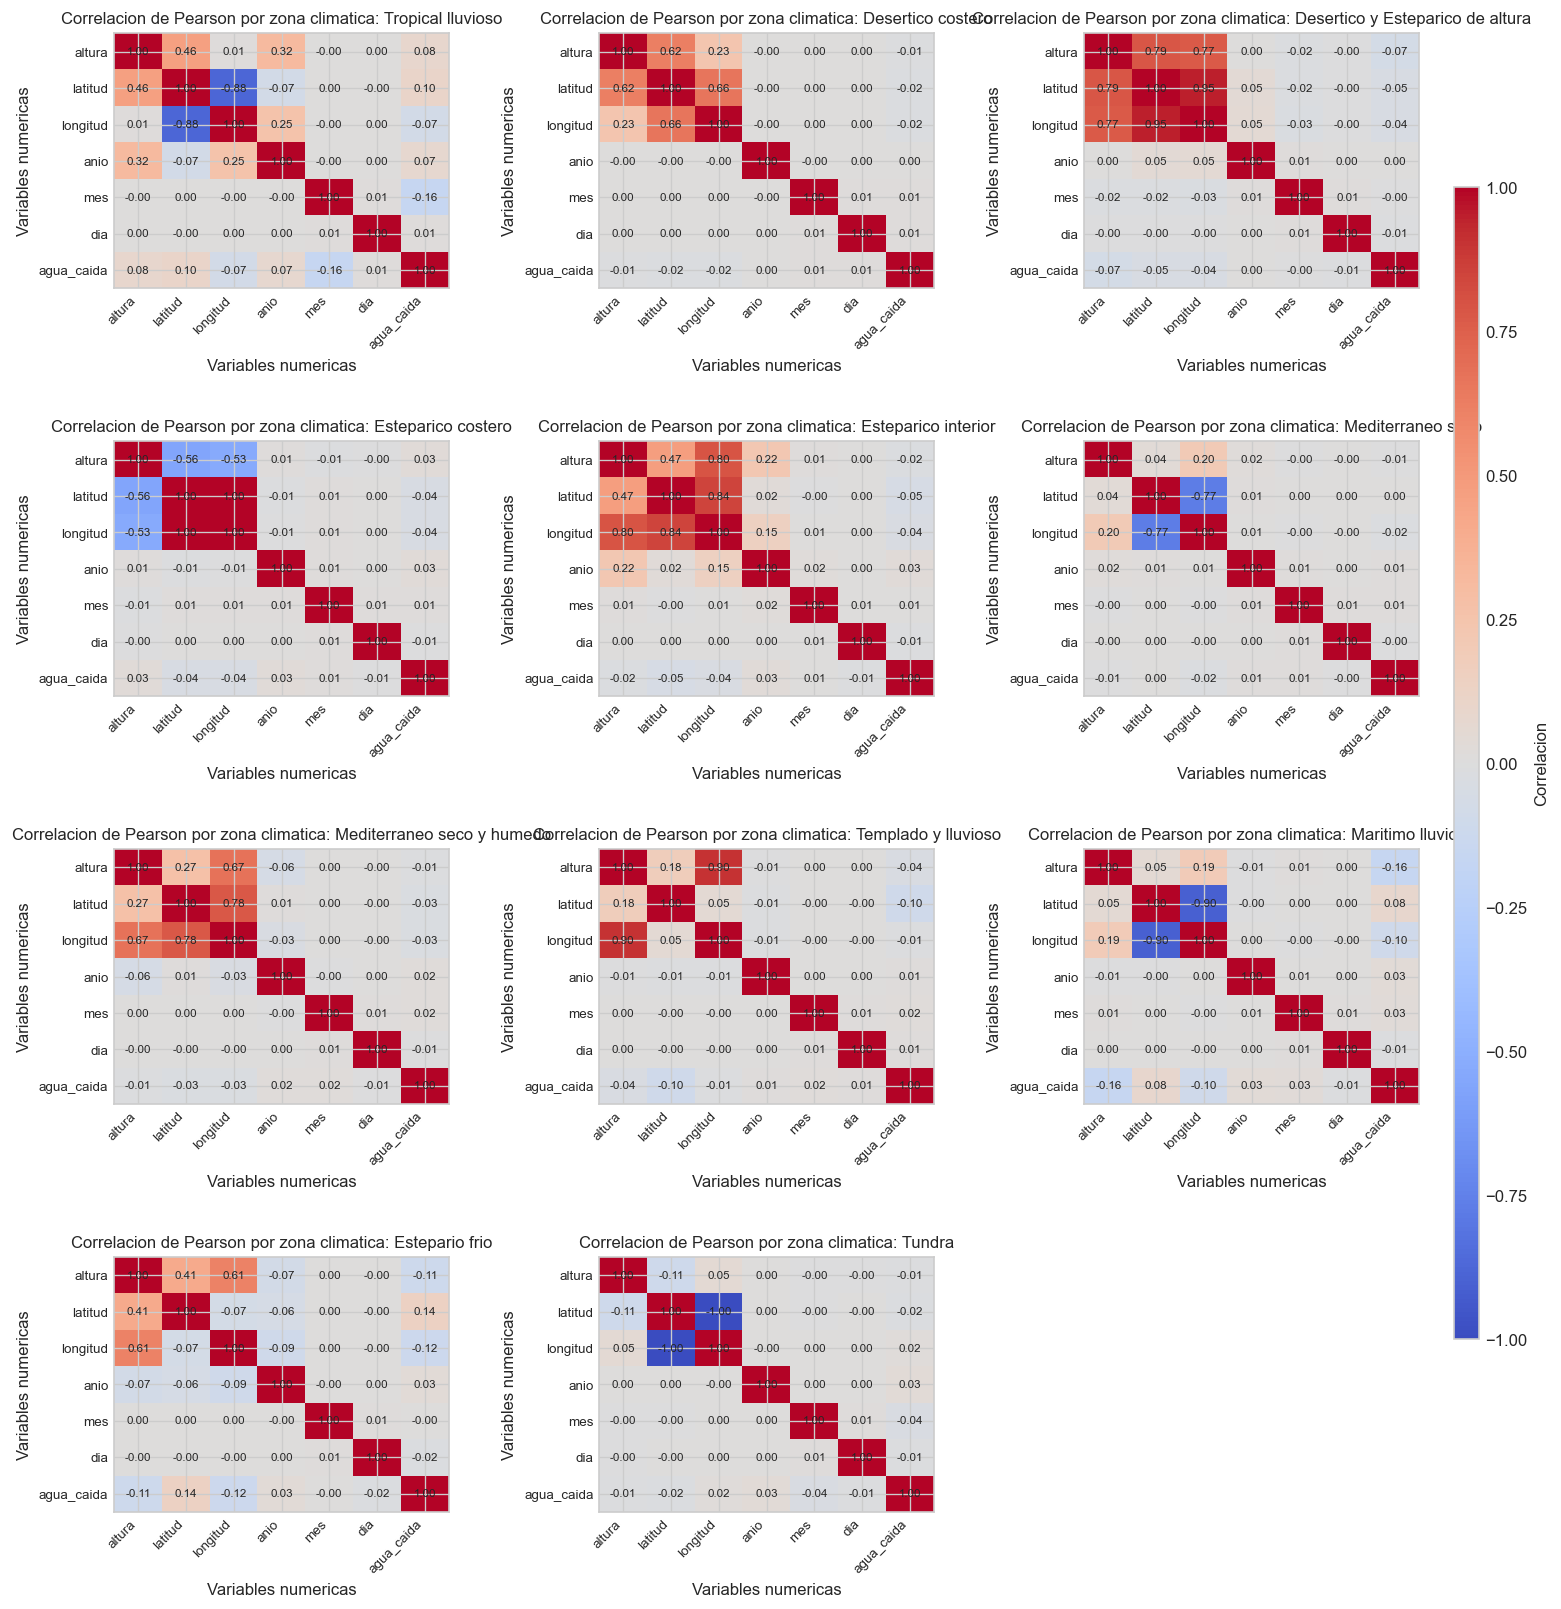

In [193]:
plot_group_heatmaps(
    corr_por_zona_climatica,
    "Correlacion de Pearson por zona climatica",
    ncols=3,
    base_figsize=(4.8, 4.0),
    xlabel="Variables numericas",
    ylabel="Variables numericas",
    cbar_label="Correlacion"
)


Finalmente, la segmentacion por `zona_climatica` permite ver si los regimenes hidrologicos agregados presentan estructuras distintas de correlacion. Esta lectura es especialmente util para conectar el analisis exploratorio con una clasificacion territorial mas interpretable para el informe.


**Analisis segmentado.** Estas matrices muestran que la correlacion no es completamente estable entre territorios. En algunas macrozonas la lluvia se relaciona mas con la latitud y la longitud, mientras que en otras gana peso la altura o la estacionalidad mensual. La lectura por `zona_geografica` y `zona_climatica` refuerza que no conviene defender una sola estructura lineal para todo el pais, porque el regimen pluviometrico cambia con bastante fuerza segun el contexto espacial.


Como complemento visual de las matrices de correlacion, se agregan tres graficos de dispersion globales. La idea no es reemplazar la lectura matricial, sino volver mas intuitivas algunas relaciones espaciales con `agua_caida_log`, usando colores para separar `zona_climatica`, `zona_geografica` y `macrozona`.


In [194]:
columnas_dispersion_global = [
    "latitud", "longitud", "altura", "agua_caida_log",
    "zona_climatica", "zona_geografica", "macrozona"
]

muestra_corr_visual = df_modelo[columnas_dispersion_global].dropna().copy()
if len(muestra_corr_visual) > 12000:
    muestra_corr_visual = muestra_corr_visual.sample(12000, random_state=42)

geo_palette = dict(
    zip(
        ACTIVE_GEO_ORDER,
        ["#0f766e", "#14b8a6", "#22c55e", "#84cc16", "#f59e0b", "#ef4444"][:len(ACTIVE_GEO_ORDER)],
    )
)

resumen_dispersion_global = pd.DataFrame(
    {
        "grafico": [
            "Latitud vs agua_caida_log por zona climatica",
            "Altura vs agua_caida_log por zona geografica",
            "Longitud vs agua_caida_log por macrozona",
        ],
        "correlacion_global": [
            round(df_modelo[["latitud", "agua_caida_log"]].corr().iloc[0, 1], 3),
            round(df_modelo[["altura", "agua_caida_log"]].corr().iloc[0, 1], 3),
            round(df_modelo[["longitud", "agua_caida_log"]].corr().iloc[0, 1], 3),
        ],
        "agrupacion_color": ["zona_climatica", "zona_geografica", "macrozona"],
        "muestra_usada": [len(muestra_corr_visual)] * 3,
    }
)

display(resumen_dispersion_global)


,grafico,correlacion_global,agrupacion_color,muestra_usada
0,Latitud vs agua_caida_log por zona climatica,-0.239,zona_climatica,12000
1,Altura vs agua_caida_log por zona geografica,-0.123,zona_geografica,12000
2,Longitud vs agua_caida_log por macrozona,-0.114,macrozona,12000


La tabla anterior deja explicito que estos dispersogramas no se eligieron al azar: cada panel usa una de las variables espaciales con mayor relacion global con `agua_caida_log`. Ademas, se trabaja con una muestra grande pero controlada para que la figura siga siendo legible y no se convierta en una nube opaca de puntos.


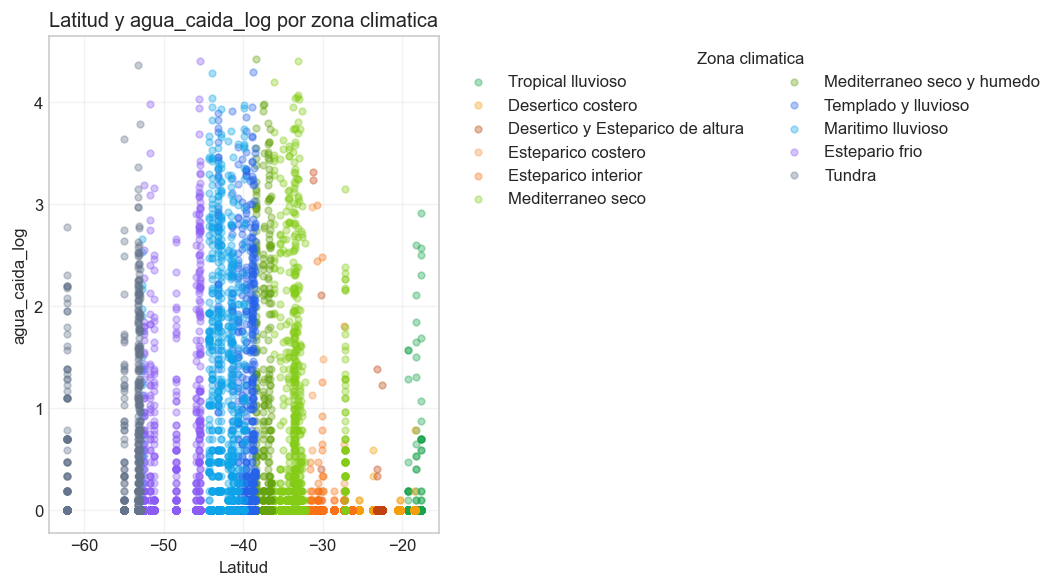

In [195]:
fig, ax = plt.subplots(figsize=(9, 5))

for zona in ACTIVE_CLIMATE_ORDER:
    subset = muestra_corr_visual.loc[muestra_corr_visual["zona_climatica"] == zona]
    if not subset.empty:
        ax.scatter(
            subset["latitud"],
            subset["agua_caida_log"],
            s=16,
            alpha=0.35,
            color=CLIMATE_COLORS.get(zona, "#94a3b8"),
            label=zona,
        )

ax.set_title("Latitud y agua_caida_log por zona climatica")
ax.set_xlabel("Latitud")
ax.set_ylabel("agua_caida_log")
ax.grid(alpha=0.25)
ax.legend(title="Zona climatica", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


El primer dispersograma usa `latitud` como eje horizontal y colorea por `zona_climatica`. Asi se puede ver si la gradiente norte-sur mantiene una forma similar dentro de cada regimen o si la dispersion cambia claramente entre climas.


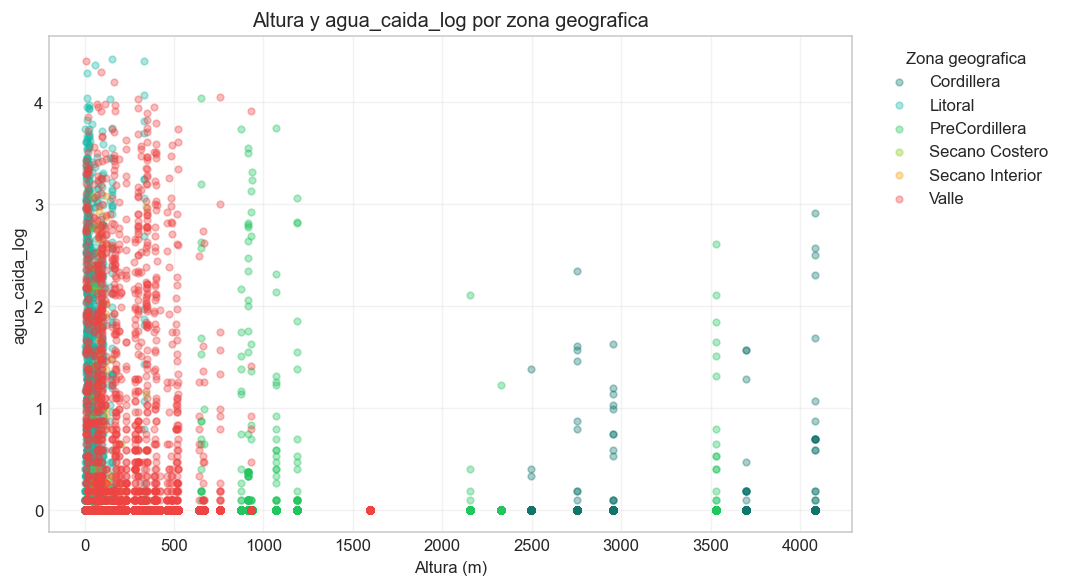

In [196]:
fig, ax = plt.subplots(figsize=(9, 5))

for zona_geo in ACTIVE_GEO_ORDER:
    subset = muestra_corr_visual.loc[muestra_corr_visual["zona_geografica"] == zona_geo]
    if not subset.empty:
        ax.scatter(
            subset["altura"],
            subset["agua_caida_log"],
            s=16,
            alpha=0.35,
            color=geo_palette.get(zona_geo, "#94a3b8"),
            label=zona_geo,
        )

ax.set_title("Altura y agua_caida_log por zona geografica")
ax.set_xlabel("Altura (m)")
ax.set_ylabel("agua_caida_log")
ax.grid(alpha=0.25)
ax.legend(title="Zona geografica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


El segundo panel cambia el foco hacia `altura` y `zona_geografica`. Con esto se busca ver si el relieve se asocia de manera parecida con `agua_caida_log` en litoral, valle, cordillera y demas posiciones territoriales.


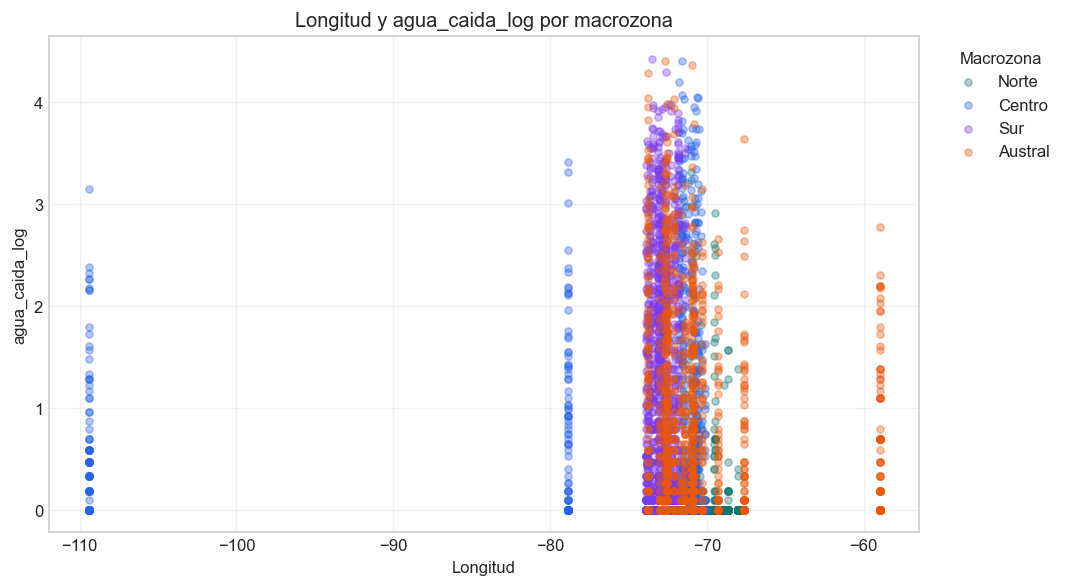

In [197]:
fig, ax = plt.subplots(figsize=(9, 5))

for macrozona in [mz for mz in MACROZONE_ORDER if mz in muestra_corr_visual["macrozona"].unique()]:
    subset = muestra_corr_visual.loc[muestra_corr_visual["macrozona"] == macrozona]
    if not subset.empty:
        ax.scatter(
            subset["longitud"],
            subset["agua_caida_log"],
            s=18,
            alpha=0.35,
            color=MACROZONE_COLORS.get(macrozona, "#94a3b8"),
            label=macrozona,
        )

ax.set_title("Longitud y agua_caida_log por macrozona")
ax.set_xlabel("Longitud")
ax.set_ylabel("agua_caida_log")
ax.grid(alpha=0.25)
ax.legend(title="Macrozona", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


El tercer dispersograma toma `longitud` y colorea por `macrozona`, cerrando la lectura visual global con una agregacion territorial mas amplia. Juntos, los tres paneles traducen la correlacion a una forma menos abstracta y mas facil de explicar oralmente.


**Lectura visual global.** Estos tres dispersogramas complementan bien a las matrices porque traducen correlaciones debiles o moderadas en una forma mas intuitiva. El primer panel deja ver que la gradiente latitudinal no se distribuye igual entre zonas climaticas; el segundo muestra como la altura se combina con `zona_geografica`; y el tercero permite ver que la posicion longitudinal tampoco se reparte de forma identica entre macrozonas. En conjunto, la lectura refuerza que la precipitacion diaria no responde a un solo patron nacional, sino a una mezcla de estructura espacial, relieve y agrupacion territorial.


### 2.7 Patrones/comportamientos detectados


Mas alla de la correlacion lineal, el entendimiento de los datos exige observar patrones concretos en el tiempo y en el espacio. En esta subseccion se priorizan recuentos de registros y dias con lluvia, combinando tablas, barras y heatmaps para mostrar con mayor claridad como se distribuyen los eventos entre meses, anos, macrozonas, zonas climaticas y estaciones.


In [198]:
lluvia_mensual = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby("mes")
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        maxima_lluvia=("agua_caida", "max"),
    )
    .astype({"registros": int, "dias_con_lluvia": int})
)

display(lluvia_mensual)


,registros,dias_con_lluvia,maxima_lluvia
mes,,,
1,16027,2486,72.599998
2,14583,2187,66.000000
3,16027,3355,80.400002
4,15498,4600,136.399994
5,15996,5551,126.800003
6,15480,6211,145.199997
7,15996,5644,114.300003
8,15944,5641,150.199997
9,15420,4456,117.199997


El resumen mensual ahora se centra en cuantas observaciones existen y en cuantas de ellas hubo lluvia efectiva. Esto ayuda a separar disponibilidad de datos e intensidad maxima, en vez de resumir todo en una sola media.


In [199]:
lluvia_anual = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby("anio")
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        maxima_lluvia=("agua_caida", "max"),
    )
    .astype({"registros": int, "dias_con_lluvia": int})
)

display(lluvia_anual)


,registros,dias_con_lluvia,maxima_lluvia
anio,,,
2021,35606,8849,126.800003
2022,35735,9378,136.399994
2023,38325,9763,150.199997
2024,39162,10303,98.599998
2025,39048,10404,3574.300049


Aqui se observa la dimension temporal agregada con una logica mas concreta: cantidad de registros, cantidad de dias con lluvia y maximo diario observado. Asi se evita interpretar estacionalidad solo desde el promedio, que en precipitacion suele ocultar mucha dispersion.


In [200]:
recuento_clima_macro_mes = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby(["mes", "zona_climatica", "macrozona"])
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        estaciones=("nombre_estacion", "nunique"),
    )
    .reset_index()
)

display(recuento_clima_macro_mes.head(20))


,mes,zona_climatica,macrozona,registros,dias_con_lluvia,estaciones
0,1,Desertico costero,Norte,1240,7,8
1,1,Desertico y Esteparico de altura,Norte,589,6,4
2,1,Esteparico costero,Norte,465,9,3
3,1,Esteparico interior,Norte,1085,1,8
4,1,Estepario frio,Austral,1023,454,7
5,1,Maritimo lluvioso,Austral,434,254,3
6,1,Maritimo lluvioso,Sur,1085,387,7
7,1,Mediterraneo seco,Centro,5766,266,39
8,1,Mediterraneo seco y humedo,Sur,1116,76,8
9,1,Templado y lluvioso,Sur,1798,272,12


Despues se cruza la temporalidad con la clasificacion territorial. Este bloque deja listo el recuento de dias con lluvia por mes, `zona_climatica` y `macrozona`, para que el grafico muestre datos observados y no solo intensidades promedio.


In [201]:
top_estaciones = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby("nombre_estacion")
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        maxima_lluvia=("agua_caida", "max"),
        region=("nombre_region", "first"),
        zona_geografica=("zona_geografica", "first"),
        zona_climatica=("zona_climatica", "first"),
        macrozona=("macrozona", "first"),
    )
    .sort_values(["dias_con_lluvia", "registros"], ascending=False)
)

display(top_estaciones.head(12))


,registros,dias_con_lluvia,maxima_lluvia,region,zona_geografica,zona_climatica,macrozona
nombre_estacion,,,,,,,
Puerto Varas ESSAL,1826,1262,59.299999,De Los Lagos,Litoral,Maritimo lluvioso,Sur
Melinka Ad.,1826,1242,120.000000,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Litoral,Maritimo lluvioso,Austral
Nueva ChaitÃ©n,1826,1206,103.400002,De Los Lagos,Litoral,Maritimo lluvioso,Sur
Puerto AysÃ©n Ad.,1826,1205,80.300003,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Valle,Estepario frio,Austral
QuellÃ³n Ad.,1826,1167,72.199997,De Los Lagos,Litoral,Maritimo lluvioso,Sur
Cisnes Puyuhuapi,1307,1118,93.800003,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Litoral,Maritimo lluvioso,Austral
Escuela Alberto Hurtado,1817,1062,77.300003,Magallanes y de la AntÃ¡rtica Chilena,Litoral,Tundra,Austral
"Villa O""Higgins subcomisarÃ­a",1826,1041,94.199997,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Valle,Estepario frio,Austral
Maquehue-UFRO,1826,1018,94.400002,De La AraucanÃ­a,Valle,Templado y lluvioso,Sur


Con este segundo bloque la mirada se desplaza hacia el territorio fino. En vez de ordenar las estaciones por promedio, se prioriza cuantas observaciones y cuantos dias con lluvia aporta cada una, lo que hace mas transparente la comparacion entre lugares con distinta cobertura temporal.


In [202]:
patron_clima_mes = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .pivot_table(
        index="mes",
        columns="zona_climatica",
        values="tiene_lluvia",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=ACTIVE_CLIMATE_ORDER, fill_value=0)
    .astype(int)
)

display(patron_clima_mes)


zona_climatica,Tropical lluvioso,Desertico costero,Desertico y Esteparico de altura,Esteparico costero,Esteparico interior,Mediterraneo seco,Mediterraneo seco y humedo,Templado y lluvioso,Maritimo lluvioso,Estepario frio,Tundra
mes,,,,,,,,,,,
1,191,7,6,9,1,266,76,272,641,454,563
2,157,10,12,9,0,282,69,257,537,342,512
3,150,1,8,9,8,355,187,675,891,480,591
4,17,6,5,18,46,820,496,1076,1044,552,520
5,3,5,13,24,71,1427,600,1227,1091,600,490
6,2,6,24,63,152,1888,678,1286,1065,576,471
7,0,8,22,54,134,1430,614,1274,980,651,477
8,0,7,25,57,147,1754,575,1077,930,576,493
9,0,8,5,28,26,1083,487,948,968,517,386


La tabla mensual por `zona_climatica` deja cuantificados los dias con lluvia, pero todavia en formato resumido. El siguiente bloque convierte esa informacion en un panel temporal mas legible: un grafico mensual general y una desagregacion por `macrozona`.


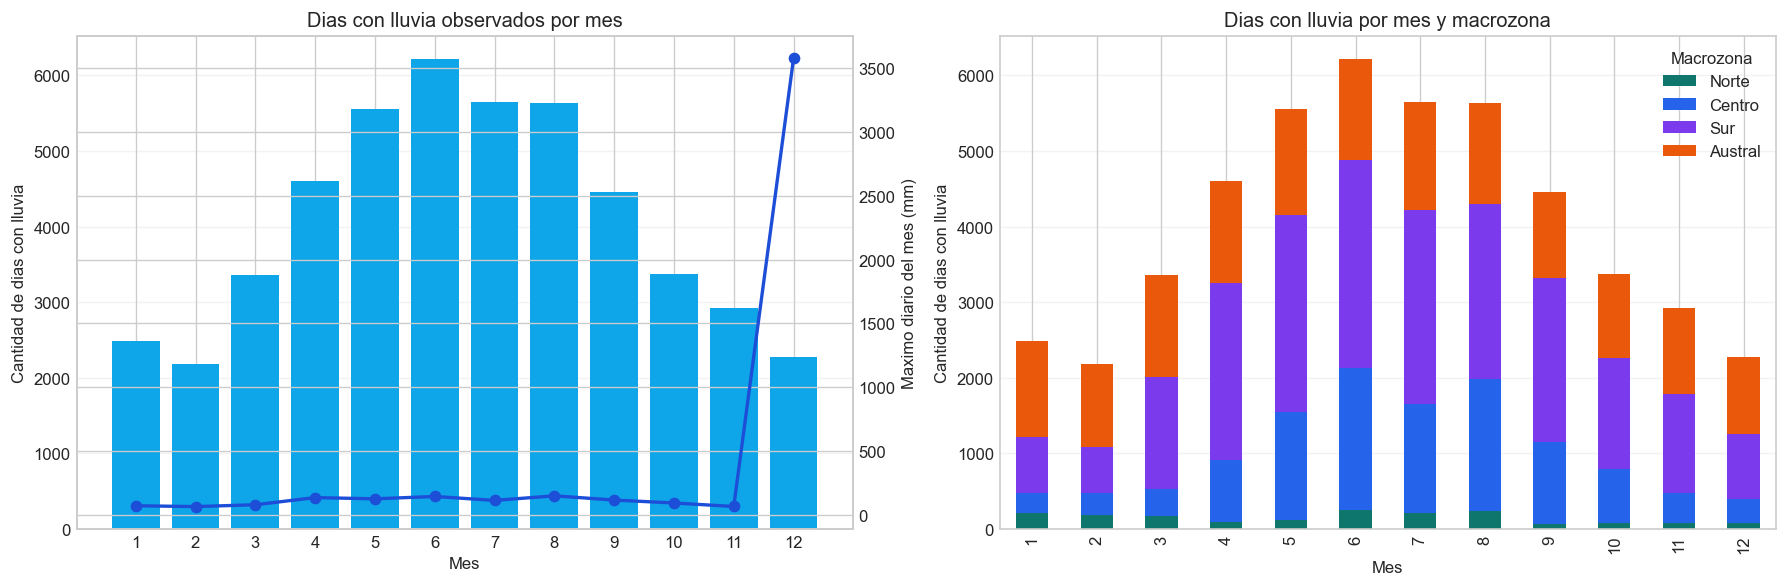

In [203]:
mensual_macrozona = (
    recuento_clima_macro_mes.groupby(["mes", "macrozona"])["dias_con_lluvia"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=[mz for mz in MACROZONE_ORDER if mz in recuento_clima_macro_mes["macrozona"].unique()], fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(lluvia_mensual.index, lluvia_mensual["dias_con_lluvia"], color="#0ea5e9")
axes[0].set_title("Dias con lluvia observados por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Cantidad de dias con lluvia")
axes[0].set_xticks(range(1, 13))
axes[0].grid(axis="y", alpha=0.25)

ax0b = axes[0].twinx()
ax0b.plot(
    lluvia_mensual.index,
    lluvia_mensual["maxima_lluvia"],
    color="#1d4ed8",
    marker="o",
    linewidth=2,
)
ax0b.set_ylabel("Maximo diario del mes (mm)")

mensual_macrozona.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[MACROZONE_COLORS.get(col, "#94a3b8") for col in mensual_macrozona.columns],
)
axes[1].set_title("Dias con lluvia por mes y macrozona")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Cantidad de dias con lluvia")
axes[1].legend(title="Macrozona")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


Las visualizaciones temporales se simplifican para que la lectura sea mas directa. El primer panel muestra la estacionalidad mensual de los dias con lluvia y la complementa con el maximo diario del mes. El segundo panel reparte esos dias entre macrozonas, de modo que se vea de inmediato en que tramo del pais se concentra el aporte mensual del fenomeno.

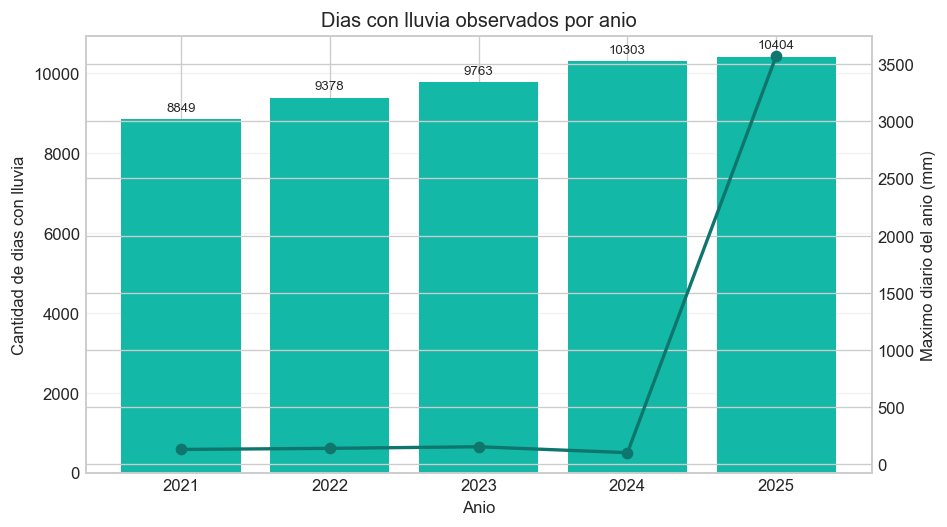

In [204]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(lluvia_anual.index.astype(str), lluvia_anual["dias_con_lluvia"], color="#14b8a6")
ax.set_title("Dias con lluvia observados por anio")
ax.set_xlabel("Anio")
ax.set_ylabel("Cantidad de dias con lluvia")
ax.grid(axis="y", alpha=0.25)

for anio, valor in lluvia_anual["dias_con_lluvia"].items():
    ax.text(str(anio), valor + lluvia_anual["dias_con_lluvia"].max() * 0.02, int(valor), ha="center", fontsize=8)

ax2 = ax.twinx()
ax2.plot(
    lluvia_anual.index.astype(str),
    lluvia_anual["maxima_lluvia"],
    color="#0f766e",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Maximo diario del anio (mm)")

plt.tight_layout()
plt.show()


El resumen anual complementa la lectura mensual y sirve para verificar si hay anos con mas eventos o con maximos diarios especialmente altos. Despues de esa vista agregada, el heatmap vuelve a la distribucion por `zona_climatica` y mes.


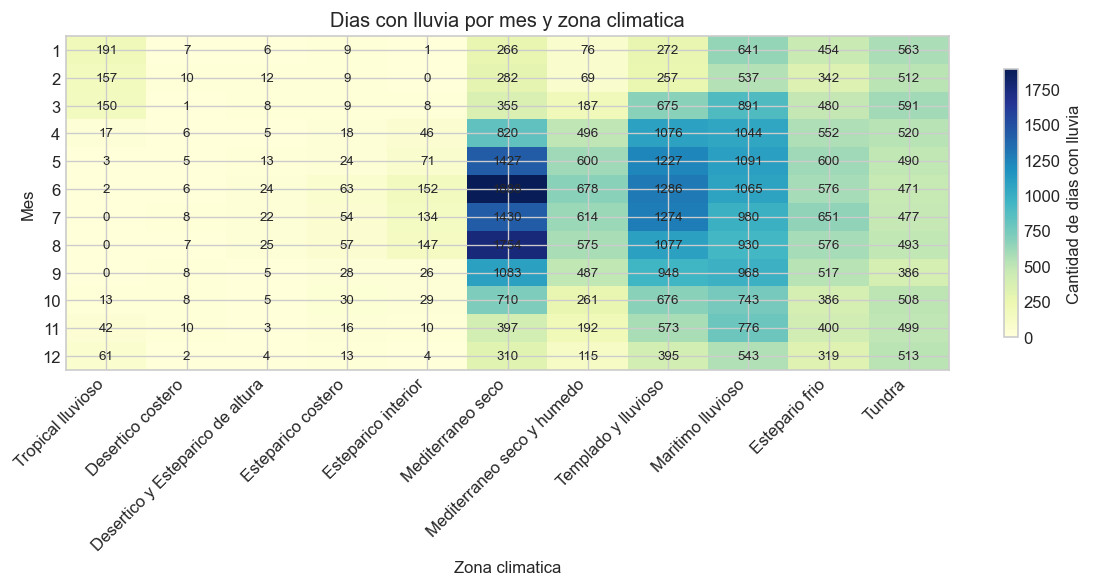

In [205]:
heatmap_df(
    patron_clima_mes,
    "Dias con lluvia por mes y zona climatica",
    cmap="YlGnBu",
    figsize=(10, 5),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Mes",
    cbar_label="Cantidad de dias con lluvia",
)


In [206]:
df_graficos_geo_clima = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby(["zona_geografica", "zona_climatica", "macrozona"], observed=False)
    .agg(
        estaciones=("nombre_estacion", "nunique"),
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        frecuencia_lluvia_pct=("tiene_lluvia", lambda s: round(s.mean() * 100, 1)),
        mediana_agua_caida=("agua_caida", "median"),
    )
    .reset_index()
    .sort_values(["dias_con_lluvia", "registros"], ascending=False)
)

perfil_geo_clima = df_graficos_geo_clima.copy()
display(perfil_geo_clima)


,zona_geografica,zona_climatica,macrozona,estaciones,registros,dias_con_lluvia,frecuencia_lluvia_pct,mediana_agua_caida
21,Valle,Templado y lluvioso,Sur,11,19351,9092,47.0,0.00
5,Litoral,Maritimo lluvioso,Sur,7,12782,7135,55.8,0.10
8,Litoral,Tundra,Austral,7,12773,6023,47.2,0.00
18,Valle,Estepario frio,Austral,7,12052,5853,48.6,0.00
19,Valle,Mediterraneo seco,Centro,21,35237,4881,13.9,0.00
6,Litoral,Mediterraneo seco,Centro,8,14608,3676,25.2,0.00
4,Litoral,Maritimo lluvioso,Austral,3,4959,3074,62.0,0.45
20,Valle,Mediterraneo seco y humedo,Sur,4,7304,2062,28.2,0.00
7,Litoral,Mediterraneo seco y humedo,Sur,3,5112,2023,39.6,0.00
10,PreCordillera,Mediterraneo seco,Centro,6,10296,1168,11.3,0.00


Este cruce territorial funciona como una lectura de cobertura y ocurrencia. Para graficarlo sin confundir combinaciones inexistentes con valores reales iguales a cero, se construye un dataframe especifico de visualizacion llamado `df_graficos_geo_clima`. Desde esa tabla resumen se levantan los heatmaps, dejando en blanco las combinaciones `zona_geografica` x `zona_climatica` que no aparecen en la base.

In [207]:
conteo_estaciones_geo_clima = df_graficos_geo_clima.copy()

estaciones_geo_clima = (
    conteo_estaciones_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="estaciones",
        aggfunc="sum",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

precipitacion_geo_clima = (
    conteo_estaciones_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="dias_con_lluvia",
        aggfunc="sum",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

display(estaciones_geo_clima)
display(precipitacion_geo_clima)


zona_climatica,Tropical lluvioso,Desertico costero,Desertico y Esteparico de altura,Esteparico costero,Esteparico interior,Mediterraneo seco,Mediterraneo seco y humedo,Templado y lluvioso,Maritimo lluvioso,Estepario frio,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,2.0,NaN,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,8.0,NaN,NaN,NaN,8.0,3.0,NaN,10.0,NaN,7.0
PreCordillera,1.0,NaN,3.0,NaN,NaN,6.0,NaN,1.0,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,3.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,8.0,21.0,4.0,11.0,NaN,7.0,NaN


zona_climatica,Tropical lluvioso,Desertico costero,Desertico y Esteparico de altura,Esteparico costero,Esteparico interior,Mediterraneo seco,Mediterraneo seco y humedo,Templado y lluvioso,Maritimo lluvioso,Estepario frio,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,415.0,NaN,36.0,NaN,NaN,371.0,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,78.0,NaN,NaN,NaN,3676.0,2023.0,NaN,10209.0,NaN,6023.0
PreCordillera,221.0,NaN,96.0,NaN,NaN,1168.0,NaN,644.0,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,330.0,NaN,250.0,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,376.0,265.0,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,628.0,4881.0,2062.0,9092.0,NaN,5853.0,NaN


Con `df_graficos_geo_clima` ya construido, primero se levantan dos matrices de cobertura: cantidad de estaciones y cantidad de dias con lluvia. Esto permite separar de manera ordenada el respaldo territorial del volumen de eventos antes de pasar a frecuencia e intensidad tipica.


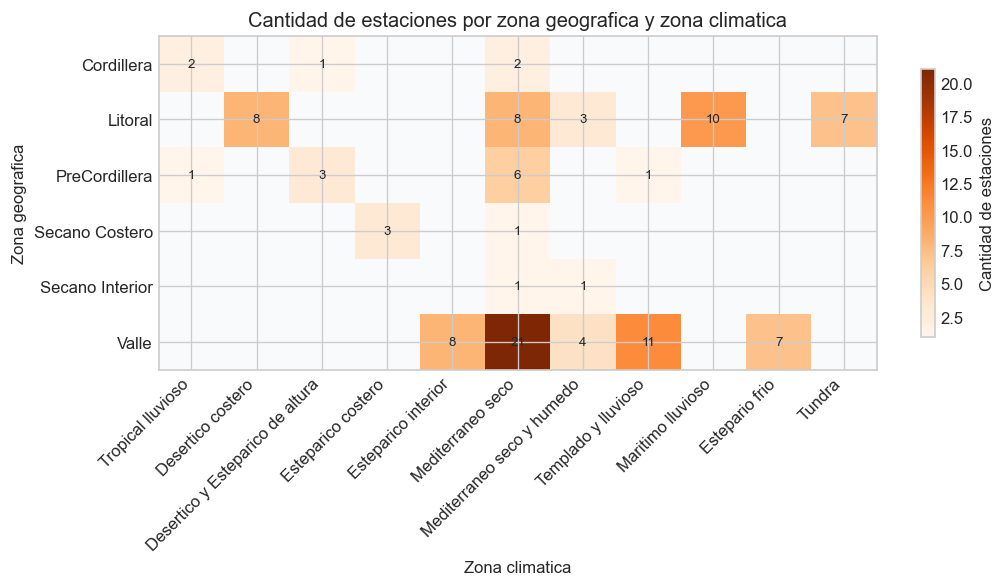

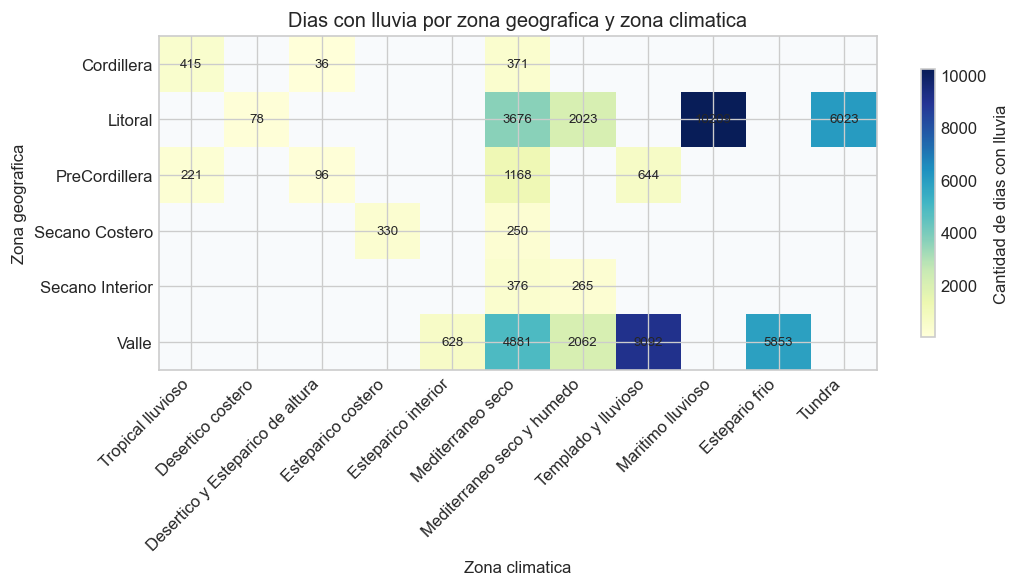

In [208]:
heatmap_df(
    estaciones_geo_clima,
    "Cantidad de estaciones por zona geografica y zona climatica",
    cmap="Oranges",
    figsize=(9, 5),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Cantidad de estaciones",
)

heatmap_df(
    precipitacion_geo_clima,
    "Dias con lluvia por zona geografica y zona climatica",
    cmap="YlGnBu",
    figsize=(9, 5),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Cantidad de dias con lluvia",
)


El conteo de dias con lluvia muestra cobertura, pero no separa intensidad tipica de probabilidad relativa. Para complementar esa lectura, se reutiliza `df_graficos_geo_clima` y se construyen matrices de frecuencia y mediana. En estos graficos, las celdas vacias representan combinaciones territoriales no observadas en la base, no faltantes pendientes de imputacion.

In [209]:
frecuencia_geo_clima_pct = (
    df_graficos_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="frecuencia_lluvia_pct",
        aggfunc="mean",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

mediana_geo_clima = (
    df_graficos_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="mediana_agua_caida",
        aggfunc="mean",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

display(frecuencia_geo_clima_pct)
display(mediana_geo_clima)


zona_climatica,Tropical lluvioso,Desertico costero,Desertico y Esteparico de altura,Esteparico costero,Esteparico interior,Mediterraneo seco,Mediterraneo seco y humedo,Templado y lluvioso,Maritimo lluvioso,Estepario frio,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,18.9,NaN,2.1,NaN,NaN,10.2,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,0.5,NaN,NaN,NaN,25.2,39.6,NaN,58.9,NaN,47.2
PreCordillera,12.1,NaN,1.9,NaN,NaN,11.3,NaN,35.3,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,6.1,NaN,13.7,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,20.6,36.3,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,5.0,13.9,28.2,47.0,NaN,48.6,NaN


zona_climatica,Tropical lluvioso,Desertico costero,Desertico y Esteparico de altura,Esteparico costero,Esteparico interior,Mediterraneo seco,Mediterraneo seco y humedo,Templado y lluvioso,Maritimo lluvioso,Estepario frio,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,0.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.275,NaN,0.0
PreCordillera,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN


A partir de la misma base de visualizacion, ahora se calculan dos medidas mas interpretativas: la frecuencia de lluvia y la mediana de `agua_caida`. Los heatmaps siguientes muestran esas dos dimensiones por separado para no confundir ocurrencia con intensidad central.


Estas tablas ayudan a separar dos dimensiones que suelen confundirse: una combinacion territorial puede acumular muchos eventos por volumen de registros, pero no necesariamente tener una frecuencia alta; del mismo modo, una mediana baja puede convivir con algunos extremos intensos. Ademas, las celdas en blanco muestran de forma explicita que ciertas combinaciones no existen en el dataset, evitando interpretarlas como ceros reales.

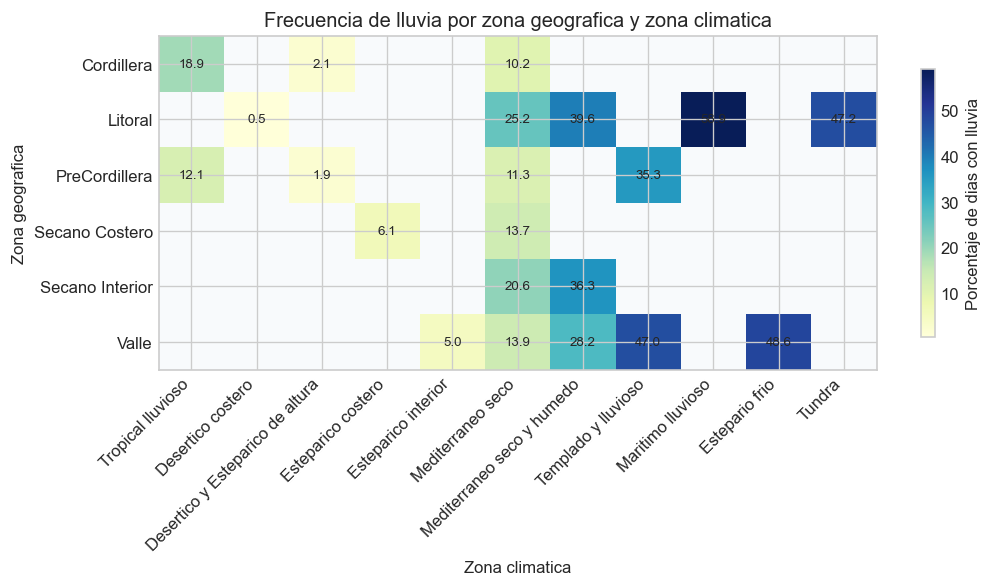

In [210]:
heatmap_df(
    frecuencia_geo_clima_pct,
    "Frecuencia de lluvia por zona geografica y zona climatica",
    cmap="YlGnBu",
    figsize=(9, 5),
    decimals=1,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Porcentaje de dias con lluvia"
)


El primer heatmap de este bloque muestra la frecuencia relativa de lluvia. A continuacion, la mediana complementa esa lectura y permite distinguir si una combinacion territorial tiende a registrar lluvias tipicas mas altas o solo mas frecuentes.


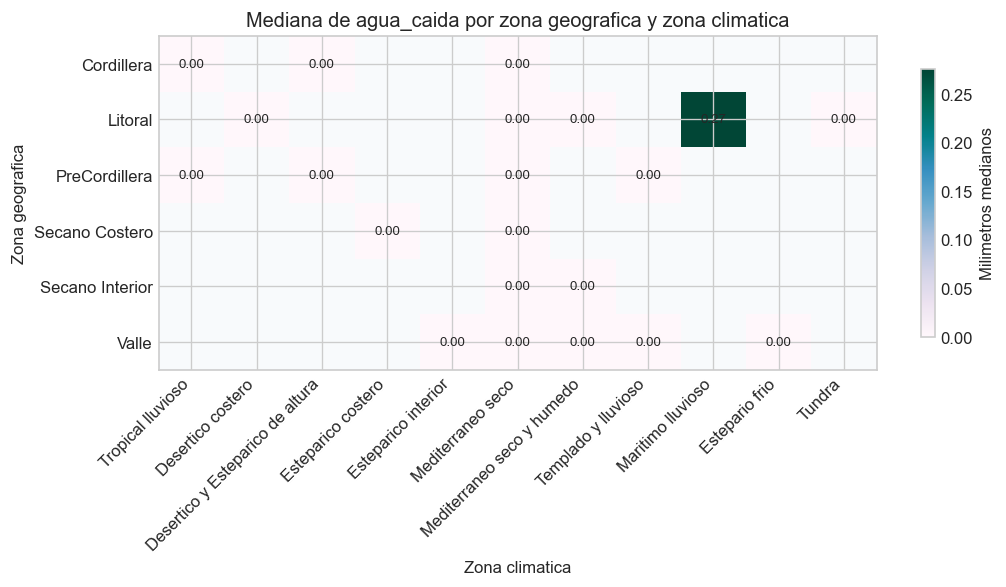

In [211]:
heatmap_df(
    mediana_geo_clima,
    "Mediana de agua_caida por zona geografica y zona climatica",
    cmap="PuBuGn",
    figsize=(9, 5),
    decimals=2,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Milimetros medianos"
)


**Analisis.** El patron espacial se entiende mejor cuando se mira como recuento y no solo como promedio. La dispersion territorial deja ver donde se concentran realmente las observaciones con lluvia y que combinaciones de `zona_geografica`, `zona_climatica` y `macrozona` tienen mayor respaldo empirico. El heatmap de dias con lluvia muestra el volumen de eventos acumulados, mientras que los heatmaps de frecuencia y mediana separan mejor la probabilidad de ocurrencia y la intensidad central del fenomeno. Que algunas celdas queden en blanco es metodologicamente correcto: no indican nulos sin tratar, sino cruces territoriales no observados en la muestra disponible.

### 2.8 Nuevas variables a partir del analisis


A partir de los patrones detectados, resulta conveniente construir variables que representen mejor la naturaleza ciclica del tiempo y la agrupacion territorial de las estaciones. La finalidad de estas nuevas variables no es aumentar artificialmente la dimensionalidad, sino incorporar estructuras que las columnas originales no capturan de forma directa.


In [212]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

estaciones = {
    12: "Verano", 1: "Verano", 2: "Verano",
    3: "Otono", 4: "Otono", 5: "Otono",
    6: "Invierno", 7: "Invierno", 8: "Invierno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}

df_features = df_modelo.copy()
df_features["estacion_anual"] = df_features["mes"].map(estaciones)
df_features["estacion_anual"] = pd.Categorical(
    df_features["estacion_anual"],
    categories=orden_estaciones,
    ordered=True,
)
df_features["dia_del_anio"] = df_features["fecha"].dt.dayofyear

display(df_features[["fecha", "mes", "estacion_anual", "dia_del_anio"]].head(12))


,fecha,mes,estacion_anual,dia_del_anio
0,2023-01-01,1,Verano,1
1,2023-01-02,1,Verano,2
2,2023-01-03,1,Verano,3
3,2023-01-04,1,Verano,4
4,2023-01-05,1,Verano,5
5,2023-01-06,1,Verano,6
6,2023-01-07,1,Verano,7
7,2023-01-08,1,Verano,8
8,2023-01-09,1,Verano,9
9,2023-01-10,1,Verano,10


El primer grupo de variables derivadas resume la posicion del registro dentro del calendario. Esto permite pasar de un tiempo crudo a una representacion mas interpretativa y cercana a la logica meteorologica.


In [213]:
df_features["mes_sin"] = np.sin(2 * np.pi * df_features["mes"] / 12)
df_features["mes_cos"] = np.cos(2 * np.pi * df_features["mes"] / 12)
df_features["dia_sin"] = np.sin(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["dia_cos"] = np.cos(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["lluvia_evento"] = (df_features["agua_caida"] > 0).astype(int)

display(
    df_features[
        [
            "fecha", "mes_sin", "mes_cos", "dia_sin", "dia_cos",
            "zona_climatica", "macrozona", "lluvia_evento"
        ]
    ].head(12)
)


,fecha,mes_sin,mes_cos,dia_sin,dia_cos,zona_climatica,macrozona,lluvia_evento
0,2023-01-01,0.5,0.866025,0.017202,0.999852,Tropical lluvioso,Norte,1
1,2023-01-02,0.5,0.866025,0.034398,0.999408,Tropical lluvioso,Norte,1
2,2023-01-03,0.5,0.866025,0.051584,0.998669,Tropical lluvioso,Norte,1
3,2023-01-04,0.5,0.866025,0.068755,0.997634,Tropical lluvioso,Norte,1
4,2023-01-05,0.5,0.866025,0.085906,0.996303,Tropical lluvioso,Norte,1
5,2023-01-06,0.5,0.866025,0.103031,0.994678,Tropical lluvioso,Norte,1
6,2023-01-07,0.5,0.866025,0.120126,0.992759,Tropical lluvioso,Norte,1
7,2023-01-08,0.5,0.866025,0.137185,0.990545,Tropical lluvioso,Norte,1
8,2023-01-09,0.5,0.866025,0.154204,0.988039,Tropical lluvioso,Norte,1
9,2023-01-10,0.5,0.866025,0.171177,0.985240,Tropical lluvioso,Norte,1


**Analisis.** Las variables derivadas permiten representar de mejor manera la dinamica observada en la fase exploratoria. `estacion_anual` resume el calendario meteorologico, las componentes ciclicas evitan tratar el tiempo como una escala lineal simple y las clasificaciones territoriales `zona_climatica` y `macrozona` ayudan a sintetizar diferencias espaciales de mayor escala sin perder interpretabilidad.


### 2.9 Matriz de Correlacion


Con las nuevas variables disponibles, se recalcula la matriz de correlacion utilizando `agua_caida_log` como referencia analitica. Esta decision permite reducir el efecto de la asimetria extrema de la variable objetivo y facilita una lectura mas interpretable de las asociaciones lineales entre la precipitacion y las variables derivadas. Igual que en la subseccion anterior, la lectura no se deja solo a nivel global: tambien se calcula una matriz por `zona_geografica`, para verificar si las nuevas variables explican de forma distinta el fenomeno segun el contexto territorial.


In [214]:
corr_extendida = df_features[
    [
        "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos",
        "dia_sin", "dia_cos", "agua_caida_log"
    ]
].copy()

for zona in ACTIVE_CLIMATE_ORDER:
    nombre_columna = zona.lower().replace(" ", "_")
    corr_extendida[f"clima_{nombre_columna}"] = (df_features["zona_climatica"] == zona).astype(int)

for zona_geo in ACTIVE_GEO_ORDER:
    nombre_geo = zona_geo.lower().replace(" ", "_")
    corr_extendida[f"geo_{nombre_geo}"] = (df_features["zona_geografica"] == zona_geo).astype(int)

display(corr_extendida.head())


,altura,latitud,longitud,anio,mes_sin,mes_cos,dia_sin,dia_cos,agua_caida_log,clima_tropical_lluvioso,clima_desertico_costero,clima_desertico_y_esteparico_de_altura,clima_esteparico_costero,clima_esteparico_interior,clima_mediterraneo_seco,clima_mediterraneo_seco_y_humedo,clima_templado_y_lluvioso,clima_maritimo_lluvioso,clima_estepario_frio,clima_tundra,geo_cordillera,geo_litoral,geo_precordillera,geo_secano_costero,geo_secano_interior,geo_valle
0,4084,-17.595,-69.4775,2023,0.5,0.866025,0.017202,0.999852,0.587787,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,4084,-17.595,-69.4775,2023,0.5,0.866025,0.034398,0.999408,0.587787,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,4084,-17.595,-69.4775,2023,0.5,0.866025,0.051584,0.998669,0.587787,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,4084,-17.595,-69.4775,2023,0.5,0.866025,0.068755,0.997634,0.587787,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,4084,-17.595,-69.4775,2023,0.5,0.866025,0.085906,0.996303,0.587787,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


Antes de calcular la correlacion conviene revisar explicitamente la matriz de trabajo. Asi se observa que la correlacion extendida ya no se limita a columnas originales: incorpora variables ciclicas, codificacion binaria de las zonas climaticas y tambien dummies de `zona_geografica`, porque en esta etapa interesa capturar mejor la estructura territorial del problema.


In [215]:
matriz_corr_extendida = corr_extendida.corr(numeric_only=True).round(3)

columnas_corr_extendida_por_zona = [
    "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos",
    "dia_sin", "dia_cos", "agua_caida_log"
] + [
    col for col in corr_extendida.columns if col.startswith("clima_")
]

corr_extendida_geo = corr_extendida.copy()
corr_extendida_geo["zona_geografica"] = df_features["zona_geografica"].values

corr_extendida_por_zona = build_group_corr_dict(
    corr_extendida_geo,
    "zona_geografica",
    columnas_corr_extendida_por_zona,
    group_order=ACTIVE_GEO_ORDER,
    min_rows=100,
    drop_constant=True,
)

variables_resumen_extendido = [
    "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos", "dia_sin", "dia_cos"
]

resumen_corr_extendida_zona = pd.DataFrame(
    {
        zona: matriz["agua_caida_log"].reindex(variables_resumen_extendido)
        for zona, matriz in corr_extendida_por_zona.items()
    }
).T.round(3)

resumen_corr_extendida_zona.index.name = "zona_geografica"

display(matriz_corr_extendida)
display(matriz_corr_extendida["agua_caida_log"].sort_values(ascending=False))
display(resumen_corr_extendida_zona)


,altura,latitud,longitud,anio,mes_sin,mes_cos,dia_sin,dia_cos,agua_caida_log,clima_tropical_lluvioso,clima_desertico_costero,clima_desertico_y_esteparico_de_altura,clima_esteparico_costero,clima_esteparico_interior,clima_mediterraneo_seco,clima_mediterraneo_seco_y_humedo,clima_templado_y_lluvioso,clima_maritimo_lluvioso,clima_estepario_frio,clima_tundra,geo_cordillera,geo_litoral,geo_precordillera,geo_secano_costero,geo_secano_interior,geo_valle
altura,1.000,0.393,0.182,0.043,0.002,-0.001,0.002,-0.000,-0.123,0.655,-0.152,0.396,-0.049,0.019,0.089,-0.110,-0.098,-0.172,-0.083,-0.148,0.726,-0.376,0.430,-0.070,-0.056,-0.148
latitud,0.393,1.000,-0.062,0.013,0.001,-0.001,0.001,-0.001,-0.239,0.292,0.485,0.201,0.124,0.186,0.206,-0.046,-0.158,-0.267,-0.374,-0.575,0.213,-0.149,0.181,0.124,0.009,-0.102
longitud,0.182,-0.062,1.000,0.006,0.001,-0.001,0.001,-0.000,-0.114,0.085,0.095,0.095,0.023,0.058,-0.103,-0.064,-0.070,-0.094,-0.034,0.197,0.113,-0.141,0.100,0.022,-0.005,0.023
anio,0.043,0.013,0.006,1.000,-0.002,0.004,-0.004,0.003,0.023,0.052,-0.011,-0.012,-0.005,0.015,-0.010,0.016,-0.001,-0.010,0.007,-0.010,0.037,-0.021,-0.006,-0.007,0.031,0.004
mes_sin,0.002,0.001,0.001,-0.002,1.000,-0.001,0.954,0.260,-0.058,-0.000,-0.001,0.003,-0.000,0.000,0.000,-0.001,-0.001,0.002,-0.001,-0.001,0.003,-0.000,0.001,-0.001,-0.000,-0.001
mes_cos,-0.001,-0.001,-0.001,0.004,-0.001,1.000,-0.259,0.954,-0.148,0.001,0.001,-0.002,-0.001,-0.002,-0.000,0.001,0.001,-0.000,0.001,0.001,-0.002,0.001,0.001,-0.000,0.000,-0.001
dia_sin,0.002,0.001,0.001,-0.004,0.954,-0.259,1.000,0.002,-0.017,-0.000,-0.001,0.004,-0.000,0.001,0.000,-0.001,-0.001,0.002,-0.001,-0.001,0.003,-0.001,0.001,-0.000,-0.000,-0.001
dia_cos,-0.000,-0.001,-0.000,0.003,0.260,0.954,0.002,1.000,-0.161,0.000,0.001,-0.001,-0.001,-0.002,-0.000,0.001,0.001,0.000,0.001,0.000,-0.001,0.001,0.001,-0.001,0.000,-0.001
agua_caida_log,-0.123,-0.239,-0.114,0.023,-0.058,-0.148,-0.017,-0.161,1.000,-0.029,-0.117,-0.073,-0.061,-0.095,-0.135,0.049,0.132,0.204,0.087,0.051,-0.057,0.099,-0.077,-0.065,-0.011,0.003
clima_tropical_lluvioso,0.655,0.292,0.085,0.052,-0.000,0.001,-0.000,0.000,-0.029,1.000,-0.043,-0.029,-0.026,-0.040,-0.111,-0.041,-0.053,-0.048,-0.039,-0.040,0.381,-0.107,0.173,-0.030,-0.017,-0.137


agua_caida_log                            1.000
clima_maritimo_lluvioso                   0.204
clima_templado_y_lluvioso                 0.132
geo_litoral                               0.099
clima_estepario_frio                      0.087
clima_tundra                              0.051
clima_mediterraneo_seco_y_humedo          0.049
anio                                      0.023
geo_valle                                 0.003
geo_secano_interior                      -0.011
dia_sin                                  -0.017
clima_tropical_lluvioso                  -0.029
geo_cordillera                           -0.057
mes_sin                                  -0.058
clima_esteparico_costero                 -0.061
geo_secano_costero                       -0.065
clima_desertico_y_esteparico_de_altura   -0.073
geo_precordillera                        -0.077
clima_esteparico_interior                -0.095
longitud                                 -0.114
clima_desertico_costero                 

,altura,latitud,longitud,anio,mes_sin,mes_cos,dia_sin,dia_cos
zona_geografica,,,,,,,,
Cordillera,0.159,0.068,-0.066,0.074,0.066,0.072,0.045,0.084
Litoral,-0.093,-0.228,-0.098,0.027,-0.040,-0.135,-0.003,-0.143
PreCordillera,-0.049,-0.088,-0.082,0.024,-0.064,-0.110,-0.034,-0.128
Secano Costero,-0.072,-0.110,-0.098,0.015,-0.069,-0.136,-0.030,-0.153
Secano Interior,0.088,-0.088,-0.088,0.023,-0.115,-0.277,-0.038,-0.308
Valle,-0.184,-0.246,-0.290,0.026,-0.078,-0.179,-0.028,-0.197


La celda anterior arma la matriz extendida y, ademas, recalcula la correlacion por `zona_geografica` descartando columnas constantes dentro de cada grupo. Ese detalle metodologico es importante porque evita llenar los heatmaps segmentados con `NaN` artificiales provocados por dummies sin variacion.


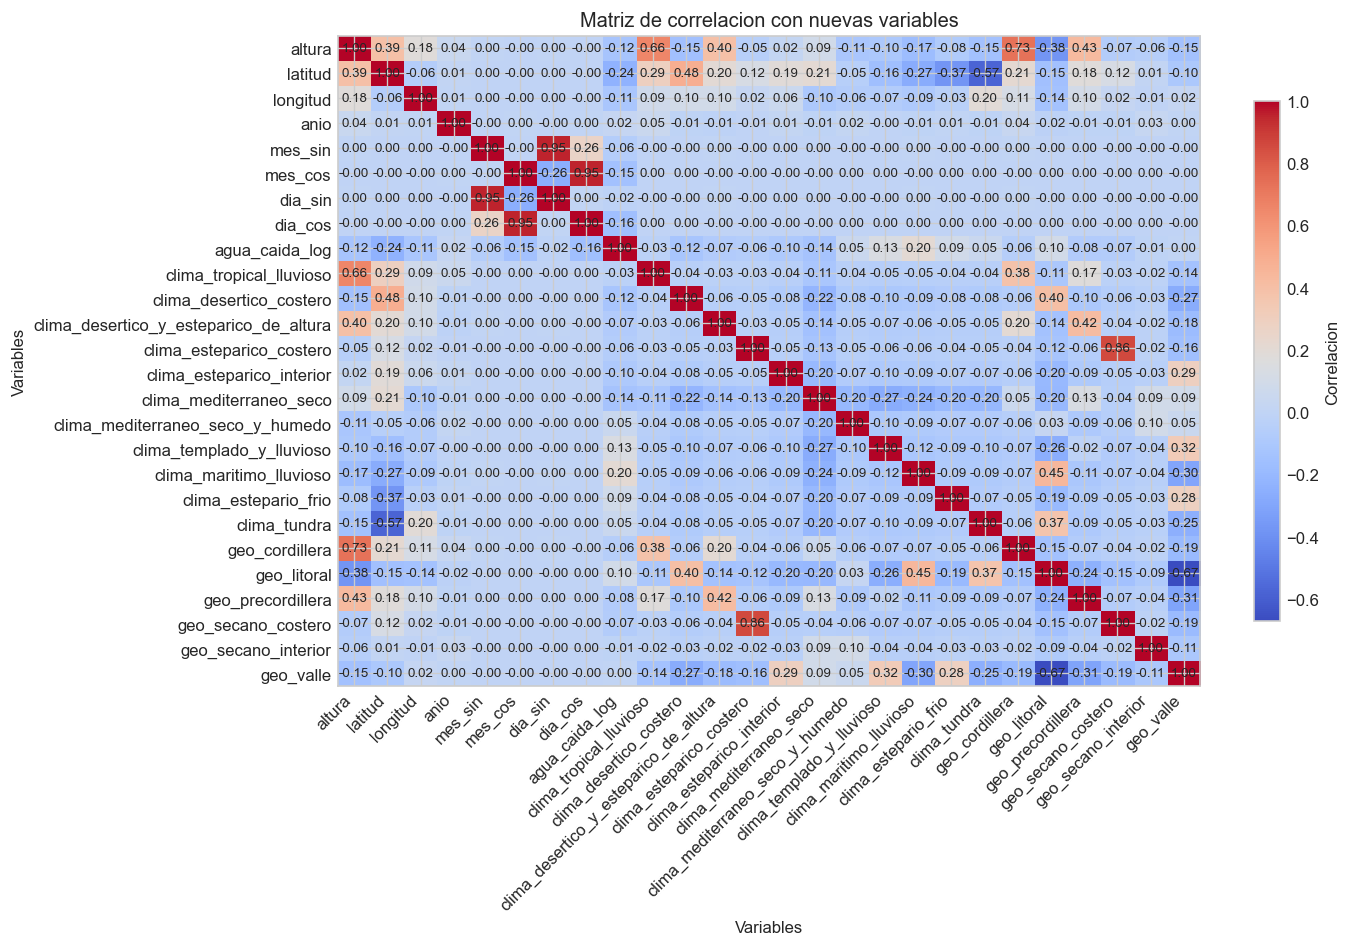

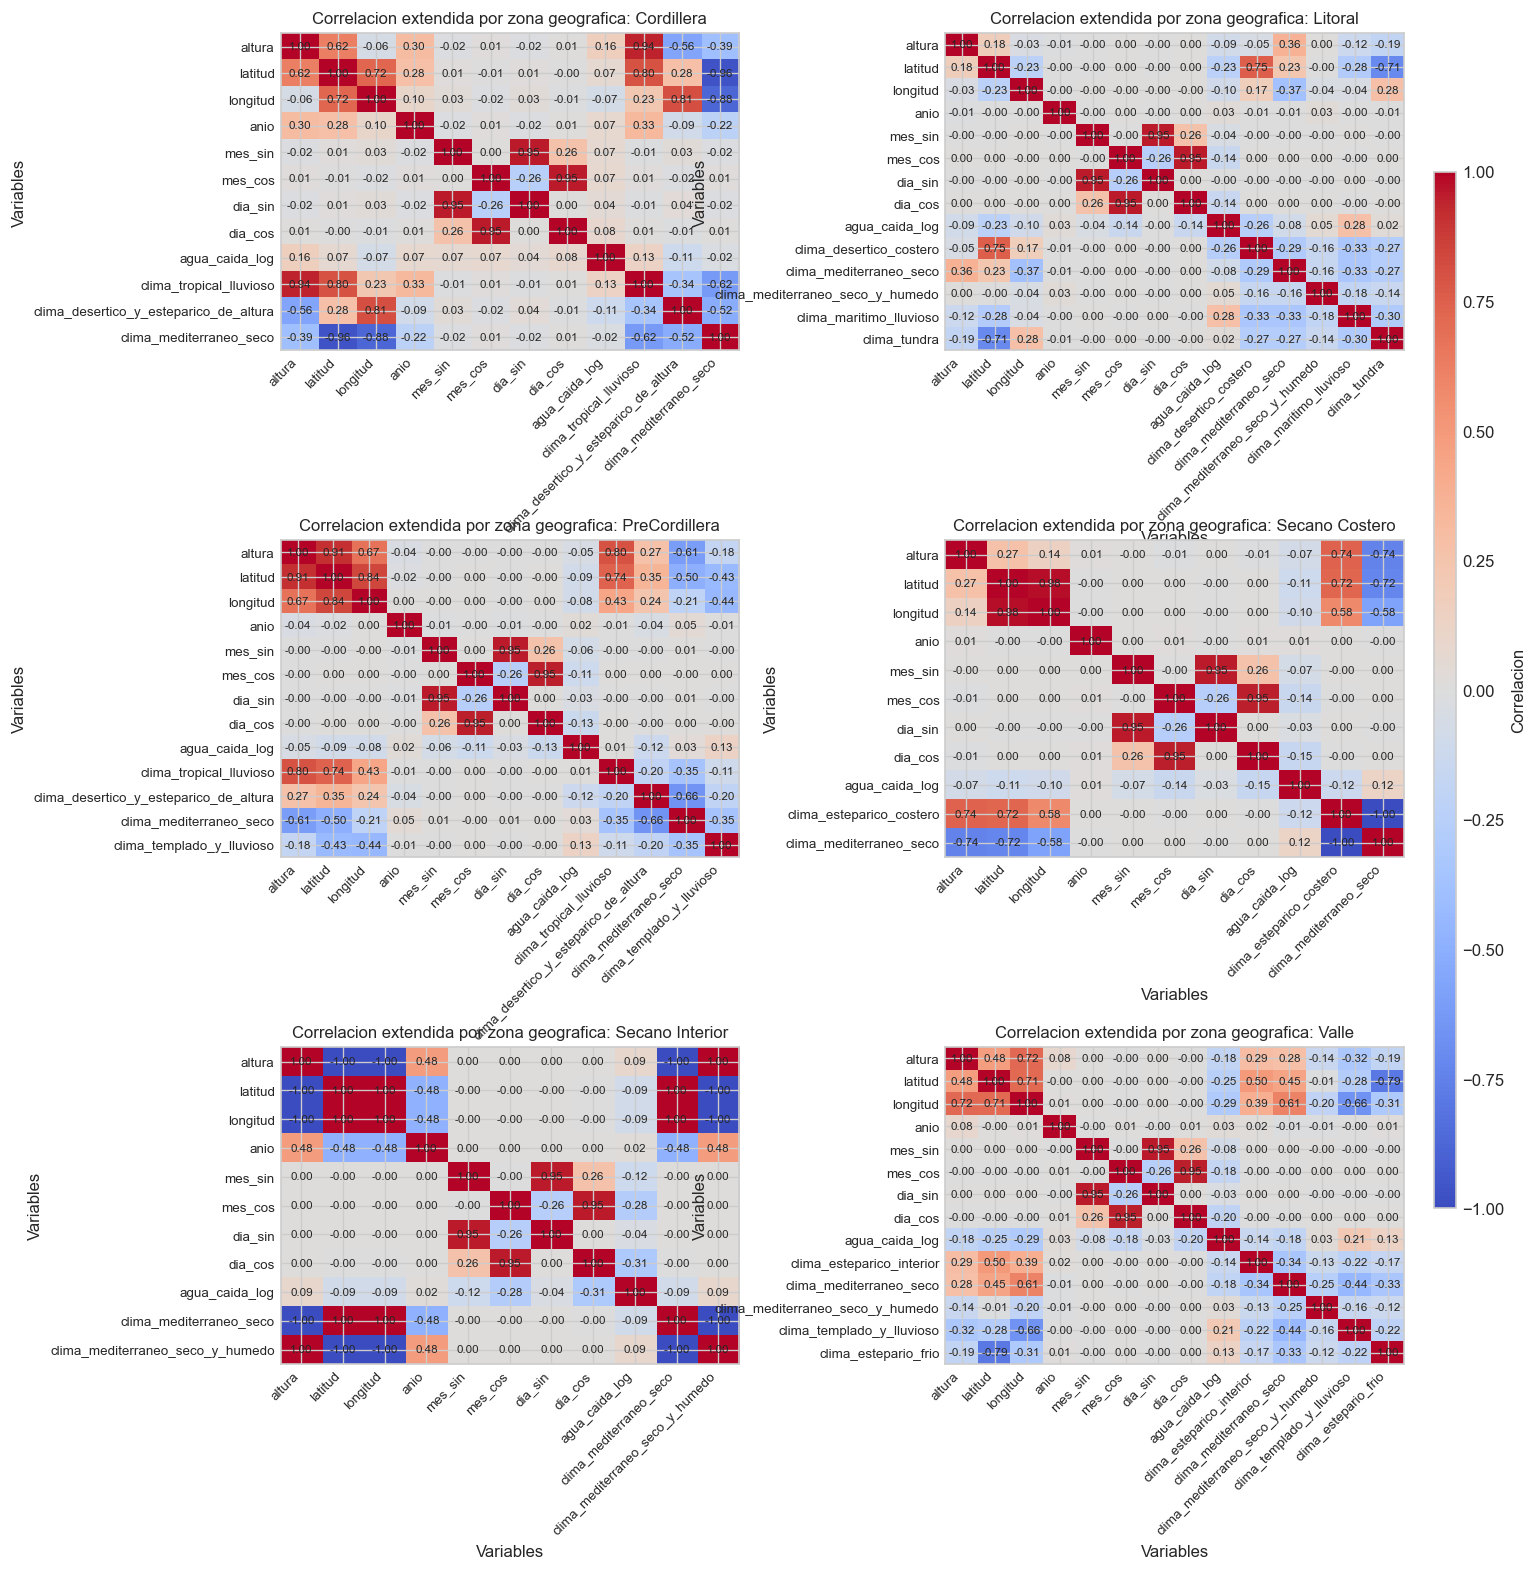

In [216]:
heatmap_df(
    matriz_corr_extendida,
    "Matriz de correlacion con nuevas variables",
    cmap="coolwarm",
    figsize=(12, 8),
    decimals=2,
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)

plot_group_heatmaps(
    corr_extendida_por_zona,
    "Correlacion extendida por zona geografica",
    cmap="coolwarm",
    decimals=2,
    ncols=2,
    base_figsize=(6.2, 4.8),
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)


**Analisis.** La nueva matriz resulta bastante mas interpretable que la inicial porque incorpora estructuras temporales y una clasificacion territorial explicita. A nivel global ya se nota mejor el aporte de las componentes ciclicas, la latitud y las dummies climaticas, pero la lectura por `zona_geografica` vuelve a ser clave: no todas las zonas responden igual a las mismas variables derivadas. En algunas, la estacionalidad pesa mas; en otras, la posicion espacial o la pertenencia climatica gana protagonismo. Esto refuerza una idea importante para defender el notebook: las nuevas variables no solo agregan columnas, sino que permiten describir mejor un fenomeno cuyo comportamiento cambia segun el contexto geografico.


### 2.10 Patrones/comportamientos detectados con nuevas variables


Finalmente, se revisa si las variables creadas ayudan a revelar patrones mas claros en la precipitacion diaria. En particular, interesa observar como cambia el comportamiento entre zonas climaticas y estaciones del ano, sin perder de vista que cada grupo sigue conteniendo estaciones, zonas geograficas y regiones distintas en su interior.


In [217]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

recuento_estacional = (
    df_features.groupby(["estacion_anual", "zona_climatica", "macrozona"], observed=False)
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("lluvia_evento", "sum"),
    )
    .reset_index()
)

recuento_estacional["estacion_anual"] = pd.Categorical(
    recuento_estacional["estacion_anual"],
    categories=orden_estaciones,
    ordered=True,
)
recuento_estacional = recuento_estacional.sort_values(["estacion_anual", "zona_climatica", "macrozona"])

display(
    recuento_estacional.sort_values(["dias_con_lluvia", "registros"], ascending=False).head(20)
)


,estacion_anual,zona_climatica,macrozona,registros,dias_con_lluvia
113,Invierno,Mediterraneo seco,Centro,17020,5072
123,Invierno,Templado y lluvioso,Sur,5336,3637
79,Otono,Templado y lluvioso,Sur,5336,2978
69,Otono,Mediterraneo seco,Centro,17069,2602
167,Primavera,Templado y lluvioso,Sur,5278,2197
157,Primavera,Mediterraneo seco,Centro,16755,2190
67,Otono,Maritimo lluvioso,Sur,3220,2183
111,Invierno,Maritimo lluvioso,Sur,3220,2123
119,Invierno,Mediterraneo seco y humedo,Sur,3312,1867
155,Primavera,Maritimo lluvioso,Sur,3185,1805


Una vez creadas las variables derivadas, conviene volver a mirar la estacionalidad, pero ahora como numero de eventos observados. Este enfoque es mas consistente con la naturaleza intermitente de la lluvia diaria y permite ver mejor la combinacion entre estacion del ano, `zona_climatica` y `macrozona`.


In [218]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

frecuencia_zona_climatica = (
    df_features.pivot_table(
        index="estacion_anual",
        columns="zona_climatica",
        values="lluvia_evento",
        aggfunc="sum",
        fill_value=0,
        observed=False,
    )
    .reindex(orden_estaciones)
    .reindex(columns=ACTIVE_CLIMATE_ORDER, fill_value=0)
    .astype(int)
)

frecuencia_zona_climatica.index.name = "estacion_anual"

display(frecuencia_zona_climatica)


zona_climatica,Tropical lluvioso,Desertico costero,Desertico y Esteparico de altura,Esteparico costero,Esteparico interior,Mediterraneo seco,Mediterraneo seco y humedo,Templado y lluvioso,Maritimo lluvioso,Estepario frio,Tundra
estacion_anual,,,,,,,,,,,
Verano,409,19,22,31,5,858,260,924,1721,1115,1588
Otono,170,12,26,51,125,2602,1283,2978,3026,1632,1601
Invierno,2,21,71,174,433,5072,1867,3637,2975,1803,1441
Primavera,55,26,13,74,65,2190,940,2197,2487,1303,1393


La tabla complementaria resume los dias con lluvia por estacion del ano y zona climatica. Asi se conserva una vista compacta para comparar clases, pero sin volver al promedio como unica medida descriptiva.


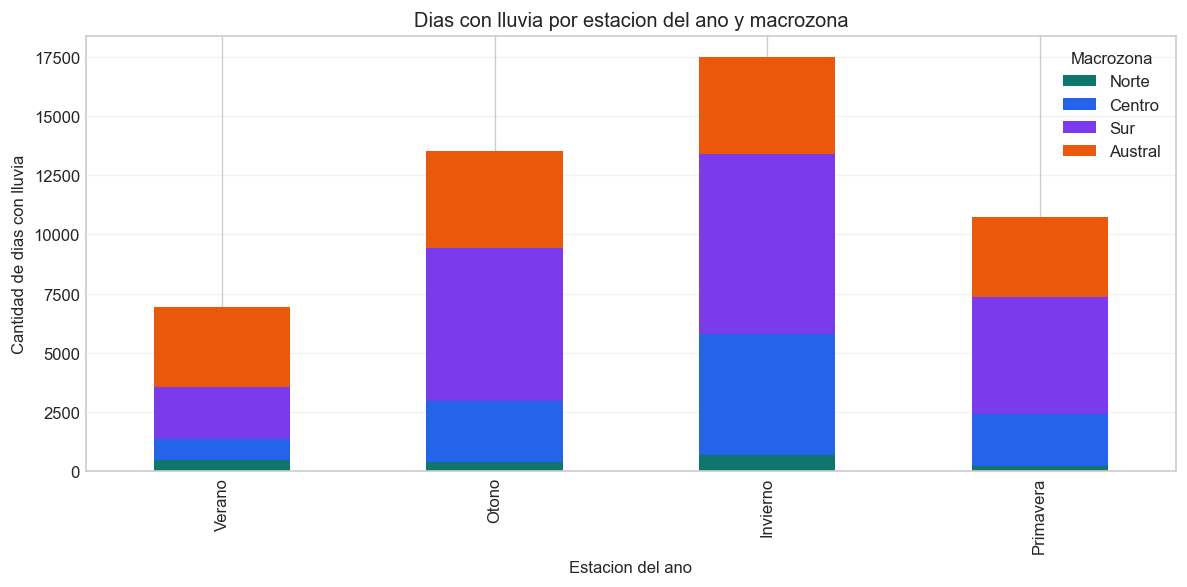

In [219]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

estacional_macrozona = (
    recuento_estacional.groupby(["estacion_anual", "macrozona"], observed=False)["dias_con_lluvia"]
    .sum()
    .unstack(fill_value=0)
    .reindex(index=orden_estaciones, columns=[mz for mz in MACROZONE_ORDER if mz in recuento_estacional["macrozona"].unique()], fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
estacional_macrozona.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[MACROZONE_COLORS.get(col, "#94a3b8") for col in estacional_macrozona.columns],
)
ax.set_title("Dias con lluvia por estacion del ano y macrozona")
ax.set_xlabel("Estacion del ano")
ax.set_ylabel("Cantidad de dias con lluvia")
ax.legend(title="Macrozona")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


La barra apilada por `macrozona` resume la distribucion estacional de los eventos de lluvia a gran escala. El heatmap siguiente completa la lectura mostrando la misma idea desde la perspectiva de `zona_climatica`.


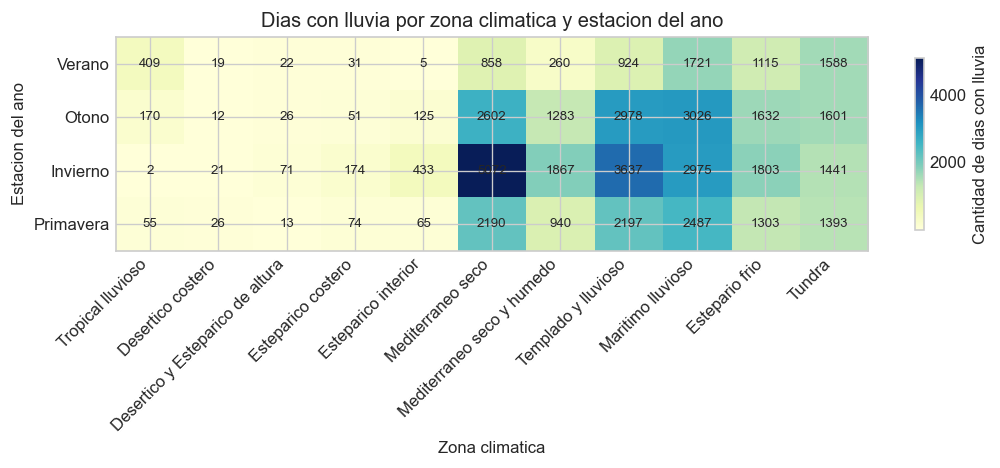

In [220]:
heatmap_df(
    frecuencia_zona_climatica,
    "Dias con lluvia por zona climatica y estacion del ano",
    cmap="YlGnBu",
    figsize=(9, 4),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Estacion del ano",
    cbar_label="Cantidad de dias con lluvia",
)


**Analisis.** Con las nuevas variables, la estacionalidad se vuelve mucho mas facil de defender porque ya no depende solo de un promedio por clase. El grafico de barras apiladas muestra cuantos eventos de lluvia aparecen realmente en cada estacion del ano y como esos eventos se reparten entre macrozonas, mientras que el heatmap permite comparar rapidamente la contribucion de cada `zona_climatica`. En conjunto, ambas vistas refuerzan que los regimenes lluviosos del sur y austral concentran mas dias con precipitacion, mientras que los sectores aridos y mediterraneos secos presentan una ocurrencia mucho mas acotada y estacional.


### 2.10 EDA senior orientado al modelamiento

Antes de transformar la base para modelamiento conviene cerrar la fase exploratoria con una lectura ejecutiva de calidad, cobertura y comportamiento de la variable objetivo. Este bloque no busca repetir todos los graficos previos, sino responder preguntas practicas de modelamiento: si la llave estacion-fecha es unica, si la metadata territorial esta completa, que tan concentrados estan los nulos, que tan asimetrica es `agua_caida` y si existen eventos extremos que deban auditarse antes de entrenar modelos. Esta lectura es especialmente importante en precipitaciones, porque la variable suele estar inflada en ceros y una regla estadistica aplicada sin contexto puede confundir lluvia real intensa con error.

In [221]:
eda_df = df.copy()
eda_df["fecha"] = pd.to_datetime(eda_df["fecha"])

eda_resumen = pd.DataFrame(
    {
        "metrica": [
            "filas",
            "columnas",
            "estaciones",
            "regiones",
            "fecha_min",
            "fecha_max",
            "duplicados_estacion_fecha",
            "nulos_agua_caida",
            "pct_nulos_agua_caida",
            "pct_ceros_agua_caida",
            "pct_lluvia_positiva",
        ],
        "valor": [
            len(eda_df),
            eda_df.shape[1],
            eda_df["codigo_estacion"].nunique(),
            eda_df["region"].nunique(),
            eda_df["fecha"].min().date(),
            eda_df["fecha"].max().date(),
            int(eda_df.duplicated(["codigo_estacion", "fecha"]).sum()),
            int(eda_df["agua_caida"].isna().sum()),
            round(eda_df["agua_caida"].isna().mean() * 100, 2),
            round(eda_df["agua_caida"].eq(0).mean() * 100, 2),
            round(eda_df["agua_caida"].gt(0).mean() * 100, 2),
        ],
    }
)

nulos_por_segmento = (
    eda_df.assign(agua_caida_nula=eda_df["agua_caida"].isna())
    .groupby(["macrozona", "zona_climatica"], observed=True)
    .agg(
        filas=("agua_caida", "size"),
        nulos=("agua_caida_nula", "sum"),
        lluvia_media=("agua_caida", "mean"),
        lluvia_p95=("agua_caida", lambda s: s.quantile(0.95)),
    )
    .assign(pct_nulos=lambda x: (x["nulos"] / x["filas"] * 100).round(2))
    .sort_values("pct_nulos", ascending=False)
    .reset_index()
)

resumen_anual = (
    eda_df.assign(anio_fecha=eda_df["fecha"].dt.year)
    .groupby("anio_fecha")
    .agg(
        filas=("agua_caida", "size"),
        nulos=("agua_caida", lambda s: int(s.isna().sum())),
        dias_con_lluvia=("agua_caida", lambda s: int((s > 0).sum())),
        max_mm=("agua_caida", "max"),
    )
    .reset_index()
)

display(eda_resumen)
display(nulos_por_segmento.head(10))
display(resumen_anual)

,metrica,valor
0,filas,187876
1,columnas,15
2,estaciones,109
3,regiones,16
4,fecha_min,2021-01-01
5,fecha_max,2025-12-31
6,duplicados_estacion_fecha,0
7,nulos_agua_caida,17063
8,pct_nulos_agua_caida,9.08
9,pct_ceros_agua_caida,67.68


,macrozona,zona_climatica,filas,nulos,lluvia_media,lluvia_p95,pct_nulos
0,Norte,Desertico y Esteparico de altura,6795,1205,0.105116,0.00,17.73
1,Sur,Maritimo lluvioso,12782,2229,4.084886,20.60,17.44
2,Austral,Maritimo lluvioso,4959,794,3.873517,20.96,16.01
3,Norte,Tropical lluvioso,4018,586,0.489831,3.20,14.58
4,Sur,Templado y lluvioso,21177,2778,3.004207,17.60,13.12
5,Austral,Estepario frio,12052,1194,2.232115,12.40,9.91
6,Norte,Esteparico interior,12673,1146,0.203574,0.10,9.04
7,Sur,Mediterraneo seco y humedo,13147,1040,2.779012,15.40,7.91
8,Norte,Desertico costero,14604,1095,0.002791,0.00,7.50
9,Centro,Mediterraneo seco,67445,4428,0.979283,3.40,6.57


,anio_fecha,filas,nulos,dias_con_lluvia,max_mm
0,2021,35606,4215,7451,126.800003
1,2022,35735,3412,8257,136.399994
2,2023,38325,4799,8537,150.199997
3,2024,39162,2954,9392,98.599998
4,2025,39048,1683,10020,3574.300049


La variable objetivo debe mirarse como una distribucion `zero-inflated`: muchos dias no llueve, una fraccion menor tiene lluvia moderada y unos pocos eventos concentran valores muy altos. Por eso el EDA final separa tres lecturas: cuantiles de `agua_caida`, eventos extremos ordenados y diagnostico preliminar del IQR. El conteo del IQR se calcula y no se fuerza manualmente; si el numero de outliers no coincide con lo esperado, eso no es un detalle cosmetico, sino una senal de que la regla debe interpretarse con cuidado.

In [222]:
cuantiles_agua = eda_df["agua_caida"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1]).round(3)
cuantiles_agua = cuantiles_agua.rename_axis("cuantil").reset_index(name="agua_caida_mm")

q1_eda = eda_df["agua_caida"].quantile(0.25)
q3_eda = eda_df["agua_caida"].quantile(0.75)
iqr_eda = q3_eda - q1_eda
limite_inferior_eda = q1_eda - 1.5 * iqr_eda
limite_superior_eda = q3_eda + 1.5 * iqr_eda
outliers_iqr_eda = eda_df["agua_caida"].notna() & (
    (eda_df["agua_caida"] < limite_inferior_eda) | (eda_df["agua_caida"] > limite_superior_eda)
)

diagnostico_iqr_eda = pd.DataFrame(
    {
        "Q1": [round(q1_eda, 3)],
        "Q3": [round(q3_eda, 3)],
        "IQR": [round(iqr_eda, 3)],
        "limite_inferior": [round(limite_inferior_eda, 3)],
        "limite_superior": [round(limite_superior_eda, 3)],
        "outliers_iqr": [int(outliers_iqr_eda.sum())],
        "pct_observados_marcados": [round(outliers_iqr_eda.sum() / eda_df["agua_caida"].notna().sum() * 100, 2)],
    }
)

eventos_extremos = (
    eda_df.loc[eda_df["agua_caida"].notna()]
    .sort_values("agua_caida", ascending=False)
    [["fecha", "codigo_estacion", "nombre_estacion", "nombre_region", "macrozona", "zona_climatica", "agua_caida"]]
    .head(12)
)

display(cuantiles_agua)
display(diagnostico_iqr_eda)
display(eventos_extremos)

,cuantil,agua_caida_mm
0,0.000,0.000
1,0.250,0.000
2,0.500,0.000
3,0.750,0.100
4,0.900,3.000
5,0.950,8.600
6,0.990,27.800
7,0.999,62.656
8,1.000,3574.300


,Q1,Q3,IQR,limite_inferior,limite_superior,outliers_iqr,pct_observados_marcados
0,0.0,0.1,0.1,-0.15,0.25,32994,19.32


,fecha,codigo_estacion,nombre_estacion,nombre_region,macrozona,zona_climatica,agua_caida
75680,2025-12-08,330075,RÃ­o Clarillo,Metropolitana de Santiago,Centro,Mediterraneo seco,3574.300049
133239,2025-12-07,380082,Isla Mocha Ad.,Del BiobÃ­o,Sur,Mediterraneo seco y humedo,3541.500000
75679,2025-12-07,330075,RÃ­o Clarillo,Metropolitana de Santiago,Centro,Mediterraneo seco,2917.399902
133240,2025-12-09,380082,Isla Mocha Ad.,Del BiobÃ­o,Sur,Mediterraneo seco y humedo,1459.900024
75681,2025-12-09,330075,RÃ­o Clarillo,Metropolitana de Santiago,Centro,Mediterraneo seco,880.099976
97400,2023-08-21,340031,"General Freire, CuricÃ³ Ad.",Del Maule,Centro,Mediterraneo seco,150.199997
74780,2023-06-22,330075,RÃ­o Clarillo,Metropolitana de Santiago,Centro,Mediterraneo seco,145.199997
123155,2022-04-28,380018,Lonquimay,De La AraucanÃ­a,Sur,Templado y lluvioso,136.399994
138886,2021-05-31,390043,Corral ESSAL,De Los RÃ­os,Sur,Maritimo lluvioso,126.800003
102878,2023-08-21,340066,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,Centro,Mediterraneo seco,121.300003


### 2.11 Exploracion de temperaturas del dataset nuevo

El nuevo archivo incorpora `temp_max`, `temp_min` y `temp_media`. Antes de llevarlas al modelamiento, se revisa su cobertura, distribucion, nulos, consistencia fisica y relacion con la precipitacion. Esta revision es importante porque una variable nueva puede mejorar los modelos, pero tambien puede introducir ruido si entra con faltantes o inconsistencias sin tratar.


In [ ]:
temperaturas_fase2 = df.copy()
columnas_temperatura = [col for col in TEMPERATURE_COLUMNS if col in temperaturas_fase2.columns]

if columnas_temperatura:
    resumen_cobertura_temperatura = pd.DataFrame(
        {
            "variable": columnas_temperatura,
            "observados": [int(temperaturas_fase2[col].notna().sum()) for col in columnas_temperatura],
            "nulos": [int(temperaturas_fase2[col].isna().sum()) for col in columnas_temperatura],
            "pct_nulos": [round(temperaturas_fase2[col].isna().mean() * 100, 2) for col in columnas_temperatura],
            "min": [round(temperaturas_fase2[col].min(), 2) for col in columnas_temperatura],
            "mediana": [round(temperaturas_fase2[col].median(), 2) for col in columnas_temperatura],
            "max": [round(temperaturas_fase2[col].max(), 2) for col in columnas_temperatura],
        }
    )

    descriptivos_temperatura = (
        temperaturas_fase2[columnas_temperatura]
        .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        .T
        .round(2)
    )

    consistencia_temperatura = pd.DataFrame(
        {
            "revision": ["temp_min_mayor_temp_max", "temp_media_fuera_de_rango_min_max"],
            "registros": [
                int((temperaturas_fase2["temp_min"] > temperaturas_fase2["temp_max"]).sum())
                if {"temp_min", "temp_max"}.issubset(temperaturas_fase2.columns) else 0,
                int(
                    (
                        (temperaturas_fase2["temp_media"] < temperaturas_fase2["temp_min"])
                        | (temperaturas_fase2["temp_media"] > temperaturas_fase2["temp_max"])
                    ).sum()
                )
                if {"temp_min", "temp_media", "temp_max"}.issubset(temperaturas_fase2.columns) else 0,
            ],
        }
    )

    nulos_temperatura_zona = (
        temperaturas_fase2.groupby("zona_climatica")[columnas_temperatura]
        .agg(lambda s: round(s.isna().mean() * 100, 2))
        .reindex(ACTIVE_CLIMATE_ORDER)
    )

    nulos_temperatura_anio = (
        temperaturas_fase2.groupby("anio")[columnas_temperatura]
        .agg(lambda s: round(s.isna().mean() * 100, 2))
        .reset_index()
        .sort_values("anio")
    )

    limites_temperatura = {
        "temp_min": (-30, 35),
        "temp_media": (-25, 40),
        "temp_max": (-20, 50),
    }
    outliers_temperatura = []
    for col in columnas_temperatura:
        serie = temperaturas_fase2[col].dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        iqr_inf = q1 - 1.5 * iqr
        iqr_sup = q3 + 1.5 * iqr
        fisico_inf, fisico_sup = limites_temperatura.get(col, (-np.inf, np.inf))
        outliers_temperatura.append(
            {
                "variable": col,
                "Q1": round(q1, 2),
                "Q3": round(q3, 2),
                "IQR": round(iqr, 2),
                "outliers_iqr": int(((temperaturas_fase2[col] < iqr_inf) | (temperaturas_fase2[col] > iqr_sup)).sum()),
                "limite_fisico_inf": fisico_inf,
                "limite_fisico_sup": fisico_sup,
                "fuera_limite_fisico": int(((temperaturas_fase2[col] < fisico_inf) | (temperaturas_fase2[col] > fisico_sup)).sum()),
            }
        )
    outliers_temperatura = pd.DataFrame(outliers_temperatura)

    corr_temperatura_lluvia = (
        temperaturas_fase2[["agua_caida"] + columnas_temperatura + ["altura", "latitud", "longitud", "mes"]]
        .corr(numeric_only=True)["agua_caida"]
        .drop("agua_caida")
        .sort_values(ascending=False)
        .round(3)
        .reset_index()
        .rename(columns={"index": "variable", "agua_caida": "correlacion_con_agua_caida"})
    )

    temperatura_mensual = (
        temperaturas_fase2.groupby("mes")
        .agg(
            temp_min_promedio=("temp_min", "mean"),
            temp_media_promedio=("temp_media", "mean"),
            temp_max_promedio=("temp_max", "mean"),
            dias_con_lluvia=("agua_caida", lambda s: int((s > 0).sum())),
            lluvia_media=("agua_caida", "mean"),
        )
        .round(2)
    )

    temp_media_clima_mes = (
        temperaturas_fase2.pivot_table(
            index="mes",
            columns="zona_climatica",
            values="temp_media",
            aggfunc="mean",
            observed=False,
        )
        .reindex(index=range(1, 13), columns=ACTIVE_CLIMATE_ORDER)
        .round(2)
    )

    display(resumen_cobertura_temperatura)
    display(descriptivos_temperatura)
    display(consistencia_temperatura)
    display(nulos_temperatura_zona)
    display(nulos_temperatura_anio)
    display(outliers_temperatura)
    display(corr_temperatura_lluvia)
    display(temperatura_mensual)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    temperaturas_fase2[columnas_temperatura].plot(kind="box", ax=axes[0], color="#0f766e")
    axes[0].set_title("Distribucion de temperaturas")
    axes[0].set_ylabel("Grados Celsius")
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].plot(temperatura_mensual.index, temperatura_mensual["temp_min_promedio"], marker="o", label="Temp min", color="#2563eb")
    axes[1].plot(temperatura_mensual.index, temperatura_mensual["temp_media_promedio"], marker="o", label="Temp media", color="#ef4444")
    axes[1].plot(temperatura_mensual.index, temperatura_mensual["temp_max_promedio"], marker="o", label="Temp max", color="#f97316")
    axes[1].set_title("Temperatura promedio por mes")
    axes[1].set_xlabel("Mes")
    axes[1].set_ylabel("Grados Celsius")
    axes[1].set_xticks(range(1, 13))
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    heatmap_df(
        nulos_temperatura_zona,
        "Nulos de temperatura por zona climatica",
        cmap="YlOrRd",
        figsize=(9, 5),
        decimals=1,
        xlabel="Variable de temperatura",
        ylabel="Zona climatica",
        cbar_label="% nulos",
    )

    heatmap_df(
        temp_media_clima_mes,
        "Temperatura media por mes y zona climatica",
        cmap="RdYlBu_r",
        figsize=(10, 5),
        decimals=1,
        xlabel="Zona climatica",
        ylabel="Mes",
        cbar_label="Temperatura media (C)",
    )

    temperatura_features_sugeridas = pd.DataFrame(
        {
            "feature": [
                "temp_amplitud",
                "temp_media_lag_1",
                "temp_media_media_movil_7",
                "banderas de imputacion de temperatura",
                "banderas de consistencia fisica",
            ],
            "uso_en_modelamiento": [
                "Captura diferencia diaria entre maxima y minima",
                "Representa inercia termica del dia anterior por estacion",
                "Suaviza comportamiento termico reciente",
                "Conserva trazabilidad de datos faltantes",
                "Evita que el modelo aprenda relaciones fisicamente imposibles",
            ],
        }
    )
    display(temperatura_features_sugeridas)
else:
    print("El dataset cargado no contiene columnas de temperatura.")


**Analisis de temperaturas.** Las nuevas variables complementan bien la base porque agregan informacion meteorologica diaria que antes no estaba disponible. En cobertura, `temp_max` presenta 21,047 nulos, `temp_min` 21,965 y `temp_media` 22,713; por tanto, su tratamiento debe ir junto al de `agua_caida` y no despues del modelamiento. En consistencia, aparecen 50 registros donde la minima supera a la maxima y 374 donde la media queda fuera del rango minima-maxima. Esos casos son pocos frente al volumen total, pero son suficientes para justificar banderas y correcciones en preparacion. La correlacion lineal simple con `agua_caida` es baja, lo cual no descarta su utilidad: en precipitacion diaria el aporte suele aparecer por interaccion con mes, zona climatica, altura y rezagos. Por eso se conservaran las temperaturas, se imputaran con mediana contextual y se crearan variables termicas para alimentar los modelos supervisados y el clustering.


## 3. Fase 3: Transformacion de los Datos (CRISP-DM)

En esta fase el objetivo es convertir el `df` enriquecido en matrices listas para modelamiento supervisado. La regla general sera mantener trazabilidad: no se sobreescribe sin respaldo la variable original, se crean banderas para saber que fue imputado o tratado como outlier, y las transformaciones que aprenden parametros se ajustan solo con entrenamiento. Con el dataset nuevo, la preparacion tambien incorpora `temp_max`, `temp_min` y `temp_media`, porque estas variables aportan contexto meteorologico diario para complementar la prediccion de precipitacion.


### 3.1 Tratamiento de nulos: imputacion de `agua_caida` y temperaturas


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Copia de trabajo de Fase 3: el df original queda disponible para auditoria.
df_fase3 = df.copy()
df_fase3["fecha"] = pd.to_datetime(df_fase3["fecha"])
columnas_temperatura_fase3 = [col for col in TEMPERATURE_COLUMNS if col in df_fase3.columns]

df_fase3["agua_caida_original"] = df_fase3["agua_caida"]
df_fase3["agua_caida_fue_imputada"] = df_fase3["agua_caida"].isna().astype(int)

for col in columnas_temperatura_fase3:
    df_fase3[f"{col}_original"] = df_fase3[col]
    df_fase3[f"{col}_fue_imputada"] = df_fase3[col].isna().astype(int)


def imputar_mediana_contextual_generica(dataframe, columna, clip_lower=None):
    mediana_estacion_mes = dataframe.groupby(["codigo_estacion", "mes"], observed=True)[columna].transform("median")
    mediana_clima_mes = dataframe.groupby(["zona_climatica", "mes"], observed=True)[columna].transform("median")
    mediana_macro_mes = dataframe.groupby(["macrozona", "mes"], observed=True)[columna].transform("median")
    mediana_mes = dataframe.groupby("mes", observed=True)[columna].transform("median")
    mediana_global = dataframe[columna].median()

    serie_imputada = (
        dataframe[columna]
        .fillna(mediana_estacion_mes)
        .fillna(mediana_clima_mes)
        .fillna(mediana_macro_mes)
        .fillna(mediana_mes)
        .fillna(mediana_global)
    )
    if clip_lower is not None:
        serie_imputada = serie_imputada.clip(lower=clip_lower)
    return serie_imputada


metodo_imputacion = "mediana_contextual"

for col in columnas_temperatura_fase3:
    df_fase3[col] = imputar_mediana_contextual_generica(df_fase3, col)

df_fase3["agua_caida"] = imputar_mediana_contextual_generica(df_fase3, "agua_caida", clip_lower=0)

if {"temp_min", "temp_max"}.issubset(df_fase3.columns):
    mask_min_mayor_max = df_fase3["temp_min"] > df_fase3["temp_max"]
    temp_min_original = df_fase3["temp_min"].copy()
    temp_max_original = df_fase3["temp_max"].copy()
    df_fase3.loc[mask_min_mayor_max, "temp_min"] = temp_max_original.loc[mask_min_mayor_max]
    df_fase3.loc[mask_min_mayor_max, "temp_max"] = temp_min_original.loc[mask_min_mayor_max]
    df_fase3["temp_min_mayor_temp_max_corregida"] = mask_min_mayor_max.astype(int)

if {"temp_min", "temp_media", "temp_max"}.issubset(df_fase3.columns):
    mask_media_fuera_rango = (
        (df_fase3["temp_media"] < df_fase3["temp_min"])
        | (df_fase3["temp_media"] > df_fase3["temp_max"])
    )
    df_fase3["temp_media_fuera_rango_corregida"] = mask_media_fuera_rango.astype(int)
    df_fase3.loc[mask_media_fuera_rango, "temp_media"] = (
        df_fase3.loc[mask_media_fuera_rango, ["temp_min", "temp_max"]].mean(axis=1)
    )

if {"temp_min", "temp_max"}.issubset(df_fase3.columns):
    df_fase3["temp_amplitud"] = df_fase3["temp_max"] - df_fase3["temp_min"]

resumen_imputacion = []
for col in ["agua_caida"] + columnas_temperatura_fase3:
    original_col = f"{col}_original"
    flag_col = f"{col}_fue_imputada"
    resumen_imputacion.append(
        {
            "variable": col,
            "metodo_usado": metodo_imputacion,
            "nulos_antes": int(df_fase3[original_col].isna().sum()),
            "nulos_despues": int(df_fase3[col].isna().sum()),
            "mediana_observada": round(df_fase3[original_col].median(), 3),
            "filas_imputadas": int(df_fase3[flag_col].sum()),
            "pct_imputado": round(df_fase3[flag_col].mean() * 100, 2),
        }
    )
resumen_imputacion = pd.DataFrame(resumen_imputacion)

comparacion_imputados = []
for col in ["agua_caida"] + columnas_temperatura_fase3:
    flag_col = f"{col}_fue_imputada"
    for flag, grupo in [(0, "observados"), (1, "imputados")]:
        serie = df_fase3.loc[df_fase3[flag_col] == flag, col]
        comparacion_imputados.append(
            {
                "variable": col,
                "grupo": grupo,
                "media": round(serie.mean(), 3),
                "mediana": round(serie.median(), 3),
                "p95": round(serie.quantile(0.95), 3),
            }
        )
comparacion_imputados = pd.DataFrame(comparacion_imputados)

resumen_consistencia_fase3 = pd.DataFrame(
    {
        "revision": ["temp_min_mayor_temp_max_corregida", "temp_media_fuera_rango_corregida"],
        "registros": [
            int(df_fase3.get("temp_min_mayor_temp_max_corregida", pd.Series(dtype=int)).sum()),
            int(df_fase3.get("temp_media_fuera_rango_corregida", pd.Series(dtype=int)).sum()),
        ],
    }
)

display(resumen_imputacion)
display(comparacion_imputados)
display(resumen_consistencia_fase3)


### 3.2 Tratamiento de outliers: lluvia y limites fisicos de temperatura


In [ ]:
df_fase3["agua_caida_pre_outlier"] = df_fase3["agua_caida"]

Q1 = df_fase3["agua_caida"].quantile(0.25)
Q3 = df_fase3["agua_caida"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
mediana_agua = df_fase3["agua_caida"].median()

outliers_iqr_estricto = (
    (df_fase3["agua_caida"] < limite_inferior)
    | (df_fase3["agua_caida"] > limite_superior)
)

# Criterio operacional: el IQR identifica candidatos, y el umbral de auditoria evita borrar lluvia real moderada.
umbral_auditoria_mm = 200
outliers_iqr_operacional = outliers_iqr_estricto & (df_fase3["agua_caida"] > umbral_auditoria_mm)

df_fase3["agua_caida_outlier_iqr_estricto"] = outliers_iqr_estricto.astype(int)
df_fase3["agua_caida_outlier_iqr"] = outliers_iqr_operacional.astype(int)
df_fase3["agua_caida_tratada_iqr_estricto"] = df_fase3["agua_caida"].mask(outliers_iqr_estricto, mediana_agua)
df_fase3["agua_caida_tratada"] = df_fase3["agua_caida"].mask(outliers_iqr_operacional, mediana_agua)
df_fase3["agua_caida_log1p"] = np.log1p(df_fase3["agua_caida_tratada"])

limites_temperatura_fase3 = {
    "temp_min": (-30, 35),
    "temp_media": (-25, 40),
    "temp_max": (-20, 50),
}
resumen_outliers_temperatura_fase3 = []
for col, (lim_inf, lim_sup) in limites_temperatura_fase3.items():
    if col not in df_fase3.columns:
        continue
    df_fase3[f"{col}_pre_outlier"] = df_fase3[col]
    mask_fuera_limite = (df_fase3[col] < lim_inf) | (df_fase3[col] > lim_sup)
    df_fase3[f"{col}_outlier_fisico"] = mask_fuera_limite.astype(int)
    if mask_fuera_limite.any():
        aux = df_fase3.copy()
        aux.loc[mask_fuera_limite, col] = np.nan
        reemplazos = imputar_mediana_contextual_generica(aux, col)
        df_fase3.loc[mask_fuera_limite, col] = reemplazos.loc[mask_fuera_limite]
    resumen_outliers_temperatura_fase3.append(
        {
            "variable": col,
            "limite_inferior": lim_inf,
            "limite_superior": lim_sup,
            "outliers_fisicos_reemplazados": int(mask_fuera_limite.sum()),
        }
    )

if {"temp_min", "temp_max"}.issubset(df_fase3.columns):
    df_fase3["temp_amplitud"] = df_fase3["temp_max"] - df_fase3["temp_min"]

resumen_outliers_fase3 = pd.DataFrame(
    {
        "Q1": [round(Q1, 3)],
        "Q3": [round(Q3, 3)],
        "IQR": [round(IQR, 3)],
        "limite_inferior": [round(limite_inferior, 3)],
        "limite_superior": [round(limite_superior, 3)],
        "mediana_reemplazo": [round(mediana_agua, 3)],
        "outliers_iqr_estricto": [int(outliers_iqr_estricto.sum())],
        "outliers_iqr_operacional": [int(outliers_iqr_operacional.sum())],
        "umbral_auditoria_mm": [umbral_auditoria_mm],
    }
)

comparacion_outliers = pd.DataFrame(
    {
        "variable": ["agua_caida_pre_outlier", "agua_caida_tratada_iqr_estricto", "agua_caida_tratada"],
        "media": [
            df_fase3["agua_caida_pre_outlier"].mean(),
            df_fase3["agua_caida_tratada_iqr_estricto"].mean(),
            df_fase3["agua_caida_tratada"].mean(),
        ],
        "mediana": [
            df_fase3["agua_caida_pre_outlier"].median(),
            df_fase3["agua_caida_tratada_iqr_estricto"].median(),
            df_fase3["agua_caida_tratada"].median(),
        ],
        "p95": [
            df_fase3["agua_caida_pre_outlier"].quantile(0.95),
            df_fase3["agua_caida_tratada_iqr_estricto"].quantile(0.95),
            df_fase3["agua_caida_tratada"].quantile(0.95),
        ],
        "max": [
            df_fase3["agua_caida_pre_outlier"].max(),
            df_fase3["agua_caida_tratada_iqr_estricto"].max(),
            df_fase3["agua_caida_tratada"].max(),
        ],
    }
).round(3)

resumen_outliers_temperatura_fase3 = pd.DataFrame(resumen_outliers_temperatura_fase3)

display(resumen_outliers_fase3)
display(comparacion_outliers)
display(resumen_outliers_temperatura_fase3)
display(
    df_fase3.loc[outliers_iqr_operacional, ["fecha", "codigo_estacion", "nombre_estacion", "agua_caida_pre_outlier", "agua_caida_tratada"]]
    .sort_values("agua_caida_pre_outlier", ascending=False)
)


### 3.3 Feature engineering temporal, rezagos y variables termicas


In [ ]:
def estacion_anio_chile(mes):
    if mes in [12, 1, 2]:
        return "Verano"
    if mes in [3, 4, 5]:
        return "Otono"
    if mes in [6, 7, 8]:
        return "Invierno"
    return "Primavera"

# Variables temporales explicitas.
df_fase3["anio"] = df_fase3["fecha"].dt.year
df_fase3["mes"] = df_fase3["fecha"].dt.month
df_fase3["dia"] = df_fase3["fecha"].dt.day
df_fase3["dia_anio"] = df_fase3["fecha"].dt.dayofyear
df_fase3["estacion_anio"] = df_fase3["mes"].apply(estacion_anio_chile)

# Codificacion ciclica para que diciembre y enero queden cerca en el espacio numerico.
df_fase3["mes_sin"] = np.sin(2 * np.pi * df_fase3["mes"] / 12)
df_fase3["mes_cos"] = np.cos(2 * np.pi * df_fase3["mes"] / 12)
df_fase3["dia_anio_sin"] = np.sin(2 * np.pi * df_fase3["dia_anio"] / 365.25)
df_fase3["dia_anio_cos"] = np.cos(2 * np.pi * df_fase3["dia_anio"] / 365.25)

# Rezagos por estacion meteorologica.
df_fase3 = df_fase3.sort_values(["codigo_estacion", "fecha"]).reset_index(drop=True)
grupo_estacion = df_fase3.groupby("codigo_estacion", group_keys=False)["agua_caida_tratada"]

df_fase3["lluvia_lag_1"] = grupo_estacion.shift(1)
df_fase3["lluvia_lag_2"] = grupo_estacion.shift(2)
df_fase3["lluvia_lag_7"] = grupo_estacion.shift(7)
df_fase3["lluvia_media_movil_7"] = grupo_estacion.transform(
    lambda serie: serie.shift(1).rolling(window=7, min_periods=1).mean()
)

if "temp_media" in df_fase3.columns:
    grupo_temp = df_fase3.groupby("codigo_estacion", group_keys=False)["temp_media"]
    df_fase3["temp_media_lag_1"] = grupo_temp.shift(1)
    df_fase3["temp_media_media_movil_7"] = grupo_temp.transform(
        lambda serie: serie.shift(1).rolling(window=7, min_periods=1).mean()
    )

features_creadas = [
    "mes", "estacion_anio", "dia_anio", "mes_sin", "mes_cos",
    "dia_anio_sin", "dia_anio_cos", "lluvia_lag_1", "lluvia_lag_2",
    "lluvia_lag_7", "lluvia_media_movil_7",
] + [col for col in ["temp_amplitud", "temp_media_lag_1", "temp_media_media_movil_7"] if col in df_fase3.columns]

resumen_features = pd.DataFrame(
    {
        "feature": features_creadas,
        "nulos": [int(df_fase3[col].isna().sum()) for col in features_creadas],
    }
)

columnas_muestra_fase3 = [
    "codigo_estacion", "fecha", "agua_caida_tratada", "estacion_anio",
    "lluvia_lag_1", "lluvia_lag_7", "lluvia_media_movil_7",
] + [col for col in ["temp_media", "temp_amplitud", "temp_media_lag_1"] if col in df_fase3.columns]

display(resumen_features)
display(df_fase3[columnas_muestra_fase3].head(12))


### 3.4 Transformaciones a numericos: One-Hot Encoding

Los modelos de scikit-learn trabajan con matrices numericas. Variables territoriales como `macrozona`, `zona_climatica` o `zona_geografica` son categoricas nominales: no existe una distancia ordinal valida entre "Norte" y "Sur" ni entre zonas climaticas. Por eso se usa One-Hot Encoding, que transforma cada categoria en una columna binaria.

Aunque `pd.get_dummies()` es simple, se aplica con disciplina de modelamiento: primero se separa entrenamiento y prueba por fecha, luego se generan dummies en train y test, y finalmente test se reindexa con las columnas de train. Asi se evita que categorias presentes solo en el periodo de prueba definan la estructura aprendida por el entrenamiento.

In [ ]:
# Separacion temporal: 2021-2024 para entrenamiento y 2025 para prueba.
corte_temporal = pd.Timestamp("2025-01-01")

df_modelado = df_fase3.sort_values("fecha").copy()
train_mask = df_modelado["fecha"] < corte_temporal
test_mask = df_modelado["fecha"] >= corte_temporal

if train_mask.sum() == 0 or test_mask.sum() == 0:
    corte_temporal = df_modelado["fecha"].quantile(0.8)
    train_mask = df_modelado["fecha"] < corte_temporal
    test_mask = df_modelado["fecha"] >= corte_temporal

variable_objetivo = "agua_caida_tratada"
columnas_temperatura_continua_modelo = [
    col for col in [
        "temp_max", "temp_min", "temp_media", "temp_amplitud",
        "temp_media_lag_1", "temp_media_media_movil_7",
    ] if col in df_modelado.columns
]
columnas_numericas_modelo = [
    "altura", "latitud", "longitud", "anio", "mes", "dia", "dia_anio",
    "mes_sin", "mes_cos", "dia_anio_sin", "dia_anio_cos",
    "lluvia_lag_1", "lluvia_lag_2", "lluvia_lag_7", "lluvia_media_movil_7",
] + columnas_temperatura_continua_modelo
columnas_indicadoras_modelo = [
    col for col in [
        "agua_caida_fue_imputada",
        "temp_max_fue_imputada", "temp_min_fue_imputada", "temp_media_fue_imputada",
        "temp_min_mayor_temp_max_corregida", "temp_media_fuera_rango_corregida",
        "temp_max_outlier_fisico", "temp_min_outlier_fisico", "temp_media_outlier_fisico",
    ] if col in df_modelado.columns
]
columnas_categoricas_modelo = [
    col for col in ["macrozona", "zona_climatica", "zona_geografica", "estacion_anio"] if col in df_modelado.columns
]

X_train_base = df_modelado.loc[train_mask, columnas_numericas_modelo + columnas_indicadoras_modelo + columnas_categoricas_modelo].copy()
X_test_base = df_modelado.loc[test_mask, columnas_numericas_modelo + columnas_indicadoras_modelo + columnas_categoricas_modelo].copy()
y_train = df_modelado.loc[train_mask, variable_objetivo].copy()
y_test = df_modelado.loc[test_mask, variable_objetivo].copy()

# Los nulos de lags aparecen al inicio de cada serie; se imputan con medianas aprendidas en train.
medianas_numericas_train = X_train_base[columnas_numericas_modelo].median()
X_train_num = X_train_base[columnas_numericas_modelo].fillna(medianas_numericas_train)
X_test_num = X_test_base[columnas_numericas_modelo].fillna(medianas_numericas_train)

X_train_ind = X_train_base[columnas_indicadoras_modelo].fillna(0).astype(int)
X_test_ind = X_test_base[columnas_indicadoras_modelo].fillna(0).astype(int)

X_train_cat = pd.get_dummies(
    X_train_base[columnas_categoricas_modelo],
    columns=columnas_categoricas_modelo,
    dtype=int,
    drop_first=True,
)
X_test_cat = pd.get_dummies(
    X_test_base[columnas_categoricas_modelo],
    columns=columnas_categoricas_modelo,
    dtype=int,
    drop_first=True,
).reindex(columns=X_train_cat.columns, fill_value=0)

X_train_pre_scaler = pd.concat([X_train_num, X_train_ind, X_train_cat], axis=1)
X_test_pre_scaler = pd.concat([X_test_num, X_test_ind, X_test_cat], axis=1)

resumen_encoding = pd.DataFrame(
    {
        "bloque": ["train", "test"],
        "filas": [len(X_train_pre_scaler), len(X_test_pre_scaler)],
        "columnas_numericas": [len(columnas_numericas_modelo), len(columnas_numericas_modelo)],
        "columnas_indicadoras": [len(columnas_indicadoras_modelo), len(columnas_indicadoras_modelo)],
        "columnas_dummy": [X_train_cat.shape[1], X_test_cat.shape[1]],
        "columnas_totales": [X_train_pre_scaler.shape[1], X_test_pre_scaler.shape[1]],
        "nulos_X": [int(X_train_pre_scaler.isna().sum().sum()), int(X_test_pre_scaler.isna().sum().sum())],
    }
)

display(resumen_encoding)
display(X_train_pre_scaler.head())


### 3.5 Escalamiento con `StandardScaler` y prevencion de Data Leakage

El escalamiento es necesario porque las variables continuas viven en unidades muy distintas: `altura` esta en metros, `latitud` y `longitud` en grados, y los rezagos en milimetros. `StandardScaler` transforma cada variable a una escala de media 0 y desviacion estandar 1, lo que ayuda especialmente a modelos sensibles a distancia o regularizacion.

La regla critica es que el escalador se ajusta solo con `X_train`. Si se calcularan medias y desviaciones usando todo el dataset, el periodo de prueba filtraria informacion futura hacia el entrenamiento. Por eso el codigo ejecuta `fit_transform()` sobre train y solo `transform()` sobre test. Las dummies no se escalan porque ya son indicadores 0/1.

In [251]:
escalador = StandardScaler()

X_train = X_train_pre_scaler.copy()
X_test = X_test_pre_scaler.copy()

X_train[columnas_numericas_modelo] = escalador.fit_transform(X_train[columnas_numericas_modelo])
X_test[columnas_numericas_modelo] = escalador.transform(X_test[columnas_numericas_modelo])

resumen_scaler = pd.DataFrame(
    {
        "variable": columnas_numericas_modelo,
        "media_train_post_scaler": X_train[columnas_numericas_modelo].mean().round(4).values,
        "std_train_post_scaler": X_train[columnas_numericas_modelo].std(ddof=0).round(4).values,
        "media_test_transformado": X_test[columnas_numericas_modelo].mean().round(4).values,
    }
)

resumen_final_modelado = pd.DataFrame(
    {
        "objeto": ["X_train", "X_test", "y_train", "y_test"],
        "filas": [X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]],
        "columnas": [X_train.shape[1], X_test.shape[1], 1, 1],
        "nulos": [
            int(X_train.isna().sum().sum()),
            int(X_test.isna().sum().sum()),
            int(y_train.isna().sum()),
            int(y_test.isna().sum()),
        ],
    }
)

assert X_train.shape[1] == X_test.shape[1], "Train y test deben tener las mismas columnas."
assert X_train.isna().sum().sum() == 0, "X_train no debe contener nulos."
assert X_test.isna().sum().sum() == 0, "X_test no debe contener nulos."
assert y_train.isna().sum() == 0, "y_train no debe contener nulos."
assert y_test.isna().sum() == 0, "y_test no debe contener nulos."

display(resumen_scaler)
display(resumen_final_modelado)

,variable,media_train_post_scaler,std_train_post_scaler,media_test_transformado
0,altura,-0.0,1.0,0.0640
1,latitud,-0.0,1.0,0.0111
2,longitud,0.0,1.0,0.0072
3,anio,0.0,1.0,2.1938
4,mes,0.0,1.0,0.0072
5,dia,0.0,1.0,-0.0003
6,dia_anio,-0.0,1.0,0.0051
7,mes_sin,0.0,1.0,-0.0043
8,mes_cos,0.0,1.0,0.0033
9,dia_anio_sin,0.0,1.0,-0.0042


,objeto,filas,columnas,nulos
0,X_train,148828,39,0
1,X_test,39048,39,0
2,y_train,148828,1,0
3,y_test,39048,1,0


### 3.6 Cierre de la transformacion

Al finalizar esta fase quedan construidos `X_train`, `X_test`, `y_train` y `y_test`. La preparacion respeta el orden temporal, conserva trazabilidad de imputaciones y outliers, transforma categorias territoriales a formato numerico y ajusta el escalador sin mirar el periodo de prueba. Con el nuevo dataset, las temperaturas quedan integradas como predictores continuos (`temp_max`, `temp_min`, `temp_media`, `temp_amplitud` y rezagos cuando existen) y como banderas de calidad cuando fueron imputadas o corregidas. Con esto la base queda lista para entrenar modelos de regresion y clasificacion con informacion meteorologica mas completa.


## 4. Fase 4: Modelamiento (CRISP-DM)

En esta fase se organizan los modelos en dos familias: aprendizaje supervisado y aprendizaje no supervisado. En el aprendizaje supervisado se trabajan dos objetivos: regresion, para estimar la cantidad de agua caida en milimetros, y clasificacion, para distinguir dias con lluvia y sin lluvia. En el aprendizaje no supervisado se aplica clustering para agrupar estaciones con comportamientos climaticos similares.


### 4.1 Aprendizaje supervisado

El aprendizaje supervisado utiliza variables predictoras `X` y una variable objetivo `Y`. En este proyecto se mantienen las matrices `X_train` y `X_test` preparadas en la fase 3, respetando el corte temporal entre entrenamiento y prueba para evitar fuga de informacion.


#### 4.1.1 Modelos de regresion

##### Seleccion de variables (X/Y)

Para regresion, la variable objetivo es `agua_caida_tratada`, que representa la precipitacion diaria en milimetros despues del tratamiento de nulos y outliers. Las variables predictoras corresponden a la matriz transformada `X_train` y `X_test`, ahora enriquecida con variables geograficas, temporales, territoriales y termicas (`temp_max`, `temp_min`, `temp_media`, `temp_amplitud` y rezagos cuando estan disponibles).


In [240]:
y_train_regresion = y_train.copy()
y_test_regresion = y_test.copy()

resumen_y_regresion = pd.DataFrame(
    {
        "bloque": ["train", "test"],
        "filas": [len(y_train_regresion), len(y_test_regresion)],
        "media": [round(y_train_regresion.mean(), 3), round(y_test_regresion.mean(), 3)],
        "mediana": [round(y_train_regresion.median(), 3), round(y_test_regresion.median(), 3)],
        "desviacion": [round(y_train_regresion.std(), 3), round(y_test_regresion.std(), 3)],
        "maximo": [round(y_train_regresion.max(), 3), round(y_test_regresion.max(), 3)],
    }
)

display(resumen_y_regresion)


,bloque,filas,media,mediana,desviacion,maximo
0,train,148828,1.296,0.0,5.239,150.2
1,test,39048,1.372,0.0,5.559,120.0


##### Seleccion de parametros

Se seleccionan cinco modelos de regresion: `LinearRegression` como referencia lineal directa, `GradientBoostingRegressor` como modelo secuencial de arboles, `SVR` como regresion basada en vectores de soporte, `KNeighborsRegressor` como modelo basado en similitud y `RandomForestRegressor` como ensamble de arboles. Debido al volumen de datos, `SVR` y `KNeighborsRegressor` se entrenan con una muestra reproducible del conjunto de entrenamiento; esto permite aplicar ambos modelos sin volver impracticable la ejecucion del notebook.


In [241]:
parametros_modelos_regresion = pd.DataFrame(
    [
        {
            "modelo": "Regresion Lineal",
            "clase_sklearn": "LinearRegression",
            "parametros_principales": "fit_intercept=True",
        },
        {
            "modelo": "Gradient Boosting Regressor",
            "clase_sklearn": "GradientBoostingRegressor",
            "parametros_principales": "n_estimators=150, learning_rate=0.05, max_depth=3",
        },
        {
            "modelo": "SVR",
            "clase_sklearn": "SVR",
            "parametros_principales": "kernel=rbf, C=10, epsilon=0.1, muestra_train=5000",
        },
        {
            "modelo": "KNeighbors Regressor",
            "clase_sklearn": "KNeighborsRegressor",
            "parametros_principales": "n_neighbors=7, weights=distance, muestra_train=5000",
        },
        {
            "modelo": "Random Forest Regressor",
            "clase_sklearn": "RandomForestRegressor",
            "parametros_principales": "n_estimators=200, max_depth=12, min_samples_leaf=5",
        },
    ]
)

display(parametros_modelos_regresion)


,modelo,clase_sklearn,parametros_principales
0,Regresion Lineal,LinearRegression,fit_intercept=True
1,Gradient Boosting Regressor,GradientBoostingRegressor,"n_estimators=150, learning_rate=0.05, max_depth=3"
2,SVR,SVR,"kernel=rbf, C=10, epsilon=0.1, muestra_train=5000"
3,KNeighbors Regressor,KNeighborsRegressor,"n_neighbors=7, weights=distance, muestra_train=5000"
4,Random Forest Regressor,RandomForestRegressor,"n_estimators=200, max_depth=12, min_samples_leaf=5"


##### Aplicacion de modelos y obtencion de metricas

Los modelos se entrenan con `X_train` y `y_train_regresion`, y se evaluan sobre `X_test` y `y_test_regresion`. Las metricas utilizadas son `R2`, `MAE` y `RMSE`. Como la precipitacion no puede ser negativa, las predicciones negativas se recortan a cero antes de calcular las metricas. En la tabla se indica si el modelo fue entrenado con todo el conjunto de entrenamiento o con una muestra reproducible.


In [242]:
tamano_muestra_modelos_costosos = 5000
indices_muestra_regresion = X_train.sample(
    n=min(tamano_muestra_modelos_costosos, len(X_train)),
    random_state=42,
).index

modelos_regresion = {
    "Regresion Lineal": {
        "estimador": LinearRegression(),
        "usar_muestra": False,
    },
    "Gradient Boosting Regressor": {
        "estimador": GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
        "usar_muestra": False,
    },
    "SVR": {
        "estimador": SVR(
            kernel="rbf",
            C=10,
            epsilon=0.1,
            cache_size=1000,
            max_iter=20000,
        ),
        "usar_muestra": True,
    },
    "KNeighbors Regressor": {
        "estimador": KNeighborsRegressor(
            n_neighbors=7,
            weights="distance",
            n_jobs=-1,
        ),
        "usar_muestra": True,
    },
    "Random Forest Regressor": {
        "estimador": RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42,
        ),
        "usar_muestra": False,
    },
}

resultados_regresion = []
predicciones_regresion = {}

for nombre_modelo, configuracion in modelos_regresion.items():
    modelo = configuracion["estimador"]
    usar_muestra = configuracion["usar_muestra"]

    if usar_muestra:
        X_entrenamiento_modelo = X_train.loc[indices_muestra_regresion]
        y_entrenamiento_modelo = y_train_regresion.loc[indices_muestra_regresion]
        tipo_entrenamiento = f"muestra_{len(indices_muestra_regresion)}"
    else:
        X_entrenamiento_modelo = X_train
        y_entrenamiento_modelo = y_train_regresion
        tipo_entrenamiento = "train_completo"

    modelo.fit(X_entrenamiento_modelo, y_entrenamiento_modelo)
    y_pred = np.clip(modelo.predict(X_test), 0, None)
    predicciones_regresion[nombre_modelo] = y_pred

    resultados_regresion.append(
        {
            "modelo": nombre_modelo,
            "entrenamiento": tipo_entrenamiento,
            "r2": round(r2_score(y_test_regresion, y_pred), 4),
            "mae": round(mean_absolute_error(y_test_regresion, y_pred), 4),
            "rmse": round(np.sqrt(mean_squared_error(y_test_regresion, y_pred)), 4),
        }
    )

metricas_regresion = pd.DataFrame(resultados_regresion).sort_values(
    by="rmse", ascending=True
)

display(metricas_regresion)


,modelo,entrenamiento,r2,mae,rmse
0,Gradient Boosting Regressor,train_completo,0.1338,1.8392,5.1736
1,Regresion Lineal,train_completo,0.1189,1.9798,5.2178
2,Random Forest Regressor,train_completo,0.0872,1.8966,5.3108
3,SVR,muestra_5000,0.0343,1.4138,5.4625
4,KNeighbors Regressor,muestra_5000,0.0333,1.8341,5.4654


##### Graficos de resultados de regresion

Estos graficos complementan las metricas numericas. Primero se comparan `RMSE`, `MAE` y `R2` entre modelos; luego se revisa, para cada modelo, la relacion entre valores reales y predichos; finalmente se observa la distribucion de errores para detectar sesgos o dispersion excesiva.


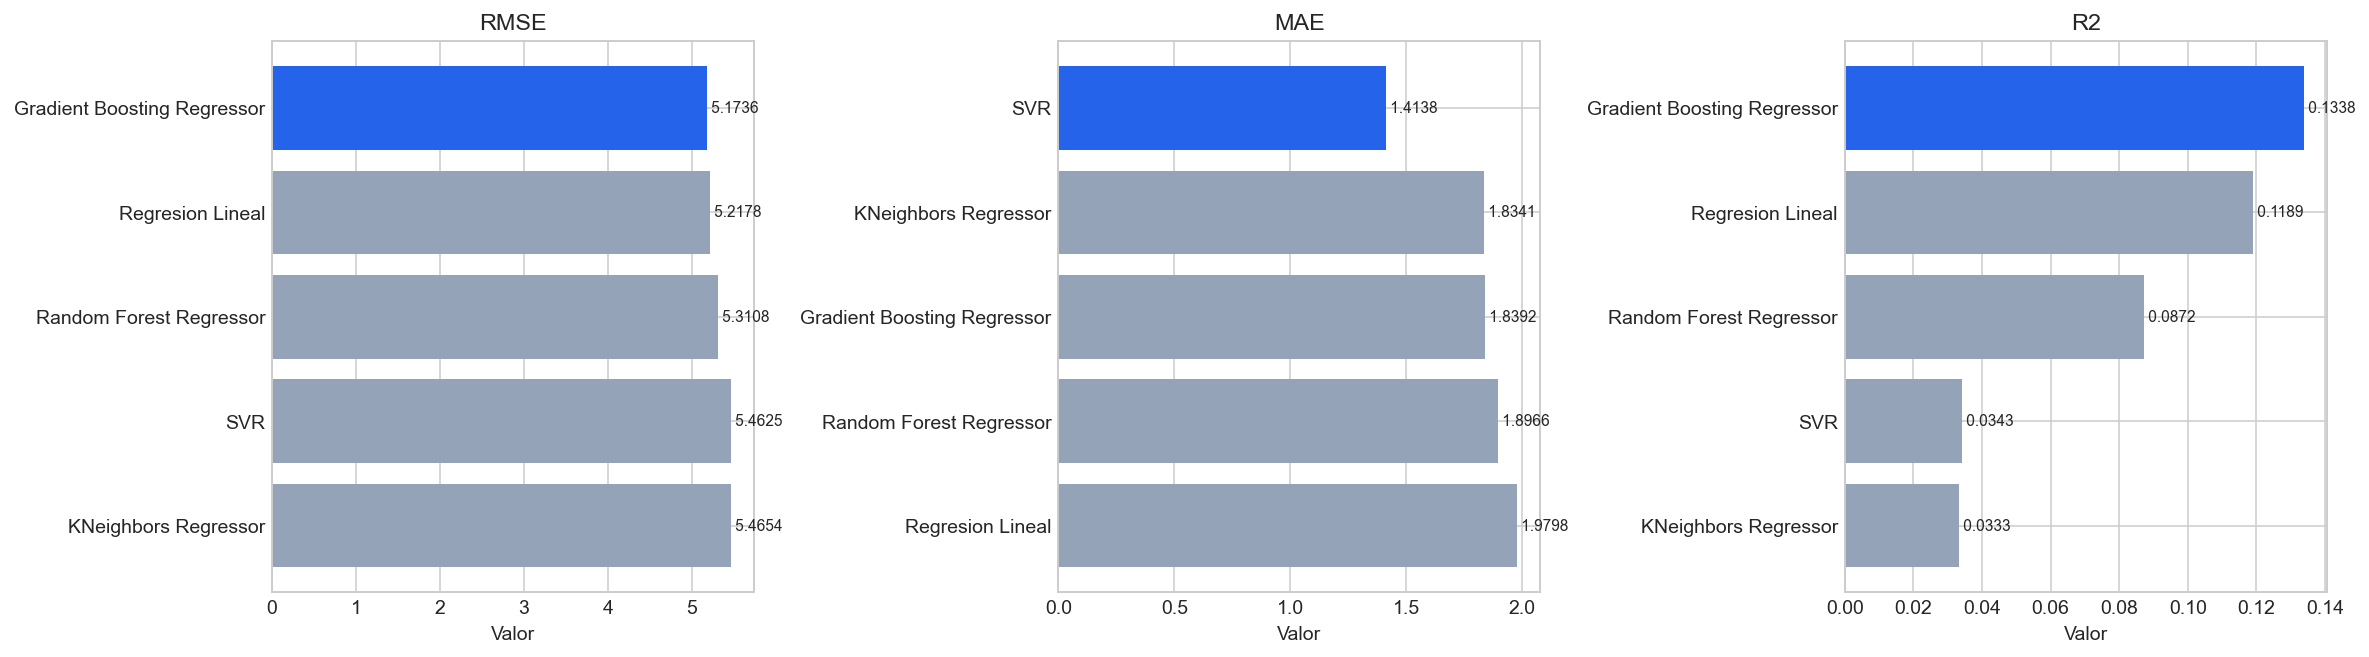

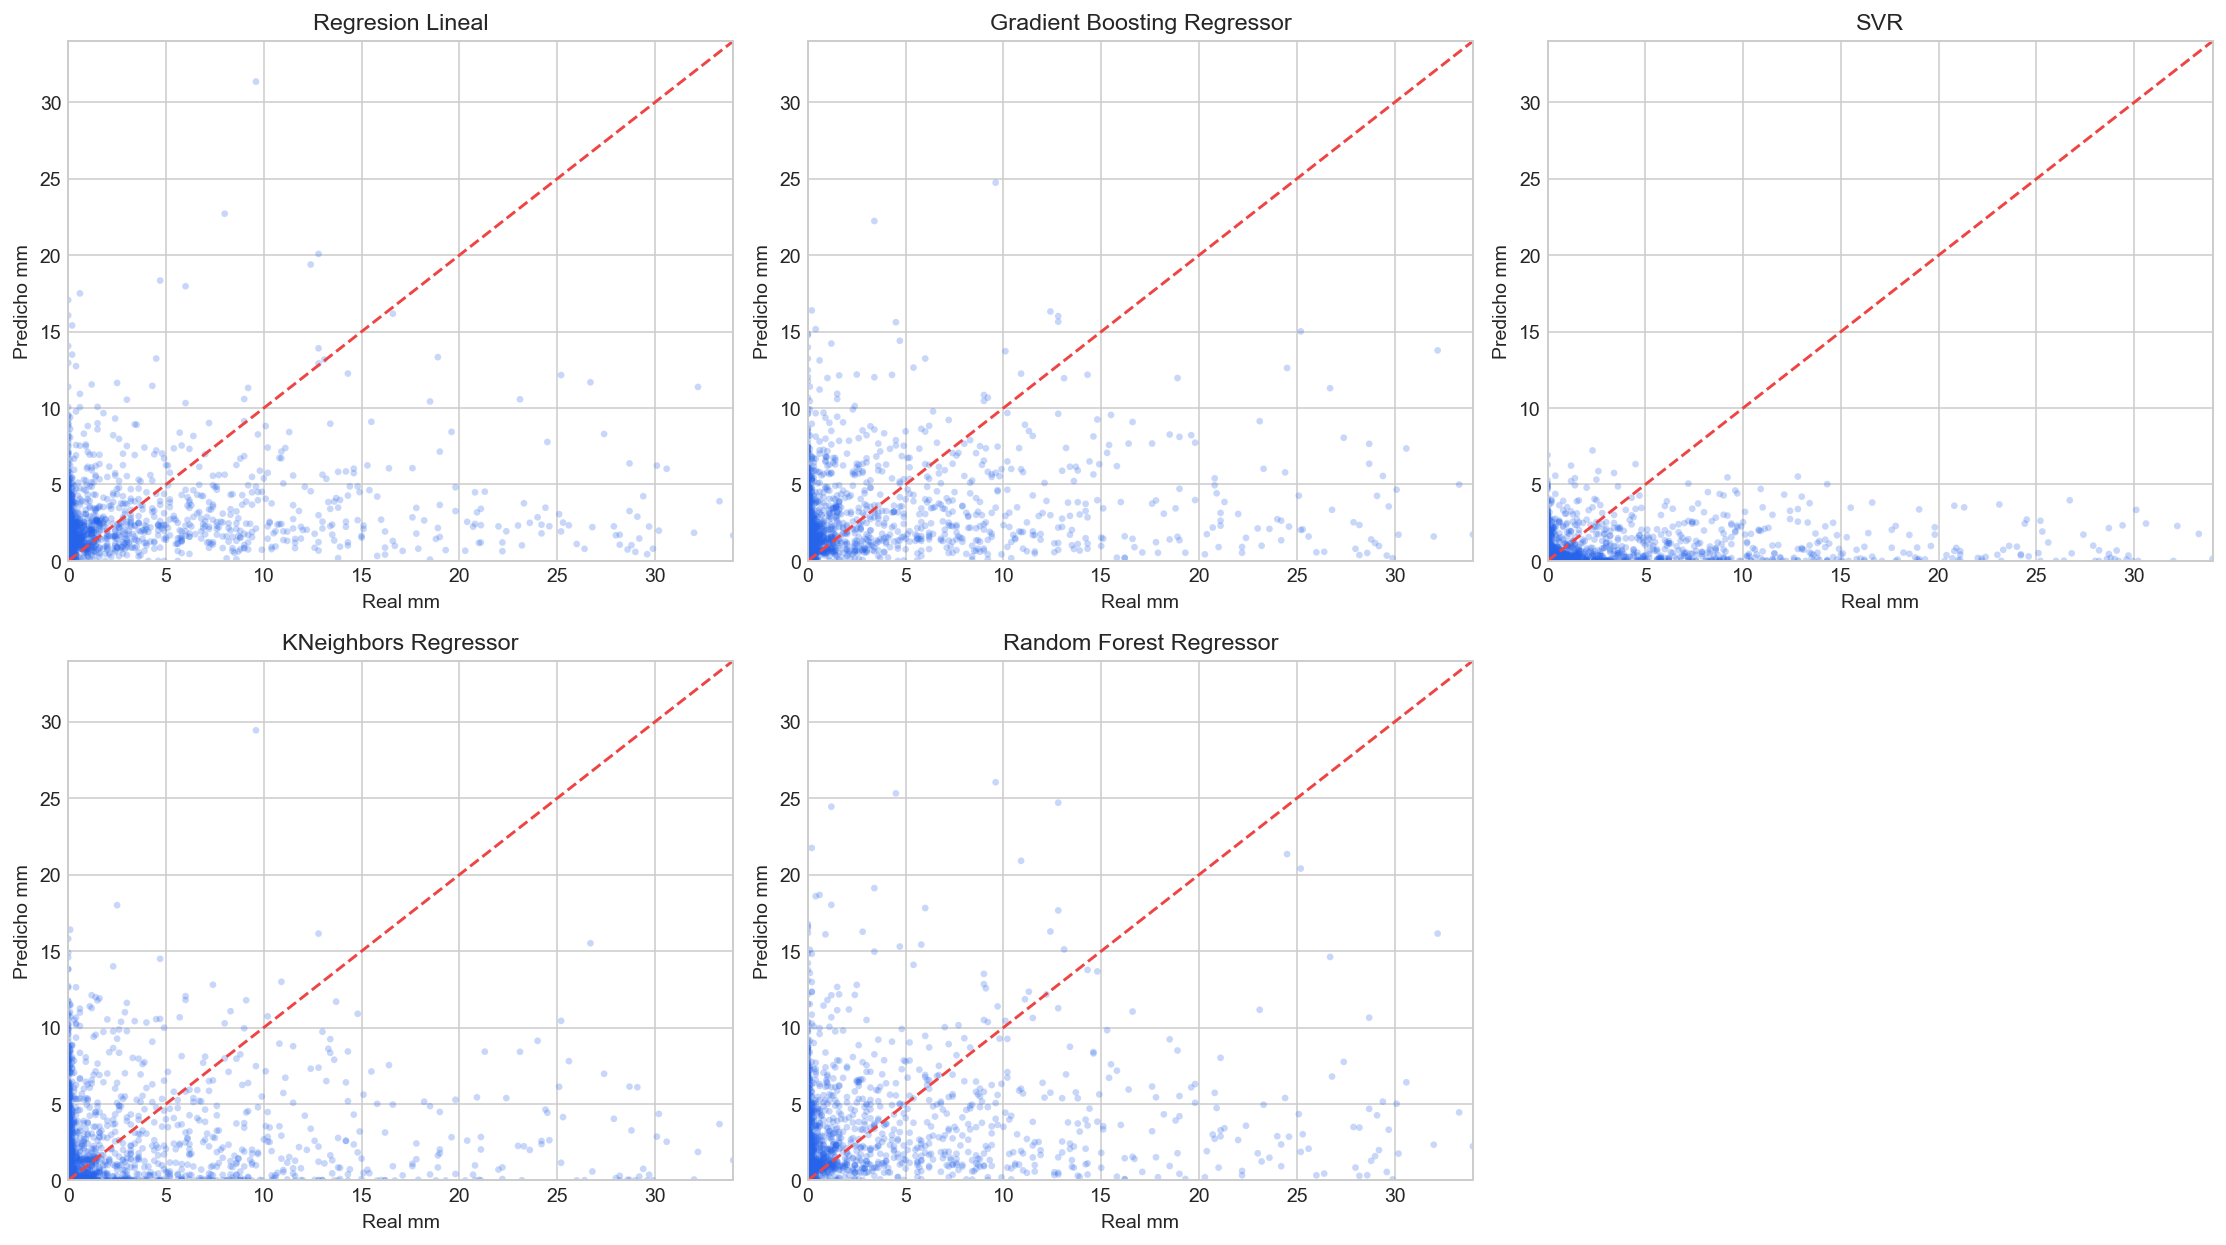

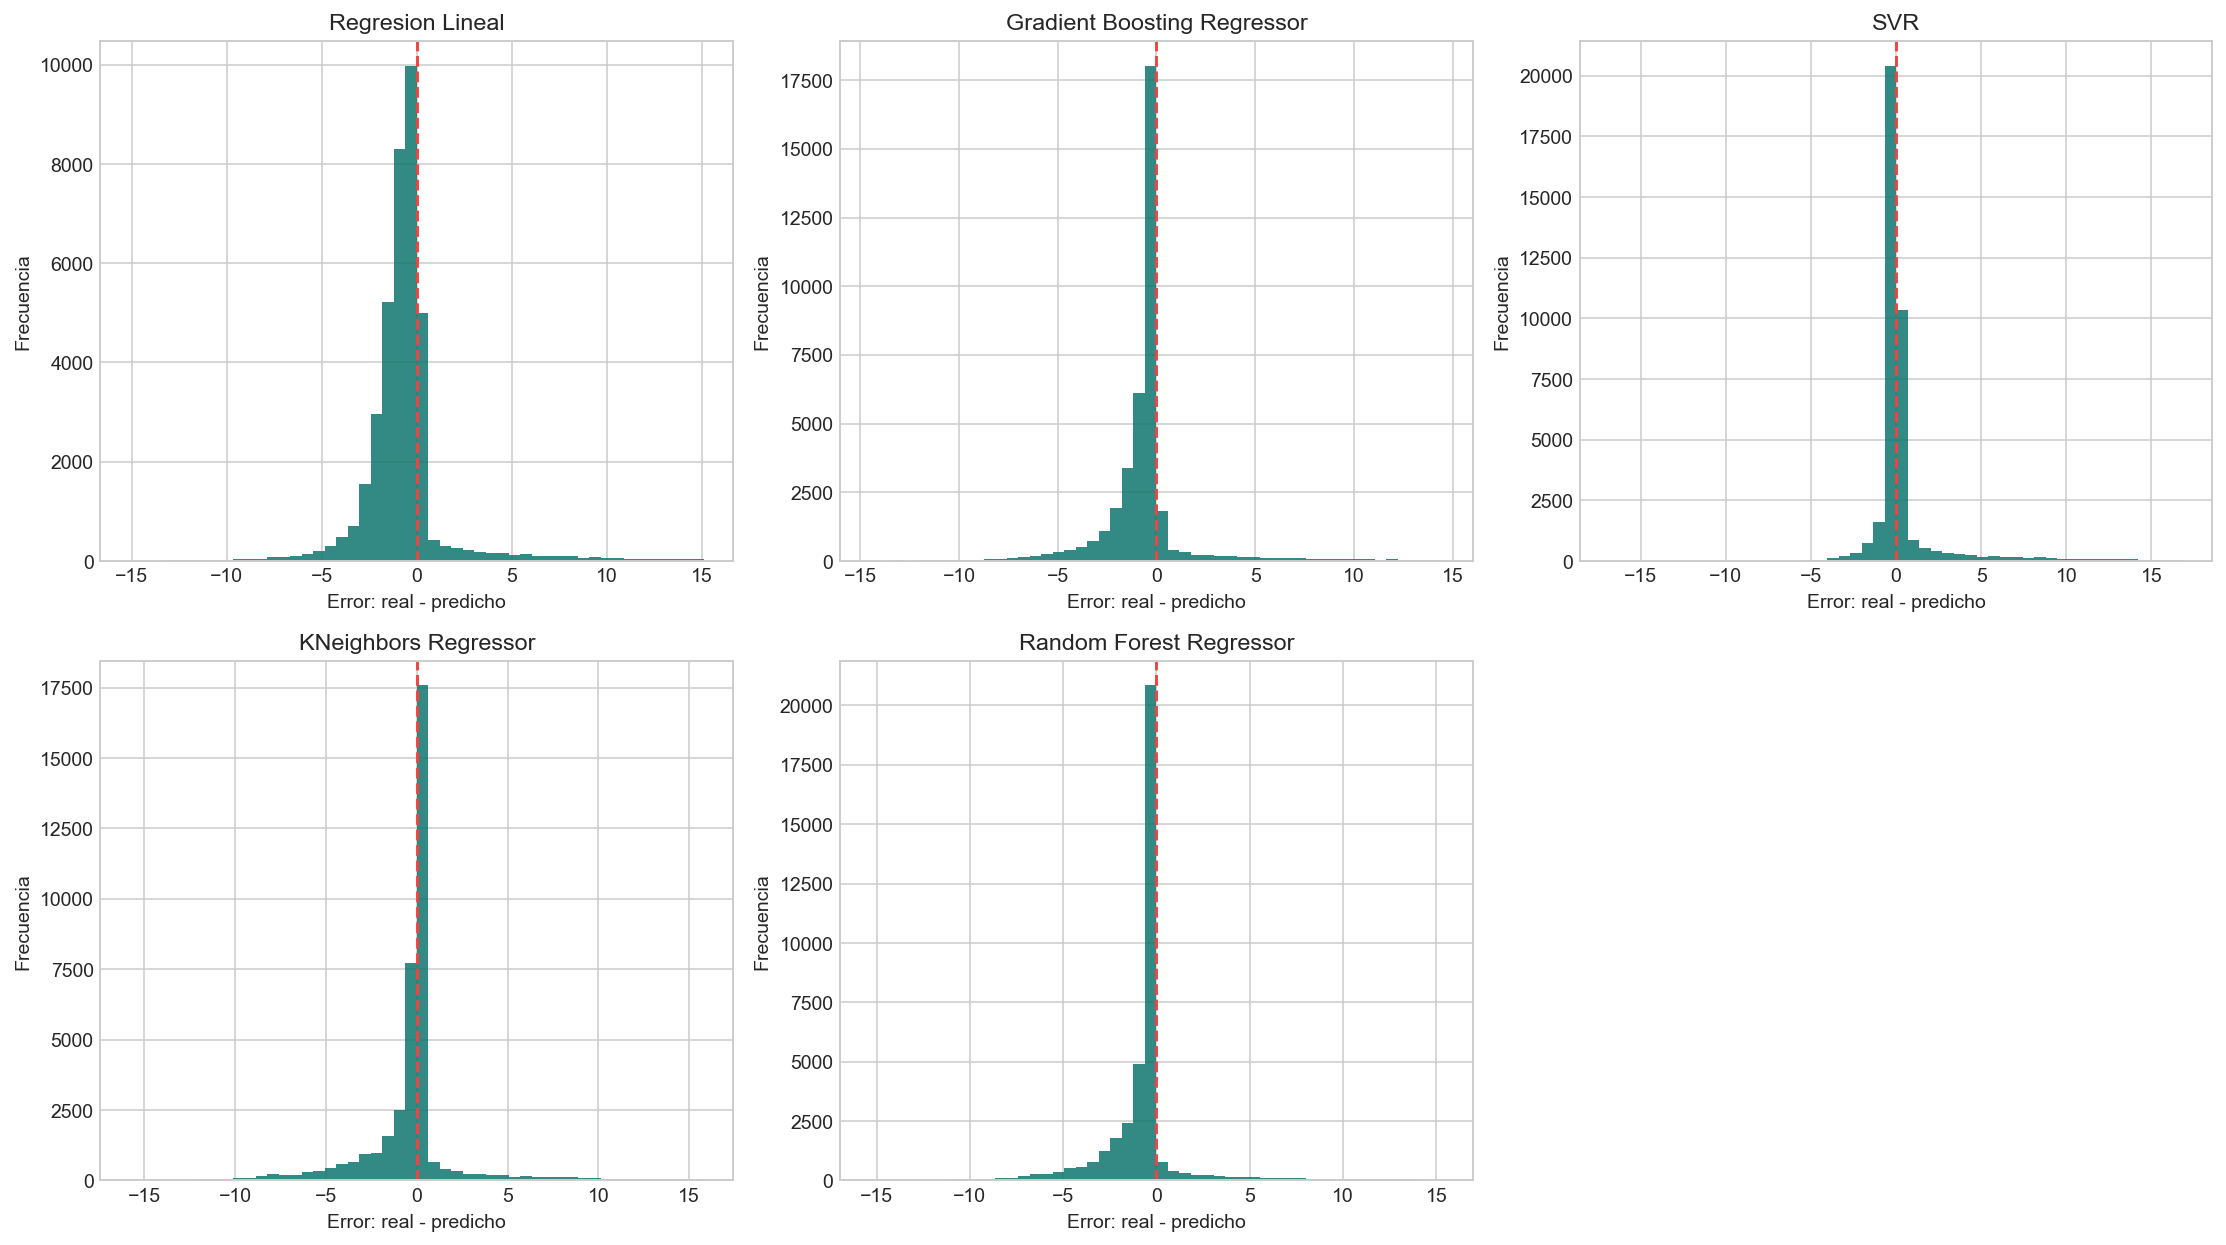

In [245]:

# Comparacion visual de metricas de regresion.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
metricas_regresion_plot = metricas_regresion.copy()

config_metricas_regresion = [
    ("rmse", "RMSE", True),
    ("mae", "MAE", True),
    ("r2", "R2", False),
]

for ax, (columna, titulo, ascendente) in zip(axes, config_metricas_regresion):
    datos = metricas_regresion_plot.sort_values(columna, ascending=ascendente)
    colores = ["#2563eb" if i == 0 else "#94a3b8" for i in range(len(datos))]
    ax.barh(datos["modelo"], datos[columna], color=colores)
    ax.set_title(titulo)
    ax.set_xlabel("Valor")
    ax.invert_yaxis()
    for indice, valor in enumerate(datos[columna]):
        ax.text(valor, indice, f" {valor:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Valores reales vs predichos por modelo.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

muestra_real_pred = y_test_regresion.sample(
    n=min(5000, len(y_test_regresion)),
    random_state=42,
).index
limite_real_pred = max(
    5,
    np.percentile(y_test_regresion.loc[muestra_real_pred], 99.5),
    max(np.percentile(predicciones_regresion[modelo][y_test_regresion.index.get_indexer(muestra_real_pred)], 99.5) for modelo in predicciones_regresion),
)

for ax, (nombre_modelo, prediccion) in zip(axes, predicciones_regresion.items()):
    posiciones = y_test_regresion.index.get_indexer(muestra_real_pred)
    reales = y_test_regresion.loc[muestra_real_pred].values
    predichos = prediccion[posiciones]
    ax.scatter(reales, predichos, s=12, alpha=0.25, color="#2563eb", edgecolors="none")
    ax.plot([0, limite_real_pred], [0, limite_real_pred], color="#ef4444", linewidth=1.5, linestyle="--")
    ax.set_xlim(0, limite_real_pred)
    ax.set_ylim(0, limite_real_pred)
    ax.set_title(nombre_modelo)
    ax.set_xlabel("Real mm")
    ax.set_ylabel("Predicho mm")

for ax in axes[len(predicciones_regresion):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Distribucion de errores por modelo.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (nombre_modelo, prediccion) in zip(axes, predicciones_regresion.items()):
    errores = y_test_regresion.values - prediccion
    limite_error = np.percentile(np.abs(errores), 98)
    limite_error = max(1, limite_error)
    ax.hist(errores, bins=50, range=(-limite_error, limite_error), color="#0f766e", alpha=0.85)
    ax.axvline(0, color="#ef4444", linewidth=1.5, linestyle="--")
    ax.set_title(nombre_modelo)
    ax.set_xlabel("Error: real - predicho")
    ax.set_ylabel("Frecuencia")

for ax in axes[len(predicciones_regresion):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


##### Analisis de resultados de regresion

El problema de regresion busca estimar la magnitud diaria de `agua_caida_tratada` en milimetros. La primera lectura importante viene de la propia distribucion del objetivo: la mediana es `0.0` tanto en entrenamiento como en prueba, mientras que la media se mantiene cerca de `1.3` mm. Esto confirma que la variable esta fuertemente concentrada en dias sin precipitacion o con lluvia muy baja, y que unos pocos eventos de mayor intensidad elevan el promedio. Ademas, el maximo observado en entrenamiento llega a `150.2` mm y en prueba a `120.0` mm, lo que muestra que el modelo debe enfrentar una distribucion asimetrica, con eventos extremos poco frecuentes.

Al comparar los modelos, `GradientBoostingRegressor` obtiene el mejor desempeno general en `RMSE` (`5.1736`) y tambien el mayor `R2` (`0.1338`). Esto indica que el modelo de boosting captura mejor algunas relaciones no lineales entre estacionalidad, ubicacion, zona climatica y rezagos de lluvia. Sin embargo, el `R2` sigue siendo bajo, por lo que la capacidad explicativa todavia es limitada. En terminos practicos, el modelo mejora respecto de alternativas mas simples, pero no logra explicar gran parte de la variabilidad diaria de la precipitacion.

La `Regresion Lineal` queda en segundo lugar por `RMSE` (`5.2178`) y presenta un `R2` de `0.1189`. Este resultado es relevante porque muestra que las variables construidas en fases anteriores si contienen senal predictiva basica. Aun asi, al ser un modelo lineal, le cuesta representar interacciones mas complejas entre territorio, epoca del ano y lluvia previa.

`RandomForestRegressor` obtiene un `RMSE` de `5.3108` y un `R2` de `0.0872`. Aunque suele ser un modelo fuerte para datos tabulares, en este caso queda por debajo de Gradient Boosting y de la regresion lineal. Esto puede deberse a que la configuracion elegida prioriza controlar la profundidad de los arboles y evitar sobreajuste, pero tambien puede limitar la captura de eventos de lluvia mas intensos.

`SVR` y `KNeighborsRegressor` fueron entrenados con una muestra reproducible de `5000` registros por costo computacional. Por eso sus resultados deben interpretarse con cautela frente a los modelos entrenados con todo el conjunto. `SVR` obtiene el menor `MAE` (`1.4138`), lo que sugiere que comete errores bajos en muchos casos comunes, probablemente cercanos a cero. Sin embargo, su `RMSE` (`5.4625`) y su `R2` (`0.0343`) son peores, lo que indica dificultad para capturar lluvias mas altas. `KNeighborsRegressor` presenta un comportamiento similar, con `RMSE` de `5.4654` y `R2` de `0.0333`.

En sintesis, para regresion el mejor candidato inicial es `GradientBoostingRegressor`, especialmente si se prioriza reducir errores grandes medidos por `RMSE`. No obstante, los resultados muestran que predecir exactamente los milimetros de lluvia diaria es un problema complejo con la informacion disponible. Una mejora natural para la fase de evaluacion seria revisar errores por zona climatica y separar el problema en dos etapas: primero detectar si llueve y luego estimar cuantos milimetros caen solo en los dias con lluvia.


#### 4.1.2 Modelos de clasificacion

##### Seleccion de variables (X/Y)

Para clasificacion, la variable objetivo se transforma en una etiqueta binaria: `1` para dias con lluvia y `0` para dias sin lluvia. Las variables predictoras son las mismas matrices `X_train` y `X_test` de la fase 3.


In [234]:
# Variable objetivo binaria para clasificacion: 1 = dia con lluvia, 0 = dia sin lluvia.
umbral_lluvia_clasificacion = 0

y_train_clasificacion = (
    df_modelado.loc[train_mask, variable_objetivo] > umbral_lluvia_clasificacion
).astype(int)
y_test_clasificacion = (
    df_modelado.loc[test_mask, variable_objetivo] > umbral_lluvia_clasificacion
).astype(int)

resumen_y_clasificacion = pd.DataFrame(
    {
        "bloque": ["train", "test"],
        "filas": [len(y_train_clasificacion), len(y_test_clasificacion)],
        "dias_sin_lluvia": [
            int((y_train_clasificacion == 0).sum()),
            int((y_test_clasificacion == 0).sum()),
        ],
        "dias_con_lluvia": [
            int((y_train_clasificacion == 1).sum()),
            int((y_test_clasificacion == 1).sum()),
        ],
        "pct_con_lluvia": [
            round((y_train_clasificacion == 1).mean() * 100, 2),
            round((y_test_clasificacion == 1).mean() * 100, 2),
        ],
    }
)

display(resumen_y_clasificacion)


,bloque,filas,dias_sin_lluvia,dias_con_lluvia,pct_con_lluvia
0,train,148828,110535,38293,25.73
1,test,39048,28649,10399,26.63


##### Seleccion de parametros

Los modelos seleccionados para clasificacion son regresion logistica, Random Forest Classifier y Support Vector Machine. Se utiliza `class_weight="balanced"` porque la base contiene mas dias sin lluvia que dias con lluvia. Para SVM se usa `LinearSVC`, una implementacion lineal mas adecuada para el volumen de registros disponible.


In [235]:
parametros_modelos_clasificacion = pd.DataFrame(
    [
        {
            "modelo": "Regresion Logistica",
            "clase_sklearn": "LogisticRegression",
            "parametros_principales": "max_iter=1000, class_weight=balanced",
        },
        {
            "modelo": "Random Forest Classifier",
            "clase_sklearn": "RandomForestClassifier",
            "parametros_principales": "n_estimators=200, max_depth=12, min_samples_leaf=5, class_weight=balanced",
        },
        {
            "modelo": "Support Vector Machine",
            "clase_sklearn": "LinearSVC",
            "parametros_principales": "C=1.0, max_iter=10000, class_weight=balanced",
        },
    ]
)

display(parametros_modelos_clasificacion)


,modelo,clase_sklearn,parametros_principales
0,Regresion Logistica,LogisticRegression,"max_iter=1000, class_weight=balanced"
1,Random Forest Classifier,RandomForestClassifier,"n_estimators=200, max_depth=12, min_samples_leaf=5, class_weight=balanced"
2,Support Vector Machine,LinearSVC,"C=1.0, max_iter=10000, class_weight=balanced"


##### Aplicacion de modelos y obtencion de metricas

Cada modelo se entrena exclusivamente con `X_train` y `y_train_clasificacion`. Luego se predice sobre `X_test`. Las metricas utilizadas son `accuracy`, `precision`, `recall` y `f1-score`, calculadas sobre la clase positiva: dias con lluvia.


In [236]:
modelos_clasificacion = {
    "Regresion Logistica": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    ),
    "Support Vector Machine": LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=10000,
        dual=False,
        random_state=42,
    ),
}

resultados_clasificacion = []
predicciones_clasificacion = {}

for nombre_modelo, modelo in modelos_clasificacion.items():
    modelo.fit(X_train, y_train_clasificacion)
    y_pred = modelo.predict(X_test)
    predicciones_clasificacion[nombre_modelo] = y_pred

    resultados_clasificacion.append(
        {
            "modelo": nombre_modelo,
            "accuracy": round(accuracy_score(y_test_clasificacion, y_pred), 4),
            "precision": round(precision_score(y_test_clasificacion, y_pred, zero_division=0), 4),
            "recall": round(recall_score(y_test_clasificacion, y_pred, zero_division=0), 4),
            "f1_score": round(f1_score(y_test_clasificacion, y_pred, zero_division=0), 4),
        }
    )

metricas_clasificacion = pd.DataFrame(resultados_clasificacion).sort_values(
    by="f1_score", ascending=False
)

display(metricas_clasificacion)


,modelo,accuracy,precision,recall,f1_score
1,Random Forest Classifier,0.7811,0.5609,0.8198,0.6661
0,Regresion Logistica,0.7486,0.5190,0.7621,0.6175
2,Support Vector Machine,0.7488,0.5195,0.7558,0.6158


##### Graficos de resultados de clasificacion

Estos graficos muestran la comparacion de metricas entre modelos y la distribucion de clases predichas. La matriz de confusion se deja para la Fase 5, donde corresponde evaluar con mayor profundidad falsos positivos y falsos negativos.


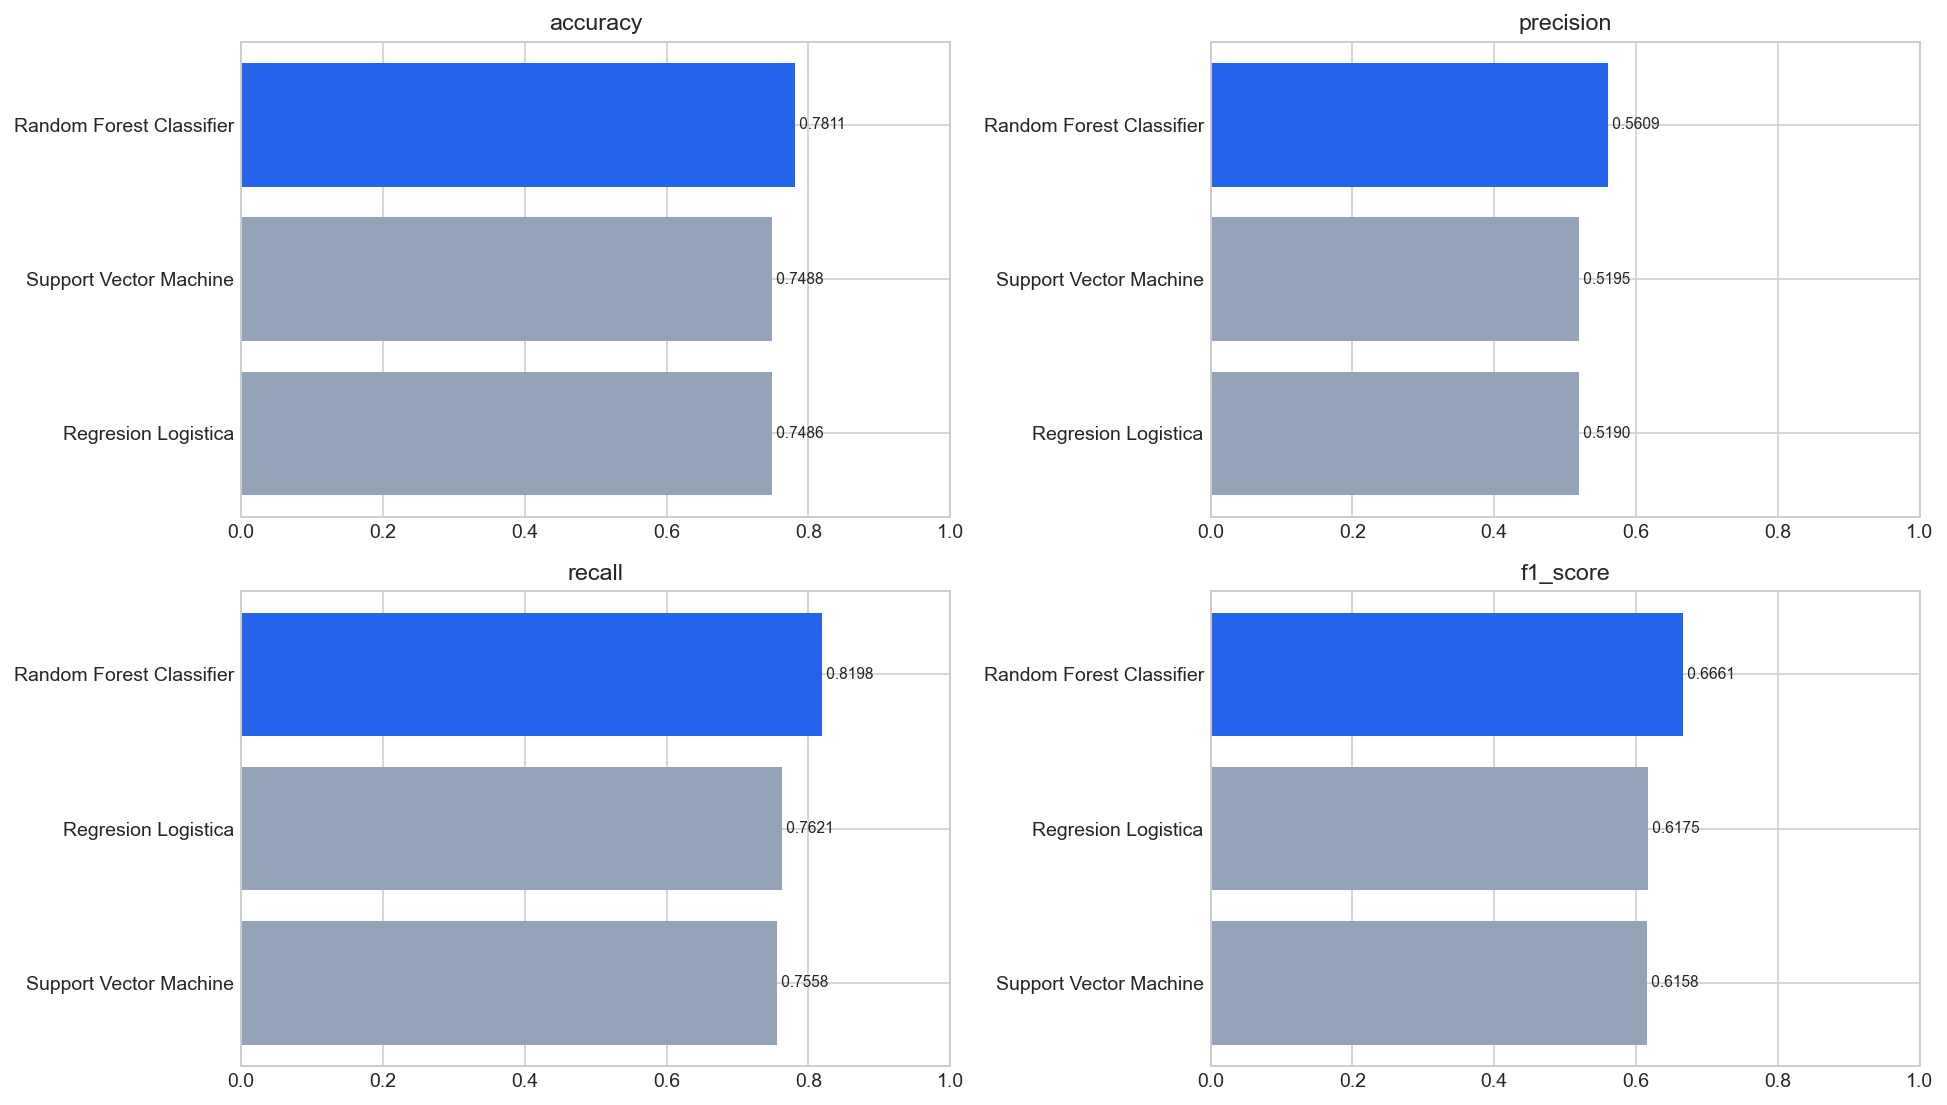

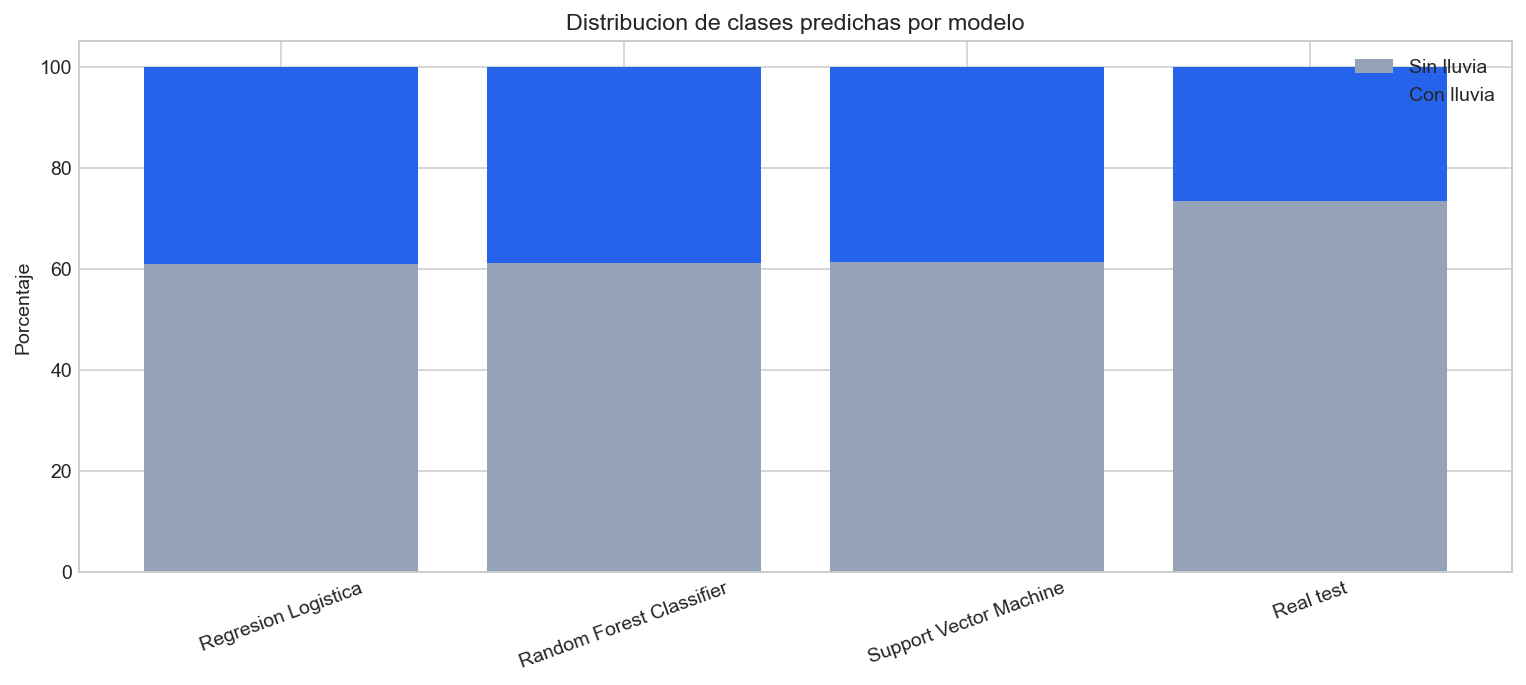

,modelo,sin_lluvia_predicho,con_lluvia_predicho
0,Regresion Logistica,60.90,39.10
1,Random Forest Classifier,61.08,38.92
2,Support Vector Machine,61.25,38.75
3,Real test,73.37,26.63


In [246]:

# Comparacion visual de metricas de clasificacion.
metricas_clasificacion_plot = metricas_clasificacion.copy()
metricas_clasificacion_largo = metricas_clasificacion_plot.melt(
    id_vars="modelo",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metrica",
    value_name="valor",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, metrica in zip(axes, ["accuracy", "precision", "recall", "f1_score"]):
    datos = metricas_clasificacion_plot.sort_values(metrica, ascending=False)
    colores = ["#2563eb" if i == 0 else "#94a3b8" for i in range(len(datos))]
    ax.barh(datos["modelo"], datos[metrica], color=colores)
    ax.set_title(metrica)
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    for indice, valor in enumerate(datos[metrica]):
        ax.text(valor, indice, f" {valor:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Distribucion de clases reales y predichas por modelo.
distribucion_predicciones = []
for nombre_modelo, prediccion in predicciones_clasificacion.items():
    conteo = pd.Series(prediccion).value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100
    distribucion_predicciones.append({
        "modelo": nombre_modelo,
        "sin_lluvia_predicho": conteo.loc[0],
        "con_lluvia_predicho": conteo.loc[1],
    })

conteo_real = y_test_clasificacion.value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100
distribucion_predicciones.append({
    "modelo": "Real test",
    "sin_lluvia_predicho": conteo_real.loc[0],
    "con_lluvia_predicho": conteo_real.loc[1],
})

distribucion_predicciones = pd.DataFrame(distribucion_predicciones)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    distribucion_predicciones["modelo"],
    distribucion_predicciones["sin_lluvia_predicho"],
    label="Sin lluvia",
    color="#94a3b8",
)
ax.bar(
    distribucion_predicciones["modelo"],
    distribucion_predicciones["con_lluvia_predicho"],
    bottom=distribucion_predicciones["sin_lluvia_predicho"],
    label="Con lluvia",
    color="#2563eb",
)
ax.set_ylabel("Porcentaje")
ax.set_title("Distribucion de clases predichas por modelo")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

display(distribucion_predicciones.round(2))


##### Analisis de resultados de clasificacion

El problema de clasificacion transforma `agua_caida_tratada` en una variable binaria: `0` para dias sin lluvia y `1` para dias con lluvia. La distribucion de clases confirma que existe desbalance: en entrenamiento hay `38,293` dias con lluvia de `148,828` registros, equivalentes al `25.73%`; en prueba hay `10,399` dias con lluvia de `39,048` registros, equivalentes al `26.63%`. Esto significa que cerca de tres cuartos de los registros corresponden a dias sin lluvia, por lo que `accuracy` por si sola no es suficiente para evaluar el modelo.

`RandomForestClassifier` obtiene el mejor resultado global, con `accuracy` de `0.7811`, `precision` de `0.5609`, `recall` de `0.8198` y `f1-score` de `0.6661`. El valor mas relevante es el `recall`, porque indica que el modelo detecta una alta proporcion de los dias con lluvia. Para este caso, eso es importante porque un falso negativo equivale a clasificar un dia lluvioso como seco.

La `precision` de Random Forest es mas moderada (`0.5609`), lo que indica que una parte de los dias predichos como lluviosos realmente no tuvieron lluvia. En otras palabras, el modelo tiende a capturar muchos eventos de lluvia, pero paga ese beneficio con falsos positivos. Esta relacion es razonable en una base desbalanceada y debe interpretarse segun el objetivo del negocio: si interesa no perder eventos de lluvia, conviene privilegiar `recall`; si interesa evitar falsas alarmas, habria que exigir mayor `precision`.

La `Regresion Logistica` obtiene `accuracy` de `0.7486`, `precision` de `0.5190`, `recall` de `0.7621` y `f1-score` de `0.6175`. Su desempeno es inferior al de Random Forest, pero sigue siendo util como referencia interpretable. Al ser un modelo lineal, permite comprobar que las variables temporales, geograficas y de rezago contienen informacion para separar dias con lluvia y sin lluvia, aunque no capture tan bien relaciones no lineales.

`Support Vector Machine`, implementado con `LinearSVC`, logra resultados muy parecidos a la regresion logistica: `accuracy` de `0.7488`, `precision` de `0.5195`, `recall` de `0.7558` y `f1-score` de `0.6158`. Esta similitud sugiere que, bajo una frontera lineal, ambos modelos encuentran una separacion comparable entre clases. La ventaja de `LinearSVC` es que aplica el enfoque de margen de separacion de SVM de forma viable para una base grande.

En sintesis, para clasificacion el mejor candidato inicial es `RandomForestClassifier`, ya que consigue el mayor `f1-score` y el mayor `recall`. Esto muestra que los patrones no lineales entre ubicacion, estacion del ano, zona climatica y lluvia previa son importantes para detectar dias con precipitacion. Para la fase de evaluacion, conviene complementar estas metricas con matriz de confusion, porque permitira observar directamente cuantos falsos positivos y falsos negativos produce cada modelo.


### 4.2 Aprendizaje no supervisado

El aprendizaje no supervisado no utiliza una variable objetivo `Y`. En esta seccion se aplica clustering para encontrar grupos de estaciones con caracteristicas geograficas y pluviometricas similares.


#### 4.2.1 Modelos de cluster / agrupacion

##### Seleccion de variables (X)

Para que la agrupacion sea interpretable, el clustering se realiza a nivel de estacion meteorologica y no a nivel de cada registro diario. Las variables `X` combinan ubicacion, altura, zona climatica y resumenes historicos de precipitacion.


In [ ]:
agregaciones_cluster_estaciones = {
    "dias_observados": (variable_objetivo, "size"),
    "lluvia_media": (variable_objetivo, "mean"),
    "lluvia_mediana": (variable_objetivo, "median"),
    "lluvia_p95": (variable_objetivo, lambda serie: serie.quantile(0.95)),
    "lluvia_maxima": (variable_objetivo, "max"),
    "pct_dias_lluvia": (variable_objetivo, lambda serie: (serie > 0).mean() * 100),
    "pct_dias_lluvia_fuerte": (variable_objetivo, lambda serie: (serie >= 10).mean() * 100),
}
if "temp_media" in df_modelado.columns:
    agregaciones_cluster_estaciones["temp_media_promedio"] = ("temp_media", "mean")
if "temp_min" in df_modelado.columns:
    agregaciones_cluster_estaciones["temp_min_promedio"] = ("temp_min", "mean")
if "temp_max" in df_modelado.columns:
    agregaciones_cluster_estaciones["temp_max_promedio"] = ("temp_max", "mean")
if "temp_amplitud" in df_modelado.columns:
    agregaciones_cluster_estaciones["temp_amplitud_promedio"] = ("temp_amplitud", "mean")

df_cluster_estaciones = (
    df_modelado.groupby(
        [
            "codigo_estacion", "nombre_estacion", "nombre_region", "macrozona",
            "zona_climatica", "zona_geografica", "altura", "latitud", "longitud",
        ],
        dropna=False,
    )
    .agg(**agregaciones_cluster_estaciones)
    .reset_index()
)

columnas_cluster_numericas = [
    "altura", "latitud", "longitud", "lluvia_media", "lluvia_mediana",
    "lluvia_p95", "lluvia_maxima", "pct_dias_lluvia", "pct_dias_lluvia_fuerte",
] + [
    col for col in [
        "temp_media_promedio", "temp_min_promedio", "temp_max_promedio", "temp_amplitud_promedio",
    ] if col in df_cluster_estaciones.columns
]
columnas_cluster_categoricas = ["macrozona", "zona_climatica", "zona_geografica"]

X_cluster_num = df_cluster_estaciones[columnas_cluster_numericas].fillna(
    df_cluster_estaciones[columnas_cluster_numericas].median()
)
X_cluster_cat = pd.get_dummies(
    df_cluster_estaciones[columnas_cluster_categoricas],
    columns=columnas_cluster_categoricas,
    dtype=int,
    drop_first=True,
)
X_cluster_base = pd.concat([X_cluster_num, X_cluster_cat], axis=1)

escalador_cluster = StandardScaler()
X_cluster = pd.DataFrame(
    escalador_cluster.fit_transform(X_cluster_base),
    columns=X_cluster_base.columns,
    index=df_cluster_estaciones.index,
)

resumen_cluster_variables = pd.DataFrame(
    {
        "objeto": ["df_cluster_estaciones", "X_cluster"],
        "filas": [df_cluster_estaciones.shape[0], X_cluster.shape[0]],
        "columnas": [df_cluster_estaciones.shape[1], X_cluster.shape[1]],
        "nulos": [
            int(df_cluster_estaciones.isna().sum().sum()),
            int(X_cluster.isna().sum().sum()),
        ],
        "variables_termicas_incluidas": [
            len([col for col in columnas_cluster_numericas if col.startswith("temp_")]),
            len([col for col in X_cluster.columns if col.startswith("temp_")]),
        ],
    }
)

display(resumen_cluster_variables)
display(df_cluster_estaciones.head())


##### Seleccion de parametros

Se comparan cuatro modelos de agrupacion: `KMeans`, `AgglomerativeClustering`, `DBSCAN` y `GaussianMixture`. `KMeans`, `AgglomerativeClustering` y `GaussianMixture` requieren definir un numero de grupos, por lo que se prueban valores de `k` entre 2 y 6. Para `DBSCAN` se prueban combinaciones de `eps` y `min_samples`, ya que este modelo forma grupos por densidad y tambien puede marcar estaciones como ruido. Las metricas utilizadas son `silhouette`, `davies_bouldin` y `calinski_harabasz`; ademas, para modelos especificos se conserva `inertia`, `AIC`, `BIC` o porcentaje de ruido cuando corresponde.


In [243]:
def evaluar_etiquetas_cluster(X, etiquetas):
    etiquetas = np.asarray(etiquetas)
    mascara_valida = etiquetas != -1
    etiquetas_validas = etiquetas[mascara_valida]
    X_valido = X.loc[mascara_valida] if hasattr(X, "loc") else X[mascara_valida]
    n_clusters = len(np.unique(etiquetas_validas))

    if n_clusters < 2 or len(etiquetas_validas) <= n_clusters:
        return {
            "clusters": n_clusters,
            "ruido": int((etiquetas == -1).sum()),
            "pct_ruido": round((etiquetas == -1).mean() * 100, 2),
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    return {
        "clusters": n_clusters,
        "ruido": int((etiquetas == -1).sum()),
        "pct_ruido": round((etiquetas == -1).mean() * 100, 2),
        "silhouette": round(silhouette_score(X_valido, etiquetas_validas), 4),
        "davies_bouldin": round(davies_bouldin_score(X_valido, etiquetas_validas), 4),
        "calinski_harabasz": round(calinski_harabasz_score(X_valido, etiquetas_validas), 4),
    }

resultados_cluster_parametros = []
max_k = min(6, len(X_cluster) - 1)

for k in range(2, max_k + 1):
    modelo_kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    etiquetas = modelo_kmeans.fit_predict(X_cluster)
    metricas = evaluar_etiquetas_cluster(X_cluster, etiquetas)
    resultados_cluster_parametros.append(
        {
            "modelo": "KMeans",
            "parametros": f"k={k}",
            "inertia": round(modelo_kmeans.inertia_, 2),
            "aic": np.nan,
            "bic": np.nan,
            **metricas,
        }
    )

for k in range(2, max_k + 1):
    modelo_agglomerative = AgglomerativeClustering(n_clusters=k, linkage="ward")
    etiquetas = modelo_agglomerative.fit_predict(X_cluster)
    metricas = evaluar_etiquetas_cluster(X_cluster, etiquetas)
    resultados_cluster_parametros.append(
        {
            "modelo": "AgglomerativeClustering",
            "parametros": f"k={k}, linkage=ward",
            "inertia": np.nan,
            "aic": np.nan,
            "bic": np.nan,
            **metricas,
        }
    )

for k in range(2, max_k + 1):
    modelo_gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    etiquetas = modelo_gmm.fit_predict(X_cluster)
    metricas = evaluar_etiquetas_cluster(X_cluster, etiquetas)
    resultados_cluster_parametros.append(
        {
            "modelo": "GaussianMixture",
            "parametros": f"n_components={k}, covariance=full",
            "inertia": np.nan,
            "aic": round(modelo_gmm.aic(X_cluster), 2),
            "bic": round(modelo_gmm.bic(X_cluster), 2),
            **metricas,
        }
    )

for eps in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    for min_samples in [3, 5, 8]:
        modelo_dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        etiquetas = modelo_dbscan.fit_predict(X_cluster)
        metricas = evaluar_etiquetas_cluster(X_cluster, etiquetas)
        resultados_cluster_parametros.append(
            {
                "modelo": "DBSCAN",
                "parametros": f"eps={eps}, min_samples={min_samples}",
                "inertia": np.nan,
                "aic": np.nan,
                "bic": np.nan,
                **metricas,
            }
        )

metricas_cluster_parametros = pd.DataFrame(resultados_cluster_parametros)
metricas_cluster_validas = metricas_cluster_parametros.dropna(subset=["silhouette"]).copy()
metricas_cluster_modelos = (
    metricas_cluster_validas.sort_values(["modelo", "silhouette"], ascending=[True, False])
    .groupby("modelo", as_index=False)
    .head(1)
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)

display(metricas_cluster_parametros.sort_values(["modelo", "silhouette"], ascending=[True, False]).head(20))
display(metricas_cluster_modelos)


,modelo,parametros,inertia,aic,bic,clusters,ruido,pct_ruido,silhouette,davies_bouldin,calinski_harabasz
9,AgglomerativeClustering,"k=6, linkage=ward",None,None,None,6,0,0.0,0.3529,1.2647,21.9405
8,AgglomerativeClustering,"k=5, linkage=ward",None,None,None,5,0,0.0,0.3199,1.454,21.3503
7,AgglomerativeClustering,"k=4, linkage=ward",None,None,None,4,0,0.0,0.2831,1.6285,21.6102
6,AgglomerativeClustering,"k=3, linkage=ward",None,None,None,3,0,0.0,0.24,1.5669,23.9076
5,AgglomerativeClustering,"k=2, linkage=ward",None,None,None,2,0,0.0,0.2355,1.8718,26.381
17,DBSCAN,"eps=1.5, min_samples=8",None,None,None,3,74,67.89,0.838,0.2256,360.9775
20,DBSCAN,"eps=2.0, min_samples=8",None,None,None,4,61,55.96,0.7736,0.3132,177.9119
23,DBSCAN,"eps=2.5, min_samples=8",None,None,None,4,61,55.96,0.7736,0.3132,177.9119
16,DBSCAN,"eps=1.5, min_samples=5",None,None,None,8,42,38.53,0.7427,0.3294,189.6814
15,DBSCAN,"eps=1.5, min_samples=3",None,None,None,12,29,26.61,0.7332,0.3461,172.5206


,modelo,parametros,inertia,aic,bic,clusters,ruido,pct_ruido,silhouette,davies_bouldin,calinski_harabasz
0,DBSCAN,"eps=1.5, min_samples=8",None,None,None,3,74,67.89,0.838,0.2256,360.9775
1,AgglomerativeClustering,"k=6, linkage=ward",None,None,None,6,0,0.0,0.3529,1.2647,21.9405
2,GaussianMixture,"n_components=6, covariance=full",None,-13892.04,-7338.61,6,0,0.0,0.344,1.2752,21.7789
3,KMeans,k=6,1430.57,None,None,6,0,0.0,0.344,1.2752,21.7789


##### Aplicacion de modelos y obtencion de metricas

Con los mejores parametros encontrados para cada tecnica, se ajustan los cuatro modelos finales y se agregan sus etiquetas al dataframe de estaciones. Luego se construye una tabla interpretativa por modelo y cluster, usando cantidad de estaciones, lluvia promedio, frecuencia de dias con lluvia, altura, latitud, zona climatica dominante y, cuando esta disponible, temperatura promedio del grupo.


In [ ]:
def extraer_parametro_cluster(fila, nombre):
    partes = str(fila["parametros"]).split(",")
    for parte in partes:
        clave, valor = parte.strip().split("=")
        if clave == nombre:
            return float(valor) if "." in valor else int(valor)
    raise ValueError(f"Parametro {nombre} no encontrado en {fila['parametros']}.")

def obtener_mejor_fila(nombre_modelo):
    return metricas_cluster_modelos.loc[
        metricas_cluster_modelos["modelo"] == nombre_modelo
    ].iloc[0]

mejor_kmeans = obtener_mejor_fila("KMeans")
k_kmeans = int(extraer_parametro_cluster(mejor_kmeans, "k"))
df_cluster_estaciones["cluster_kmeans"] = KMeans(
    n_clusters=k_kmeans, n_init=20, random_state=42
).fit_predict(X_cluster)

mejor_agglomerative = obtener_mejor_fila("AgglomerativeClustering")
k_agglomerative = int(extraer_parametro_cluster(mejor_agglomerative, "k"))
df_cluster_estaciones["cluster_agglomerative"] = AgglomerativeClustering(
    n_clusters=k_agglomerative, linkage="ward"
).fit_predict(X_cluster)

mejor_gmm = obtener_mejor_fila("GaussianMixture")
k_gmm = int(extraer_parametro_cluster(mejor_gmm, "n_components"))
df_cluster_estaciones["cluster_gaussian_mixture"] = GaussianMixture(
    n_components=k_gmm, covariance_type="full", random_state=42
).fit_predict(X_cluster)

mejor_dbscan = obtener_mejor_fila("DBSCAN")
eps_dbscan = float(extraer_parametro_cluster(mejor_dbscan, "eps"))
min_samples_dbscan = int(extraer_parametro_cluster(mejor_dbscan, "min_samples"))
df_cluster_estaciones["cluster_dbscan"] = DBSCAN(
    eps=eps_dbscan, min_samples=min_samples_dbscan
).fit_predict(X_cluster)

def moda_segura(serie):
    moda = serie.mode(dropna=True)
    return moda.iloc[0] if not moda.empty else "Sin dato"

columnas_clusters_modelos = {
    "KMeans": "cluster_kmeans",
    "AgglomerativeClustering": "cluster_agglomerative",
    "DBSCAN": "cluster_dbscan",
    "GaussianMixture": "cluster_gaussian_mixture",
}

resumen_clusters_modelos = []
for nombre_modelo, columna_cluster in columnas_clusters_modelos.items():
    agregaciones_resumen_cluster = {
        "estaciones": ("codigo_estacion", "count"),
        "lluvia_media_promedio": ("lluvia_media", "mean"),
        "pct_dias_lluvia_promedio": ("pct_dias_lluvia", "mean"),
        "altura_promedio": ("altura", "mean"),
        "latitud_promedio": ("latitud", "mean"),
        "zona_climatica_dominante": ("zona_climatica", moda_segura),
        "macrozona_dominante": ("macrozona", moda_segura),
    }
    if "temp_media_promedio" in df_cluster_estaciones.columns:
        agregaciones_resumen_cluster["temp_media_promedio"] = ("temp_media_promedio", "mean")
    if "temp_amplitud_promedio" in df_cluster_estaciones.columns:
        agregaciones_resumen_cluster["temp_amplitud_promedio"] = ("temp_amplitud_promedio", "mean")

    resumen_modelo = (
        df_cluster_estaciones.groupby(columna_cluster)
        .agg(**agregaciones_resumen_cluster)
        .round(3)
        .reset_index()
        .rename(columns={columna_cluster: "cluster"})
    )
    resumen_modelo.insert(0, "modelo", nombre_modelo)
    resumen_clusters_modelos.append(resumen_modelo)

resumen_clusters_modelos = pd.concat(resumen_clusters_modelos, ignore_index=True)

display(metricas_cluster_modelos)
display(resumen_clusters_modelos)


##### Graficos de resultados de clustering

Estos graficos comparan la calidad de agrupacion entre modelos, muestran el tamano de los clusters y ubican las estaciones sobre un mapa de Chile. Para el mapa principal se usa `AgglomerativeClustering`, porque entrega una segmentacion completa de las estaciones sin dejar observaciones como ruido. El mapa intenta cargar una silueta GeoJSON de Chile; si la base cartografica no esta disponible, mantiene igualmente la visualizacion por coordenadas de latitud y longitud.


In [ ]:
# Comparacion visual de metricas de clustering.
from pathlib import Path
from urllib.request import urlopen
from matplotlib.patches import Polygon

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
metricas_cluster_plot = metricas_cluster_modelos.copy()

config_metricas_cluster = [
    ("silhouette", "Silhouette", False),
    ("davies_bouldin", "Davies-Bouldin", True),
    ("calinski_harabasz", "Calinski-Harabasz", False),
]

for ax, (columna, titulo, ascendente) in zip(axes, config_metricas_cluster):
    datos = metricas_cluster_plot.sort_values(columna, ascending=ascendente)
    colores = ["#2563eb" if i == 0 else "#94a3b8" for i in range(len(datos))]
    ax.barh(datos["modelo"], datos[columna], color=colores)
    ax.set_title(titulo)
    ax.set_xlabel("Valor")
    ax.invert_yaxis()
    for indice, valor in enumerate(datos[columna]):
        ax.text(valor, indice, f" {valor:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Cantidad de estaciones por cluster para cada modelo.
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()
orden_modelos_cluster = ["KMeans", "AgglomerativeClustering", "DBSCAN", "GaussianMixture"]

for ax, nombre_modelo in zip(axes, orden_modelos_cluster):
    datos = resumen_clusters_modelos.loc[resumen_clusters_modelos["modelo"] == nombre_modelo].copy()
    datos["cluster_label"] = datos["cluster"].astype(str).replace({"-1": "Ruido"})
    colores = ["#ef4444" if etiqueta == "Ruido" else "#2563eb" for etiqueta in datos["cluster_label"]]
    ax.bar(datos["cluster_label"], datos["estaciones"], color=colores)
    ax.set_title(nombre_modelo)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Estaciones")

plt.tight_layout()
plt.show()

# Base cartografica liviana de Chile.
CHILE_GEOJSON_URL = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/CHL.geo.json"
CHILE_GEOJSON_LOCAL = Path(".data") / "chile_country.geojson"


def cargar_geojson_chile():
    try:
        if CHILE_GEOJSON_LOCAL.exists():
            with CHILE_GEOJSON_LOCAL.open("r", encoding="utf-8") as f:
                return json.load(f), "local"

        CHILE_GEOJSON_LOCAL.parent.mkdir(parents=True, exist_ok=True)
        with urlopen(CHILE_GEOJSON_URL, timeout=20) as response:
            geojson_data = json.loads(response.read().decode("utf-8"))
        with CHILE_GEOJSON_LOCAL.open("w", encoding="utf-8") as f:
            json.dump(geojson_data, f)
        return geojson_data, "descargado"
    except Exception as error:
        print(f"No se pudo cargar la base GeoJSON de Chile: {error}")
        return None, "no_disponible"


def extraer_poligonos_geojson(geojson_data):
    if geojson_data is None:
        return []

    features = geojson_data.get("features", [geojson_data])
    poligonos = []

    for feature in features:
        geometria = feature.get("geometry", feature)
        tipo = geometria.get("type")
        coordenadas = geometria.get("coordinates", [])

        if tipo == "Polygon":
            poligonos.extend(coordenadas)
        elif tipo == "MultiPolygon":
            for poligono in coordenadas:
                poligonos.extend(poligono)

    return poligonos


def dibujar_base_chile(ax, poligonos_chile):
    ax.set_facecolor("#e0f2fe")
    if poligonos_chile:
        for anillo in poligonos_chile:
            if len(anillo) < 3:
                continue
            patch = Polygon(
                anillo,
                closed=True,
                facecolor="#f8fafc",
                edgecolor="#64748b",
                linewidth=0.7,
                alpha=0.95,
                zorder=1,
            )
            ax.add_patch(patch)
    else:
        ax.text(
            0.5,
            0.5,
            "Base cartografica no disponible",
            transform=ax.transAxes,
            ha="center",
            va="center",
            color="#64748b",
            fontsize=9,
        )

    ax.set_xlim(-76.5, -66)
    ax.set_ylim(-56.8, -17)
    ax.grid(True, alpha=0.22, color="#94a3b8")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")


geojson_chile, origen_geojson_chile = cargar_geojson_chile()
poligonos_chile = extraer_poligonos_geojson(geojson_chile)
print(f"Base cartografica de Chile: {origen_geojson_chile}")

# Mapa principal de Chile: estaciones coloreadas por cluster.
columna_cluster_mapa = "cluster_agglomerative"
modelo_mapa = "AgglomerativeClustering"

datos_mapa = df_cluster_estaciones.copy()
datos_mapa["cluster_mapa"] = datos_mapa[columna_cluster_mapa].astype(str).replace({"-1": "Ruido"})

fig, ax = plt.subplots(figsize=(7.2, 10.5))
dibujar_base_chile(ax, poligonos_chile)

clusters_ordenados = sorted(
    datos_mapa["cluster_mapa"].unique(),
    key=lambda valor: 999 if valor == "Ruido" else int(valor),
)
colores = plt.cm.tab10(np.linspace(0, 1, max(len(clusters_ordenados), 3)))
color_por_cluster = dict(zip(clusters_ordenados, colores))
if "Ruido" in color_por_cluster:
    color_por_cluster["Ruido"] = "#ef4444"

for cluster in clusters_ordenados:
    subset = datos_mapa.loc[datos_mapa["cluster_mapa"] == cluster]
    ax.scatter(
        subset["longitud"],
        subset["latitud"],
        s=62,
        color=color_por_cluster[cluster],
        edgecolor="#0f172a",
        linewidth=0.45,
        alpha=0.92,
        label=f"Cluster {cluster}",
        zorder=3,
    )

centroides_cluster = (
    datos_mapa.groupby("cluster_mapa")
    .agg(longitud=("longitud", "mean"), latitud=("latitud", "mean"), estaciones=("codigo_estacion", "count"))
    .reset_index()
)
for _, row in centroides_cluster.iterrows():
    ax.text(
        row["longitud"],
        row["latitud"],
        str(row["cluster_mapa"]),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#0f172a",
        bbox={"boxstyle": "circle,pad=0.25", "facecolor": "white", "edgecolor": "#0f172a", "linewidth": 0.6},
        zorder=4,
    )

ax.set_title(f"Mapa de Chile por cluster: {modelo_mapa}")
ax.legend(title="Agrupacion", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

resumen_mapa_cluster = (
    datos_mapa.groupby("cluster_mapa")
    .agg(
        estaciones=("codigo_estacion", "count"),
        latitud_media=("latitud", "mean"),
        longitud_media=("longitud", "mean"),
        lluvia_media=("lluvia_media", "mean"),
        temp_media=("temp_media_promedio", "mean") if "temp_media_promedio" in datos_mapa.columns else ("lluvia_media", "mean"),
        zona_climatica_dominante=("zona_climatica", moda_segura),
        macrozona_dominante=("macrozona", moda_segura),
    )
    .round(3)
    .reset_index()
)
if "temp_media_promedio" not in datos_mapa.columns:
    resumen_mapa_cluster = resumen_mapa_cluster.rename(columns={"temp_media": "temp_media_no_disponible"})
display(resumen_mapa_cluster)

# Mapas comparativos por modelo de clustering sobre la misma base de Chile.
fig, axes = plt.subplots(2, 2, figsize=(12, 14), sharex=True, sharey=True)
axes = axes.ravel()
columnas_mapa_modelos = {
    "KMeans": "cluster_kmeans",
    "AgglomerativeClustering": "cluster_agglomerative",
    "DBSCAN": "cluster_dbscan",
    "GaussianMixture": "cluster_gaussian_mixture",
}

for ax, (nombre_modelo, columna_cluster) in zip(axes, columnas_mapa_modelos.items()):
    dibujar_base_chile(ax, poligonos_chile)
    datos_modelo = df_cluster_estaciones.copy()
    datos_modelo["cluster_mapa"] = datos_modelo[columna_cluster].astype(str).replace({"-1": "Ruido"})
    clusters_modelo = sorted(
        datos_modelo["cluster_mapa"].unique(),
        key=lambda valor: 999 if valor == "Ruido" else int(valor),
    )
    colores_modelo = plt.cm.tab10(np.linspace(0, 1, max(len(clusters_modelo), 3)))
    color_modelo = dict(zip(clusters_modelo, colores_modelo))
    if "Ruido" in color_modelo:
        color_modelo["Ruido"] = "#ef4444"

    for cluster in clusters_modelo:
        subset = datos_modelo.loc[datos_modelo["cluster_mapa"] == cluster]
        ax.scatter(
            subset["longitud"],
            subset["latitud"],
            s=36,
            color=color_modelo[cluster],
            edgecolor="#0f172a",
            linewidth=0.3,
            alpha=0.88,
            label=cluster,
            zorder=3,
        )
    ax.set_title(nombre_modelo)
    ax.legend(title="Cluster", loc="lower left", fontsize=7, framealpha=0.9)

for ax in axes[2:]:
    ax.set_xlabel("Longitud")
for ax in axes[::2]:
    ax.set_ylabel("Latitud")

plt.tight_layout()
plt.show()


##### Analisis de resultados de clustering

El bloque de aprendizaje no supervisado se trabajo a nivel de estacion meteorologica, no a nivel de registro diario. Esta decision permite que los grupos sean mas interpretables, porque cada observacion representa el comportamiento agregado de una estacion: ubicacion, altura, zona climatica, lluvia media, frecuencia de dias con lluvia, intensidad alta y otros resumenes de precipitacion. De esta forma, el clustering no busca predecir una variable objetivo, sino descubrir perfiles climaticos similares entre estaciones.

Se compararon cuatro tecnicas: `KMeans`, `AgglomerativeClustering`, `DBSCAN` y `GaussianMixture`. Para `KMeans`, `AgglomerativeClustering` y `GaussianMixture` se evaluaron distintos valores de `k`, mientras que en `DBSCAN` se probaron combinaciones de `eps` y `min_samples`. Las metricas utilizadas permiten mirar el problema desde distintos angulos: `silhouette` mide separacion y cohesion de los grupos, `davies_bouldin` penaliza clusters poco separados, `calinski_harabasz` evalua la relacion entre dispersion interna y separacion externa, e `inertia`, `AIC` o `BIC` apoyan la lectura de modelos especificos.

El resultado numericamente mas alto en `silhouette` lo obtiene `DBSCAN`, con `0.8380`, usando `eps=1.5` y `min_samples=8`. Sin embargo, este resultado debe interpretarse con cautela, porque el modelo marca `74` estaciones como ruido, equivalentes al `67.89%` del total. Es decir, DBSCAN logra grupos muy compactos, pero deja fuera a la mayor parte de las estaciones. Por eso, aunque su separacion interna es fuerte, no necesariamente es el modelo mas util si se busca segmentar toda la red de estaciones. En este caso DBSCAN funciona mejor como detector de subgrupos densos y estaciones atipicas que como esquema general de clasificacion territorial.

`AgglomerativeClustering` obtiene el mejor desempeno entre los modelos que asignan todas las estaciones a un grupo, con `silhouette` de `0.3529`, `davies_bouldin` de `1.2647` y `6` clusters. Su ventaja es que produce una particion completa y jerarquica de las estaciones, sin dejar observaciones como ruido. Ademas, sus clusters resultan interpretables: separa estaciones del norte arido, zonas mediterraneas centrales, estaciones del sur templado lluvioso y grupos australes o maritimos con mayor frecuencia de lluvia.

`KMeans` y `GaussianMixture` muestran resultados muy similares, ambos con `6` clusters y `silhouette` de `0.3440`. En la tabla de resumen se observa que ambos modelos generan practicamente la misma estructura: un grupo mediterraneo seco del centro, un grupo templado lluvioso del sur, un grupo desertico de altura en el norte, un grupo austral asociado a tundra, un grupo maritimo lluvioso de alta precipitacion y un grupo desertico costero con baja frecuencia de lluvia. Esto refuerza que la estructura territorial detectada es estable y no depende completamente de un solo algoritmo.

La interpretacion de los clusters confirma patrones ya observados en fases anteriores. Las estaciones del norte desertico presentan baja lluvia media y bajo porcentaje de dias con precipitacion. Las estaciones mediterraneas del centro muestran valores intermedios y mayor estacionalidad. Las estaciones del sur y zonas maritimas lluviosas concentran mayores frecuencias de lluvia, y el grupo maritimo lluvioso destaca por una lluvia media promedio superior. Por otra parte, las estaciones australes se separan por latitud, clima frio y una dinamica distinta a la del centro y norte del pais.

En sintesis, para una segmentacion general y defendible de estaciones, `AgglomerativeClustering`, `KMeans` y `GaussianMixture` son opciones mas utiles porque asignan todas las estaciones a grupos comparables. `DBSCAN` aporta una lectura complementaria: identifica grupos muy densos y casos atipicos, pero su alto porcentaje de ruido limita su uso como agrupacion principal. Para la fase de evaluacion, conviene comparar no solo la metrica numerica, sino tambien la interpretabilidad territorial de los clusters y la capacidad de cada modelo para representar toda la red de estaciones.

El mapa de Chile refuerza la interpretacion territorial del clustering. Al ubicar cada estacion en su coordenada real, se puede observar si los grupos son coherentes con la distribucion norte-centro-sur-austral, si existen estaciones atipicas y si los modelos generan particiones territorialmente interpretables. Esta visualizacion no reemplaza las metricas de clustering, pero permite defender el resultado de forma mas clara en la presentacion.


### 4.3 Cierre de modelamiento

La fase 4 consolida el paso desde la preparacion de datos hacia la aplicacion de modelos. Se trabajaron dos enfoques principales: aprendizaje supervisado y aprendizaje no supervisado. En el aprendizaje supervisado se desarrollaron modelos de regresion y clasificacion; en el aprendizaje no supervisado se aplicaron modelos de clustering para agrupar estaciones meteorologicas segun su comportamiento geografico, pluviometrico y termico.

En regresion, el objetivo fue estimar la cantidad diaria de precipitacion mediante `agua_caida_tratada`. Se probaron `LinearRegression`, `GradientBoostingRegressor`, `SVR`, `KNeighborsRegressor` y `RandomForestRegressor`, evaluados con `R2`, `MAE` y `RMSE`. El mejor desempeno inicial lo obtuvo `GradientBoostingRegressor`, especialmente por su menor `RMSE` y mayor `R2`. Aun asi, los resultados muestran que predecir milimetros exactos de lluvia diaria es dificil con las variables disponibles, principalmente por la alta concentracion de ceros y la presencia de eventos extremos.

En clasificacion, el objetivo fue distinguir dias con lluvia y dias sin lluvia. Se entrenaron `LogisticRegression`, `RandomForestClassifier` y `LinearSVC`, usando `accuracy`, `precision`, `recall` y `f1-score`. El mejor candidato inicial fue `RandomForestClassifier`, ya que logro el mayor `f1-score` y el mayor `recall`, lo que indica una mejor capacidad para detectar dias con precipitacion. Esta tarea resulto mas favorable que la regresion, porque identificar ocurrencia de lluvia es menos exigente que estimar su intensidad exacta.

En clustering, el objetivo fue descubrir grupos de estaciones sin usar una variable objetivo. Se compararon `KMeans`, `AgglomerativeClustering`, `DBSCAN` y `GaussianMixture`. Los modelos con `6` clusters mostraron una segmentacion territorial interpretable, separando zonas deserticas del norte, estaciones mediterraneas del centro, estaciones templadas lluviosas del sur y grupos australes o maritimos. `DBSCAN` obtuvo una metrica de separacion alta, pero marco muchas estaciones como ruido, por lo que su resultado es mas util como deteccion de subgrupos densos o casos atipicos que como particion general.

Con esto, la fase de modelamiento deja resultados listos para la fase 5. La siguiente etapa debera comparar los modelos con mayor profundidad, revisar metricas complementarias, interpretar errores y decidir que modelos son mas convenientes segun el objetivo: estimar milimetros de lluvia, detectar dias lluviosos o segmentar estaciones climaticamente similares.
